---
title: "Career Tenure Over the History of the NHL"
subtitle: "Code, data, and extra analysis"
format:
  html:
    code-fold: true
    code-tools: true
    embed-resources: true
    toc: true
    toc-depth: 2
    toc-location: left
---

This is the companion notebook to the career tenure deep dive. Same philosophy as the rest of the site: the post is story-first, and this is where everything else lives. That means the code behind every figure, the tables the figures are drawn from, a lot of figures that didn't make the cut, and the side quests and robustness checks I ran along the way to convince myself the story holds up.

It follows the same arc as the post:

1. **The league is more veteran than it has ever been.** How much, by how many definitions, and how it looks by decade and by position.
2. **But careers aren't getting longer.** The full distribution of career length by debut cohort, survival curves, and debut age.
3. **So where do the veterans come from?** The flows in and out of the league, who is leaving at each stage of a career, and a simulation that splits the change into "fewer rookies" and "veterans staying."
4. **Does experience win?** Game by game and season by season, and then the question the post only brushes against: is it the *experience* that wins, or just the good teams that happen to be experienced?
5. **The playoffs and the Cup.** Every final since 1918, and what happens at the playoff line.

## Data notes

Everything comes from the NHL's public APIs, pulled season by season (regular season only unless I say otherwise). The derived tables live in `s3://hockey-decoded/static-ds-analyses/career-tenure/`, and this notebook reads them straight from there. The pull and wrangling scripts are `1. Get_all_data.py` and `2. Wrangle_data.py`, in the same folder as this notebook.

A few decisions carry a lot of the weight, so they're worth laying out up front:

- **Experience = prior NHL seasons.** For a player in season *Y* who debuted in season *D*, experience is the number of seasons in between. A rookie has zero, and a player "in his 10th season" has nine prior seasons. I deliberately don't use total career length here: you can't know it at the time, and it's mechanically tied to being good, which is exactly the thing the winning analysis needs to pull apart.
- **Seasons are counted in order, not by calendar year.** 2004-05 was cancelled, so a player who played 2003-04 and 2005-06 played two seasons in a row, not three.
- **Career span counts seasons elapsed, gaps included.** It's how long someone lasted in the league, not how many seasons he dressed. About a quarter of players have a gap somewhere.
- **Active careers are censored, never dropped.** Anyone who played in 2025-26 hasn't finished yet, so his span is a floor, not a final number. Throwing active players out makes recent cohorts look short, because the players you'd be throwing out are the ones with the longest careers. Kaplan-Meier survival estimates handle this properly.
- **Team experience is weighted by games played for that team**, so a roster is the guys who actually dressed, not everyone who passed through. Traded players are split between their clubs.


# Setup and the data

Styling comes from the same `hd_style.py` the post's figures use, so everything here should look like the post. The only difference is that figures show inline instead of being saved to the site's image folder.

In [1]:
import sys
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from scipy import stats
from statsmodels.duration.survfunc import SurvfuncRight
from statsmodels.nonparametric.smoothers_lowess import lowess
from IPython.display import display

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = "retina"

HERE = Path("/Users/dwiwad/dev/hockey_site/scripts/career-player-tenure")
REPO = HERE.parents[1]
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import hd_style as hd                       # sets the Charter font on import
from hd_style import (COL_BLUE_DARK as BLUE_DARK, COL_BLUE_PALE as BLUE_PALE,
                      COL_OIL_ORANGE as ORANGE, COL_GRAY as GRAY,
                      FS_AXIS_LABEL, FS_XAXIS_LABEL, FS_TICK, legend as hd_legend)

PREFIX = "s3://hockey-decoded/static-ds-analyses/career-tenure"
SO = {"anon": False}


def read(name):
    return pd.read_parquet(f"{PREFIX}/{name}.parquet", storage_options=SO)


def finish(fig, ax, title, subtitle, note, title_x=None, wrap=hd.SUB_WRAP):
    """hd_style.finish, shown inline instead of written to static/. Same
    header, subtitle wrapping and footnote as the figures in the post."""
    sns.despine(ax=ax)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    lines = textwrap.wrap(subtitle, wrap) or [""]
    left_x = ax.get_position().x0 if title_x is None else title_x
    fig.subplots_adjust(top=hd.TOP - hd.LINE_H * (len(lines) - 1))
    fig.suptitle(title, fontsize=hd.FS_TITLE, weight="bold", x=left_x, ha="left",
                 y=hd.Y_TITLE)
    for i, line in enumerate(lines):
        fig.text(left_x, hd.Y_SUBTITLE - hd.LINE_H * i, line,
                 fontsize=hd.FS_SUBTITLE, ha="left")
    fig.text(0.9, 0.01, note, fontsize=hd.FS_NOTE, style="italic", ha="right")
    plt.show()


def pct(v, _=None):
    return f"{v*100:.0f}%"


def table(df, fmt=None, index=True, caption=None):
    s = df.style.format(fmt or "{:.2f}", na_rep="-")
    if not index:
        s = s.hide(axis="index")
    if caption:
        s = s.set_caption(caption)
    display(s)


POSMAP = {"C": "Forward", "L": "Forward", "R": "Forward", "D": "Defense", "G": "Goalie"}
POS_COLORS = {"Forward": BLUE_DARK, "Defense": BLUE_PALE, "Goalie": ORANGE}
ERAS = [(1942, "1942 Original Six"), (1967, "1967 expansion"), (1991, "1991"), (2017, "2017")]
ERA_MARKS = [(1942, "Original Six begins"), (1967, "Expansion doubles the league"),
             (1991, "Expansion wave to 30 teams"), (2017, "Vegas joins")]
print("setup complete")

setup complete


Here's everything this notebook reads.

In [2]:
player_seasons = read("player_seasons")
car = read("player_careers")
coh = read("cohort_summary")
team_rosters = read("team_rosters")
team_seasons = read("team_seasons")
tse = read("team_season_experience")
L = read("team_games")
playoffs = read("playoff_team_seasons")
bios = read("skater_bios")

inv = pd.DataFrame([
    ("player_seasons", len(player_seasons), "player x season", "every player who appeared, 1917-18 to 2025-26"),
    ("player_careers", len(car), "player", "first/last season, span, censoring flag"),
    ("cohort_summary", len(coh), "debut season", "Kaplan-Meier median career by debut year"),
    ("team_rosters", len(team_rosters), "player x team x season", "games played for each club; traded players split"),
    ("team_seasons", len(team_seasons), "team x season", "standings"),
    ("team_season_experience", len(tse), "team x season", "games-weighted experience + standings"),
    ("team_games", len(L), "team x game", "every regular-season game 2010-11 to 2024-25, both sides"),
    ("playoff_team_seasons", len(playoffs), "team x season", "playoff games and wins"),
    ("skater_bios", len(bios), "skater", "birth date, draft, Hall of Fame"),
], columns=["table", "rows", "grain", "contents"])
table(inv, {"rows": "{:,}"}, index=False)

table,rows,grain,contents
player_seasons,"52,632",player x season,"every player who appeared, 1917-18 to 2025-26"
player_careers,"8,776",player,"first/last season, span, censoring flag"
cohort_summary,91,debut season,Kaplan-Meier median career by debut year
team_rosters,"57,186",player x team x season,games played for each club; traded players split
team_seasons,"1,759",team x season,standings
team_season_experience,"1,755",team x season,games-weighted experience + standings
team_games,"35,680",team x game,"every regular-season game 2010-11 to 2024-25, both sides"
playoff_team_seasons,"1,073",team x season,playoff games and wins
skater_bios,"7,897",skater,"birth date, draft, Hall of Fame"


The spine of the whole analysis is one row per player per season, with that player's experience attached. A few sanity checks before building anything on it:

In [3]:
ps = player_seasons.copy()
ps["year"] = ps.season // 10000
ps["pos_group"] = ps.position.str[0].map(POSMAP)
season_order = {y: i for i, y in enumerate(np.sort(ps.year.unique()))}
ps["sidx"] = ps.year.map(season_order)
ps2 = ps.merge(car[["playerId", "first_idx", "first_year", "last_year"]], on="playerId")
ps2["exp"] = ps2.sidx - ps2.first_idx          # prior seasons: a rookie is 0
ps2["ten"] = ps2.exp + 1                       # inclusive: a rookie is in his 1st
LAST = int(ps.year.max())

checks = {
    "2004-05 (lockout) absent from the season index": 20042005 not in set(ps.season),
    "seasons in the index": len(season_order),
    "no negative experience": bool((ps2.exp >= 0).all()),
    "span >= seasons actually played, every player": bool((car.span >= car.n_seasons).all()),
    "careers still running (right-censored)": int(car.censored.sum()),
    "final season in the data": f"{LAST}-{str(LAST + 1)[-2:]}",
}
for k, v in checks.items():
    print(f"  {k:<50} {v}")
dups = ps.duplicated(["playerId", "year"], keep=False)
if dups.any():
    print(f"\n  {dups.sum()} rows ({dups.sum() // 2} player-seasons) appear twice in the season table; "
          "counts of players use distinct IDs, and the flow analysis drops the duplicates")

  2004-05 (lockout) absent from the season index     True
  seasons in the index                               108
  no negative experience                             True
  span >= seasons actually played, every player      True
  careers still running (right-censored)             1038
  final season in the data                           2025-26

  56 rows (28 player-seasons) appear twice in the season table; counts of players use distinct IDs, and the flow analysis drops the duplicates


And a few careers I know well enough to check by hand. Gordie Howe's span includes the six seasons he spent in the WHA before coming back for one last NHL season at 51. Jagr's includes his three seasons in the KHL. Ovechkin and Crosby are still going, so their careers are censored.

In [4]:
who = {8448000: "the WHA gap", 8448208: "the KHL gap", 8446053: "26 seasons",
       8447400: "", 8471675: "active", 8471214: "active"}
sc = (car[car.playerId.isin(who)]
      .assign(note=lambda d: d.playerId.map(who))
      [["name", "first_year", "last_year", "span", "n_seasons", "total_gp", "censored", "note"]]
      .sort_values("first_year"))
sc["first_year"] = sc.first_year.map(lambda y: f"{y}-{str(y+1)[-2:]}")
sc["last_year"] = sc.last_year.map(lambda y: f"{y}-{str(y+1)[-2:]}")
table(sc, {"total_gp": "{:,}"}, index=False)
one = car[(car.span == 1) & (car.total_gp == 1) & ~car.censored]
print(f"{len(one):,} players had a one-game NHL career "
      f"({len(one)/len(car[~car.censored])*100:.1f}% of finished careers)")

name,first_year,last_year,span,n_seasons,total_gp,censored,note
Gordie Howe,1946-47,1979-80,34,26,"1,767",False,the WHA gap
Wayne Gretzky,1979-80,1998-99,20,20,"1,487",False,
Chris Chelios,1983-84,2009-10,26,26,"1,651",False,26 seasons
Jaromir Jagr,1990-91,2017-18,27,24,"1,733",False,the KHL gap
Alex Ovechkin,2005-06,2025-26,21,21,"1,573",True,active
Sidney Crosby,2005-06,2025-26,21,21,"1,420",True,active


419 players had a one-game NHL career (5.4% of finished careers)


# The league is more veteran than ever

## Rookies and veterans, every season since 1917

This is the opening figure from the post: the share of the league in each experience band, every season. The orange bands jump every time the league expands. 1967 doubled the league overnight and flooded it with rookies, and the WHA years in the 1970s did it again.

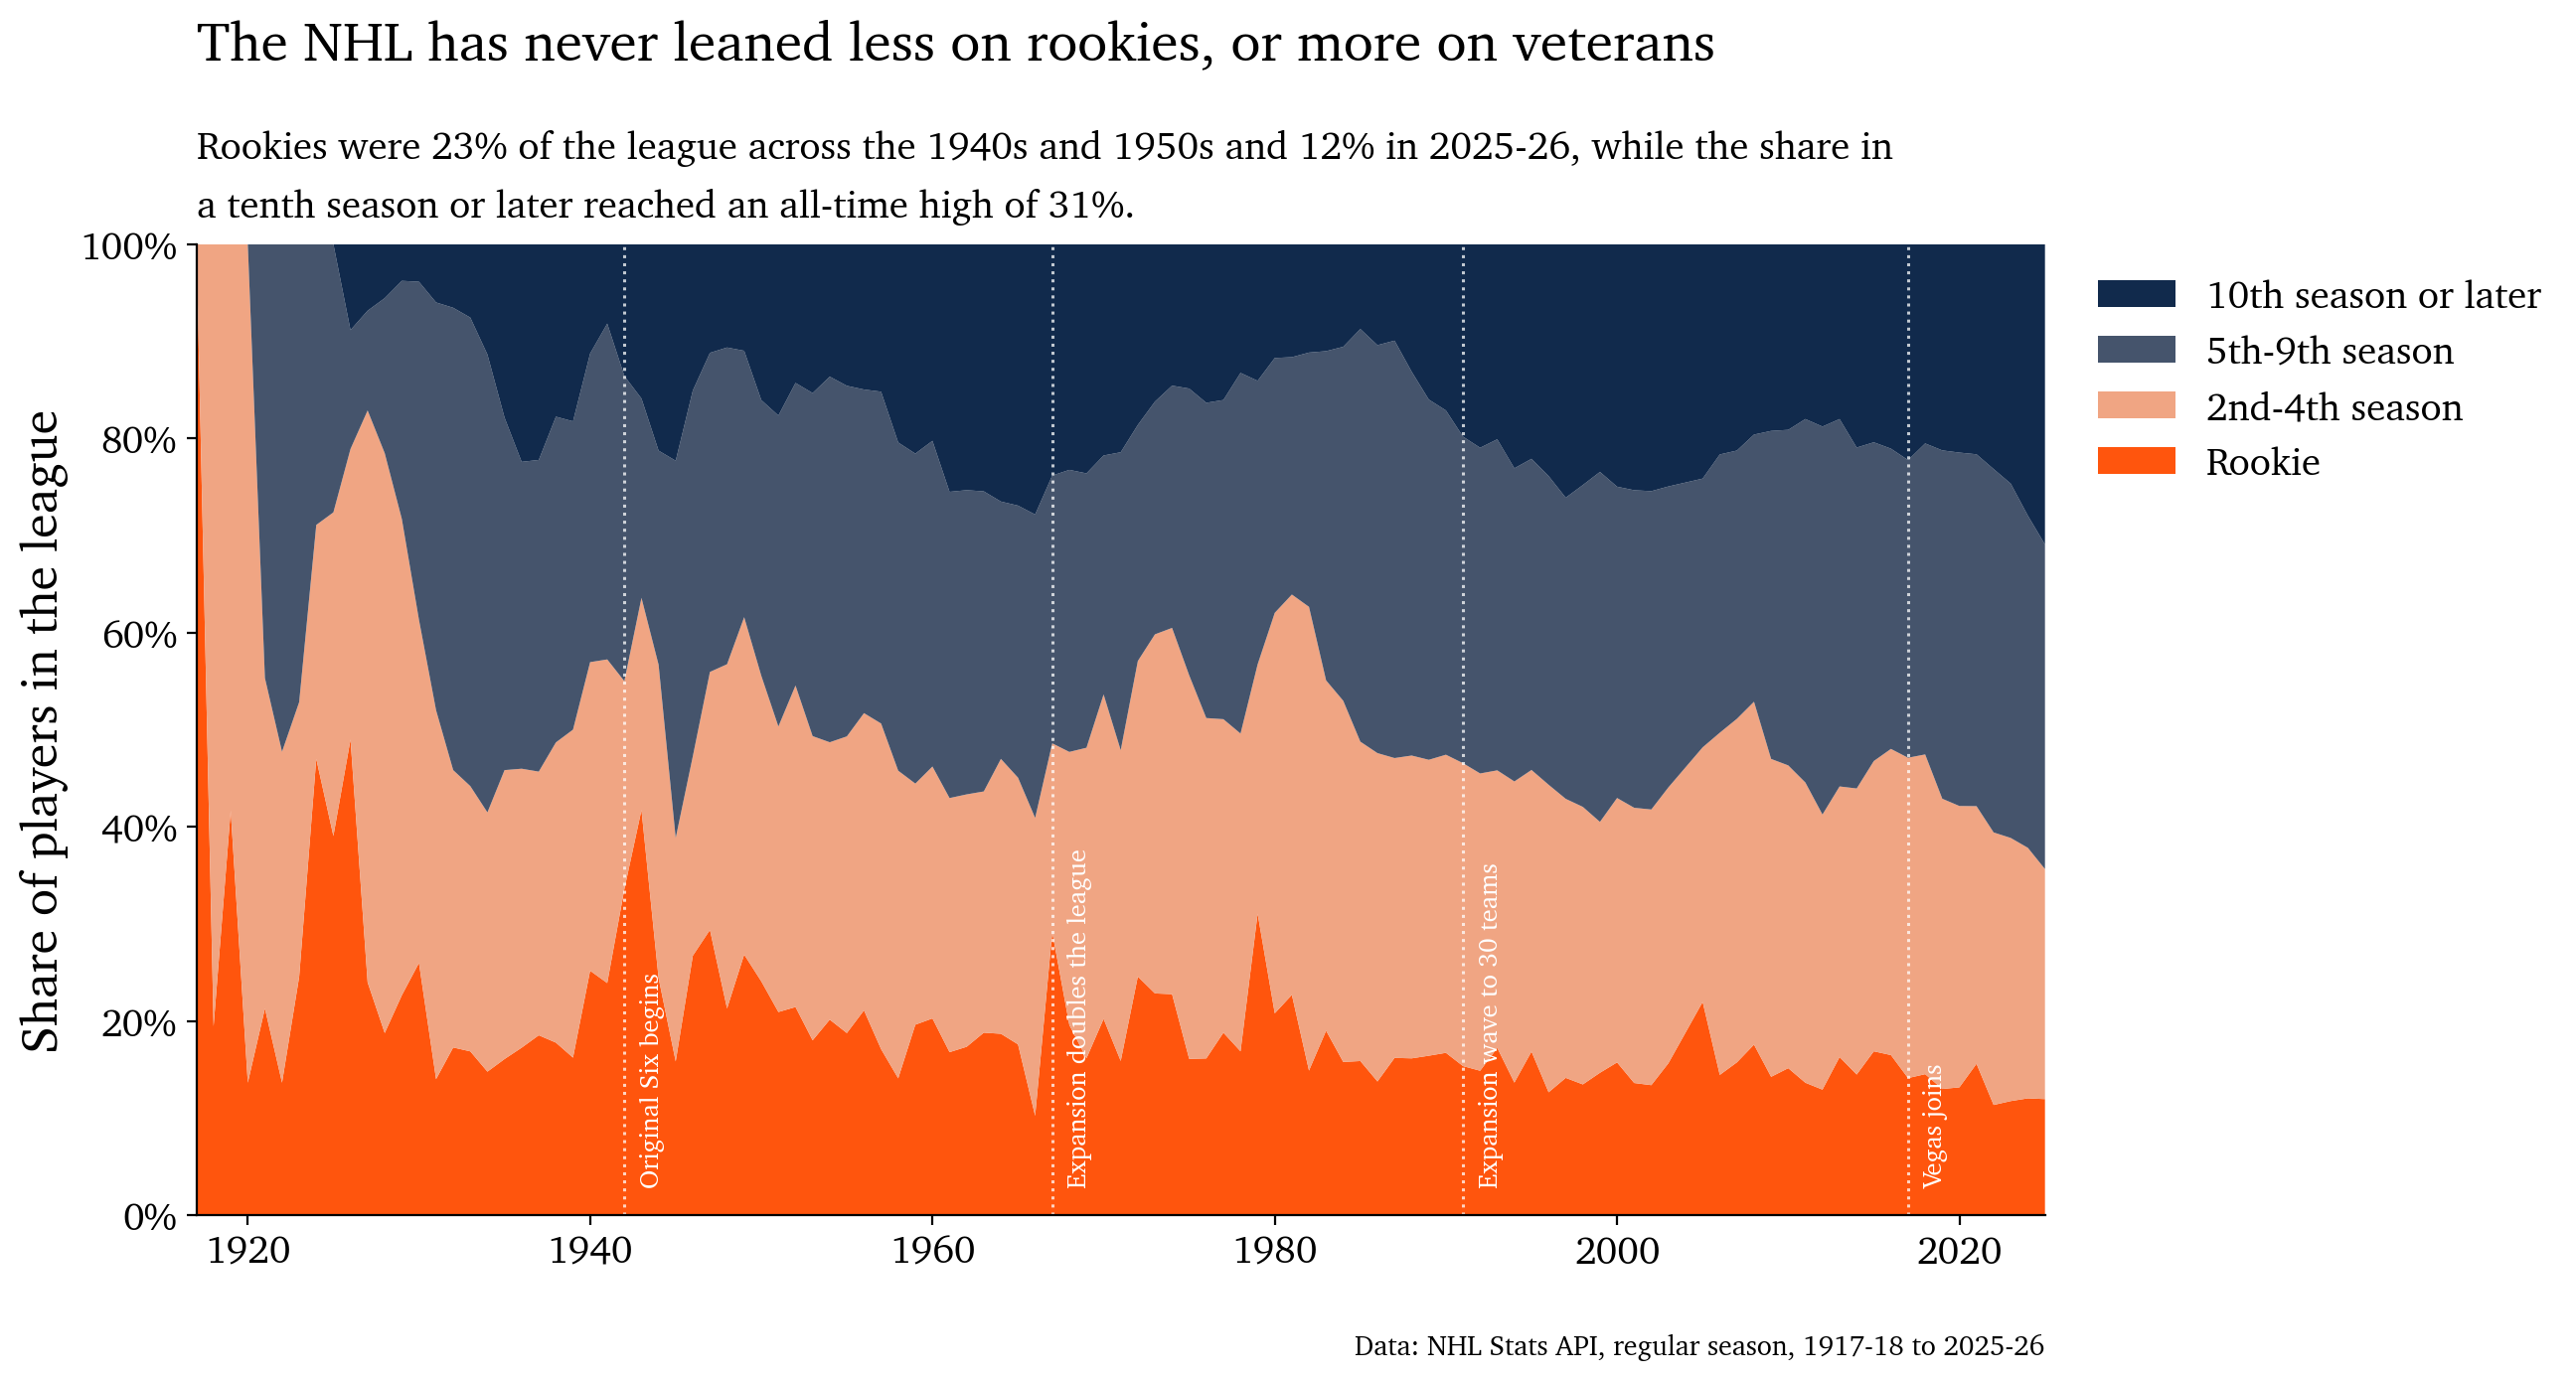

In [5]:
mix = (ps2.assign(bucket=pd.cut(ps2.ten, [0, 1, 4, 9, 99],
                                labels=["Rookie", "2nd-4th season", "5th-9th season",
                                        "10th season or later"]))
          .groupby(["year", "bucket"], observed=True).playerId.nunique()
          .unstack(fill_value=0))
mix = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(mix.index, [mix[c] for c in mix.columns], labels=list(mix.columns),
             colors=[ORANGE, "#F0A07C", BLUE_PALE, BLUE_DARK], alpha=.95)
ax.set_xlim(mix.index.min(), mix.index.max())
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y*100)}%"))
ax.set_ylabel("Share of players in the league", fontsize=FS_AXIS_LABEL)
for yr, lbl in ERA_MARKS:
    ax.axvline(yr, color="white", lw=1.1, ls=":", alpha=.75)
    ax.text(yr + 0.9, .035, lbl, fontsize=9.5, color="white", rotation=90)
h, l = ax.get_legend_handles_labels()
hd_legend(ax, h[::-1], l[::-1], loc="upper left", bbox_to_anchor=(1.01, 1))
finish(fig, ax, "The NHL has never leaned less on rookies, or more on veterans",
       f"Rookies were 23% of the league across the 1940s and 1950s and {mix.loc[LAST, 'Rookie']*100:.0f}% in 2025-26, while the share in a tenth season or later reached an all-time high of {mix.loc[LAST, '10th season or later']*100:.0f}%.",
       "Data: NHL Stats API, regular season, 1917-18 to 2025-26")

Pulling out the two ends of that distribution and putting them on a readable scale:

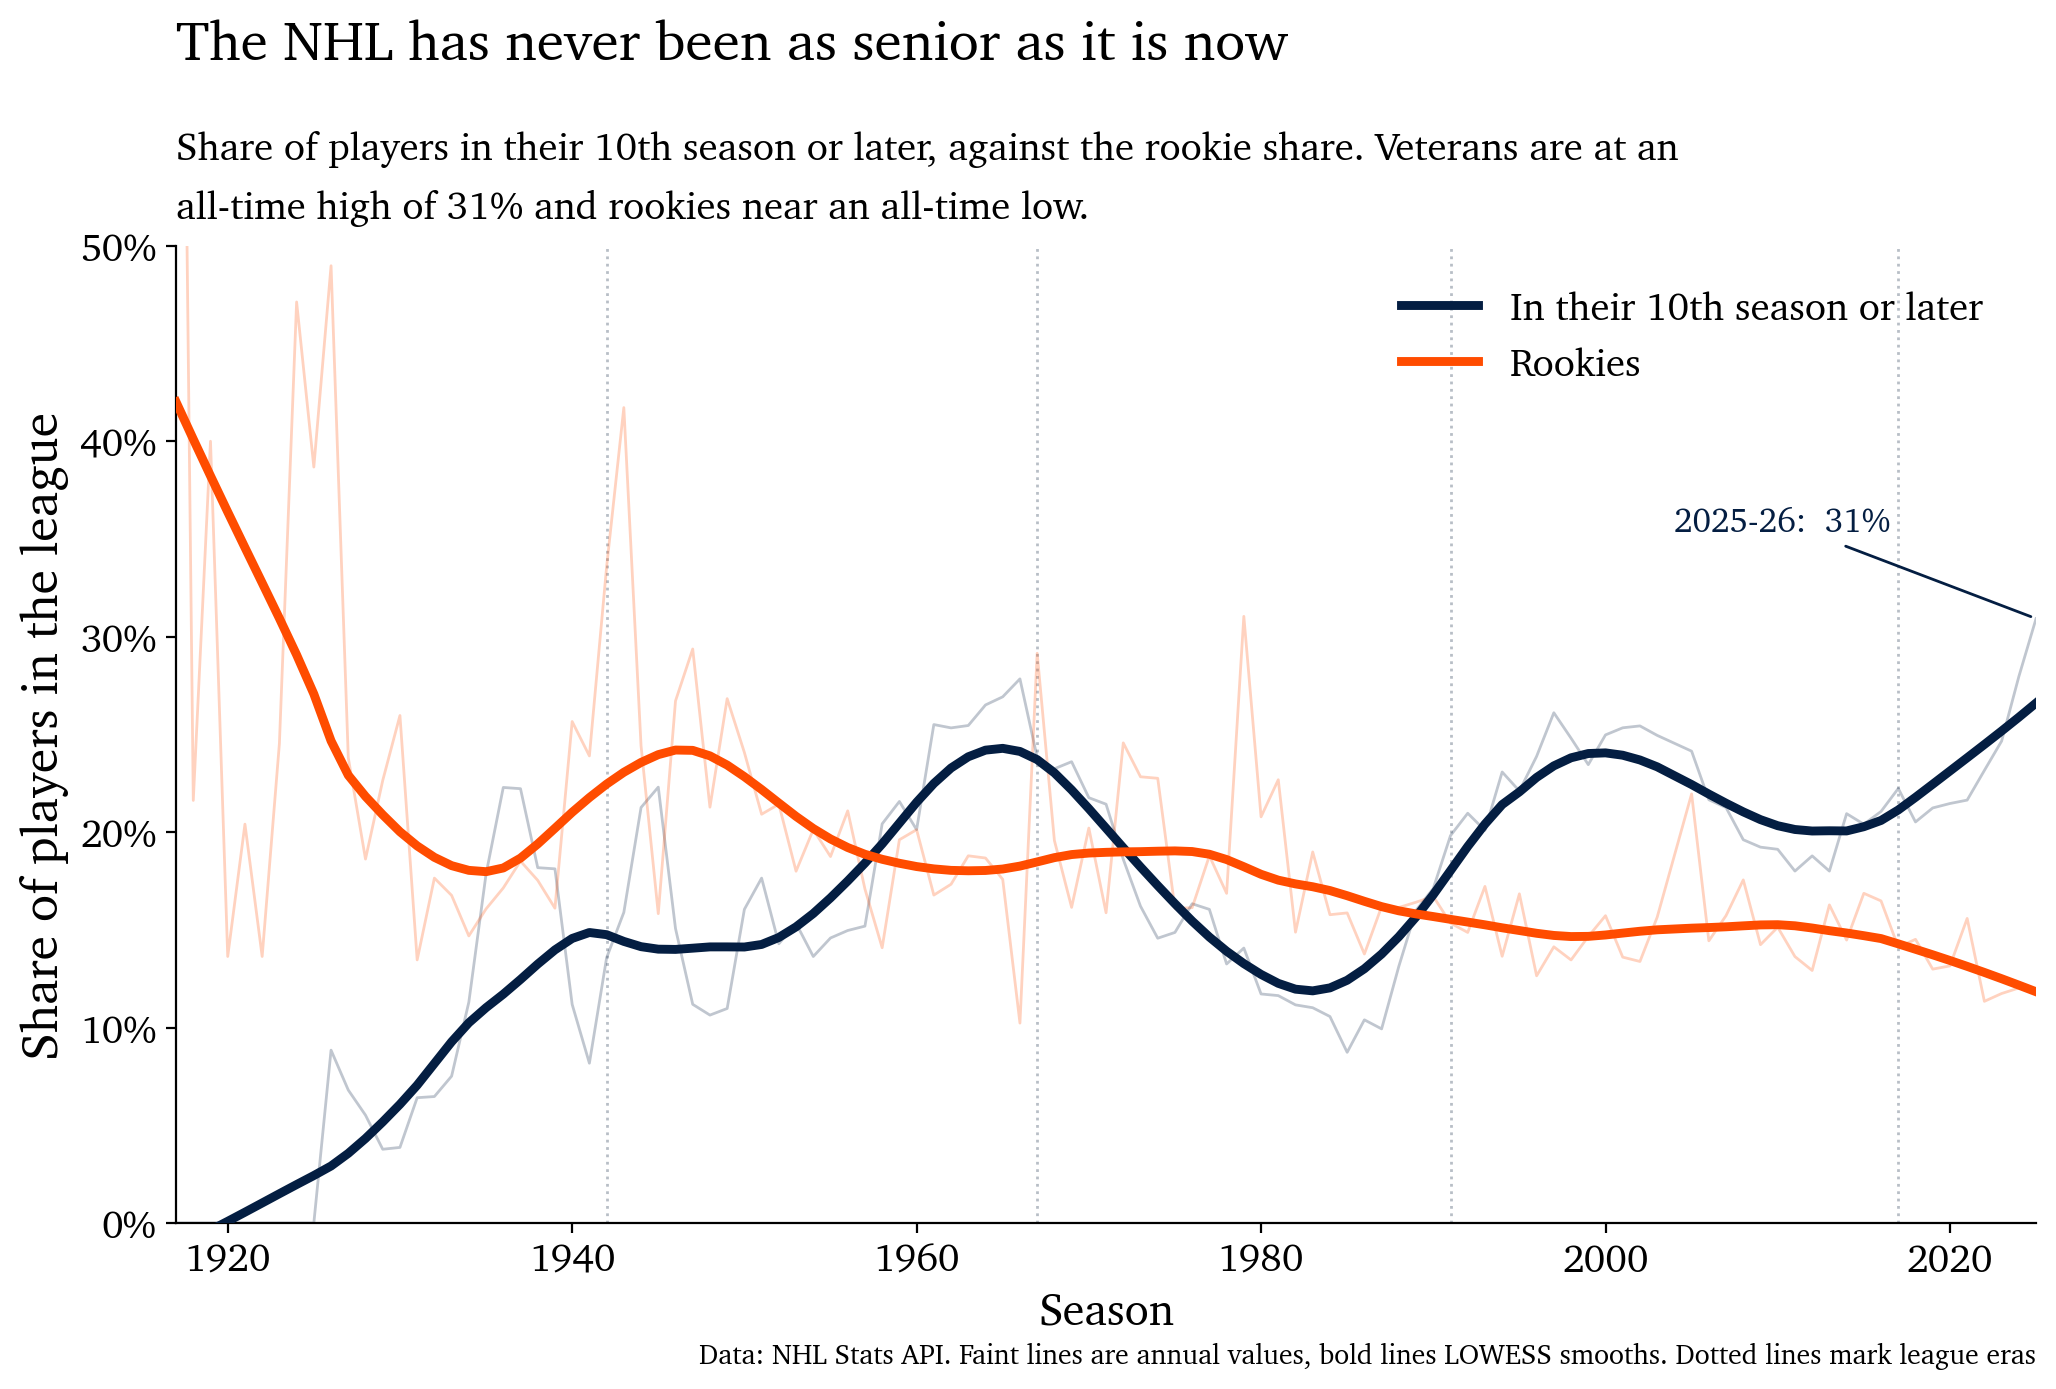

In [6]:
mixyr = ps2.groupby("year").apply(
    lambda g: pd.Series({"vet10": g.ten.ge(10).mean(), "rookie": g.ten.eq(1).mean()}),
    include_groups=False)

fig, ax = plt.subplots(figsize=(12, 7))
for col, colour, lbl in [("vet10", BLUE_DARK, "In their 10th season or later"),
                         ("rookie", ORANGE, "Rookies")]:
    ax.plot(mixyr.index, mixyr[col], color=colour, lw=1, alpha=.25, zorder=2)
    sm_ = lowess(mixyr[col].values, mixyr.index.values, frac=.18, return_sorted=True)
    ax.plot(sm_[:, 0], sm_[:, 1], color=colour, lw=3.2, label=lbl, zorder=3)
for yr, lbl in ERAS:
    ax.axvline(yr, color=GRAY, lw=1, ls=":", alpha=.7, zorder=1)
peak_yr = mixyr.vet10.idxmax()
ax.annotate(f"{peak_yr}-{str(peak_yr + 1)[-2:]}:  {mixyr.vet10.max()*100:.0f}%",
            (peak_yr, mixyr.vet10.max()), (peak_yr - 21, mixyr.vet10.max() + .045),
            fontsize=12, color=BLUE_DARK, ha="left",
            arrowprops=dict(arrowstyle="-", lw=1, color=BLUE_DARK))
ax.set_xlim(mixyr.index.min(), mixyr.index.max())
ax.set_ylim(0, .5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v*100)}%"))
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share of players in the league", fontsize=FS_AXIS_LABEL)
hd_legend(ax, loc="upper right", bbox_to_anchor=(0.99, 0.99))
finish(fig, ax, "The NHL has never been as senior as it is now",
       f"Share of players in their 10th season or later, against the rookie share. Veterans are at an all-time high of {mixyr.vet10.max()*100:.0f}% and rookies near an all-time low.",
       "Data: NHL Stats API. Faint lines are annual values, bold lines LOWESS smooths. Dotted lines mark league eras")

The same thing by decade. The rookie share has drifted down since the 1970s, while the veteran share swings with expansion and is now at its peak.

In [7]:
dec_tab = (mixyr.assign(players=ps2.groupby("year").playerId.nunique(),
                        mean_ten=ps2.groupby("year").ten.mean())
                .loc[1920:]
                .groupby(lambda y: f"{y // 10 * 10}s")
                .agg(players=("players", "mean"), rookie=("rookie", "mean"),
                     vet10=("vet10", "mean"), mean_ten=("mean_ten", "mean")))
dec_tab.index.name = "decade"
dec_tab.columns = ["players per season", "rookie share", "10th season+ share", "mean season of career"]
table(dec_tab, {"players per season": "{:,.0f}", "rookie share": "{:.1%}",
                "10th season+ share": "{:.1%}", "mean season of career": "{:.2f}"})
print(f"rookie share 1940-1959: {mixyr.loc[1940:1959, 'rookie'].mean():.1%}   "
      f"{LAST}-{str(LAST+1)[-2:]}: {mixyr.loc[LAST, 'rookie']:.1%}   "
      f"rank of {LAST} among lowest rookie shares since 1930: "
      f"{int((mixyr.loc[1930:, 'rookie'] < mixyr.loc[LAST, 'rookie']).sum()) + 1}")

,players per season,rookie share,10th season+ share,mean season of career
decade,,,,
1920s,97,27.2%,2.5%,3.47
1930s,165,17.4%,13.4%,5.23
1940s,146,26.9%,14.0%,4.88
1950s,152,19.5%,16.4%,5.36
1960s,211,18.4%,24.8%,6.31
1970s,476,20.5%,16.7%,5.33
1980s,691,17.1%,11.4%,4.93
1990s,834,15.0%,22.1%,6.06
2000s,967,15.8%,23.0%,6.15


rookie share 1940-1959: 23.2%   2025-26: 11.9%   rank of 2025 among lowest rookie shares since 1930: 4


## Where do you draw the veteran line?

"Veteran" is a judgment call, so here's the same comparison with the line drawn at different places. On an 8th-, 9th- or 10th-season cutoff, 2025-26 is the most veteran season the NHL has ever had. On an 11th-season cutoff it's second, a hair behind 1966-67, the final season of the six-team league (25.0% against 24.5%). Push the line out further and the late Original Six seasons pull ahead.

Weighting by games played, so a two-game call-up counts for less than an 82-game regular, puts this season back on top. Whichever way you slice it, the only real rival to the current league is the last season before expansion.

In [8]:
rows = []
for k in [8, 9, 10, 11, 12, 15]:
    v = ps2.groupby("year").ten.apply(lambda t: (t >= k).mean())
    top = v.sort_values(ascending=False)
    rows.append({"veteran = season": f"{k}th or later", f"{LAST}-{str(LAST+1)[-2:]} share": v.loc[LAST],
                 "rank (of 108)": int((v > v.loc[LAST]).sum()) + 1,
                 "highest season": f"{top.index[0]}-{str(top.index[0]+1)[-2:]} ({top.iloc[0]:.1%})",
                 "runner-up": f"{top.index[1]}-{str(top.index[1]+1)[-2:]} ({top.iloc[1]:.1%})"})
# games-weighted: a veteran who plays 82 games counts more than a two-game call-up
w = ps2.assign(v10=ps2.ten.ge(10) * ps2.games_played)
gw = w.groupby("year").v10.sum() / w.groupby("year").games_played.sum()
top = gw.sort_values(ascending=False)
rows.append({"veteran = season": "10th or later, games-weighted", f"{LAST}-{str(LAST+1)[-2:]} share": gw.loc[LAST],
             "rank (of 108)": int((gw > gw.loc[LAST]).sum()) + 1,
             "highest season": f"{top.index[0]}-{str(top.index[0]+1)[-2:]} ({top.iloc[0]:.1%})",
             "runner-up": f"{top.index[1]}-{str(top.index[1]+1)[-2:]} ({top.iloc[1]:.1%})"})
table(pd.DataFrame(rows), {f"{LAST}-{str(LAST+1)[-2:]} share": "{:.1%}"}, index=False)

veteran = season,2025-26 share,rank (of 108),highest season,runner-up
8th or later,42.9%,1,2025-26 (42.9%),2024-25 (41.0%)
9th or later,35.9%,1,2025-26 (35.9%),2024-25 (35.4%)
10th or later,30.9%,1,2025-26 (30.9%),2024-25 (28.0%)
11th or later,24.5%,2,1966-67 (25.0%),2025-26 (24.5%)
12th or later,18.0%,5,1966-67 (22.2%),1965-66 (18.7%)
15th or later,7.5%,10,1966-67 (14.2%),1969-70 (10.9%)
"10th or later, games-weighted",38.3%,1,2025-26 (38.3%),1965-66 (37.1%)


## Average experience, weighted by games

Another angle, from the team tables: the average experience of the players who actually dressed, weighted by games. The current league comes in second only to 1966-67. You can see every expansion knock it down. The 1966 peak of 7.3 seasons fell all the way to 4.0 by 1981, and it's taken four decades to climb back.

1945: 5.73  1966: 7.34  1967: 6.36  1979: 4.24  1990: 5.30  2000: 6.26  2010: 6.02  2025: 7.05
rank of 2025: 2 of 107; top 3: 1966 (7.34), 2025 (7.05), 1965 (6.94)


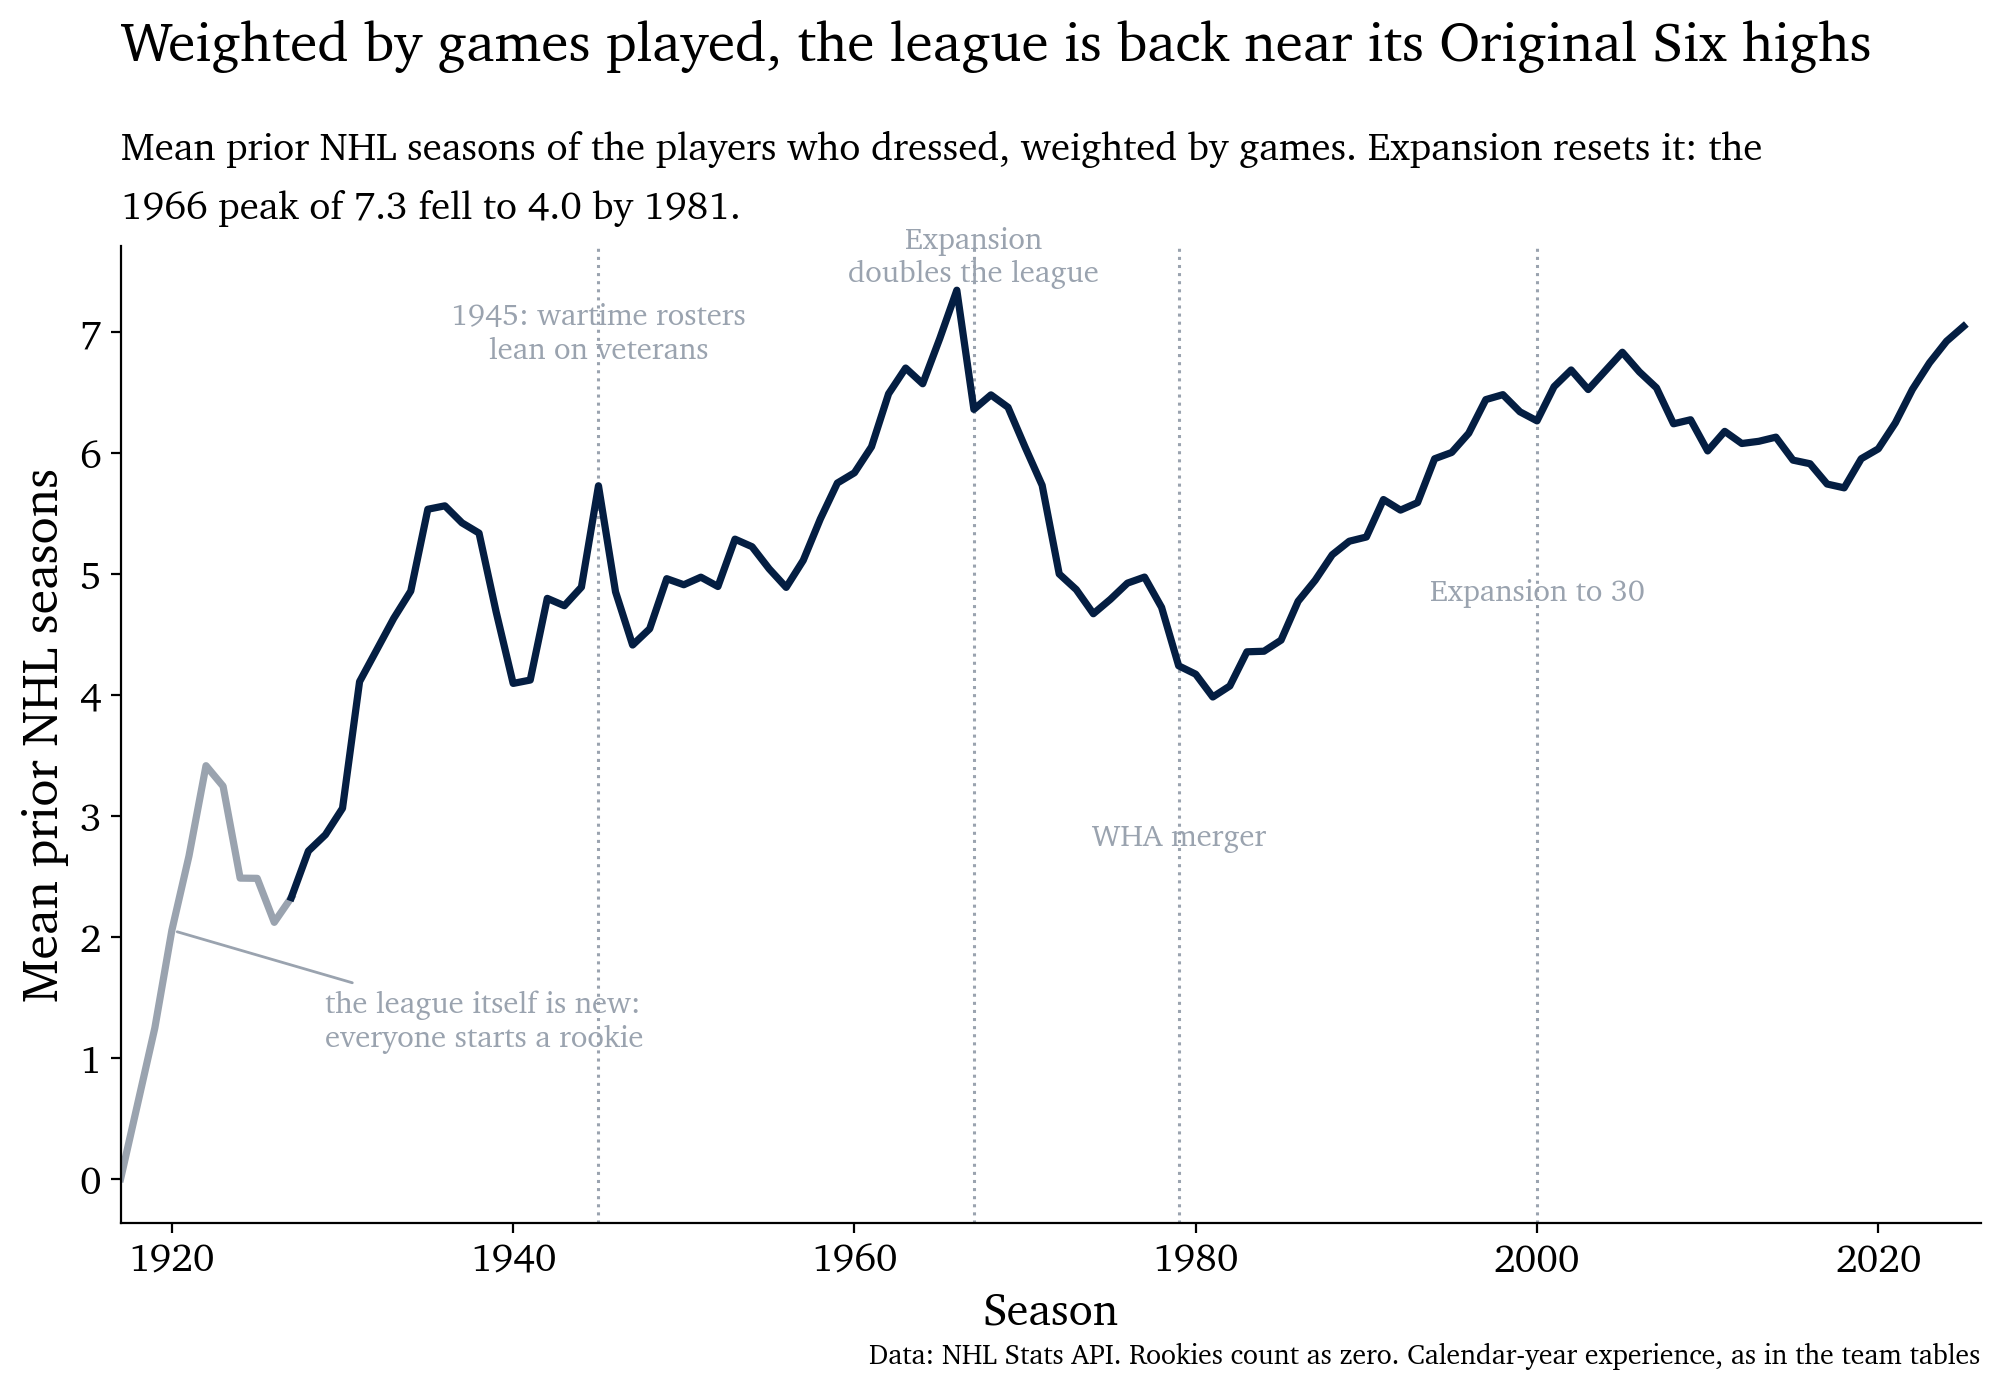

In [9]:
by_season = tse.groupby("yr").apply(lambda g: np.average(g.exp, weights=g.player_games),
                                    include_groups=False)
post_peak = by_season.loc[by_season.idxmax():]
trough_yr, trough = post_peak.idxmin(), post_peak.min()
FILL = 1927
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(by_season.loc[:FILL].index, by_season.loc[:FILL].values, color=GRAY, lw=2.6, zorder=2)
ax.plot(by_season.loc[FILL:].index, by_season.loc[FILL:].values, color=BLUE_DARK, lw=2.6, zorder=3)
ax.annotate("the league itself is new:\neveryone starts a rookie", (1920, by_season.loc[1920]),
            (1929, 1.3), fontsize=11, color=GRAY, ha="left", va="center",
            arrowprops=dict(arrowstyle="-", lw=1, color=GRAY))
for x, lbl, dy in [(1945, "1945: wartime rosters\nlean on veterans", 1.0),
                   (1967, "Expansion\ndoubles the league", 1.0),
                   (1979, "WHA merger", -1.3), (2000, "Expansion to 30", -1.3)]:
    ax.axvline(x, color=GRAY, ls=":", lw=1.1, zorder=1)
    ax.annotate(lbl, (x, by_season.loc[x] + dy), fontsize=11, color=GRAY, ha="center",
                va="bottom" if dy > 0 else "top")
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Mean prior NHL seasons", fontsize=FS_AXIS_LABEL)
ax.set_xlim(1917, 2026)
print("  ".join(f"{y}: {by_season.loc[y]:.2f}" for y in [1945, 1966, 1967, 1979, 1990, 2000, 2010, LAST]))
print(f"rank of {LAST}: {int((by_season > by_season.loc[LAST]).sum()) + 1} of {len(by_season)}; "
      f"top 3: {', '.join(f'{y} ({v:.2f})' for y, v in by_season.nlargest(3).items())}")
finish(fig, ax, "Weighted by games played, the league is back near its Original Six highs",
       f"Mean prior NHL seasons of the players who dressed, weighted by games. Expansion resets it: the {by_season.idxmax()} peak of {by_season.max():.1f} fell to {trough:.1f} by {trough_yr}.",
       "Data: NHL Stats API. Rookies count as zero. Calendar-year experience, as in the team tables")

## By position

Forwards, defencemen and goalies have all moved together, so this isn't one position driving the change.

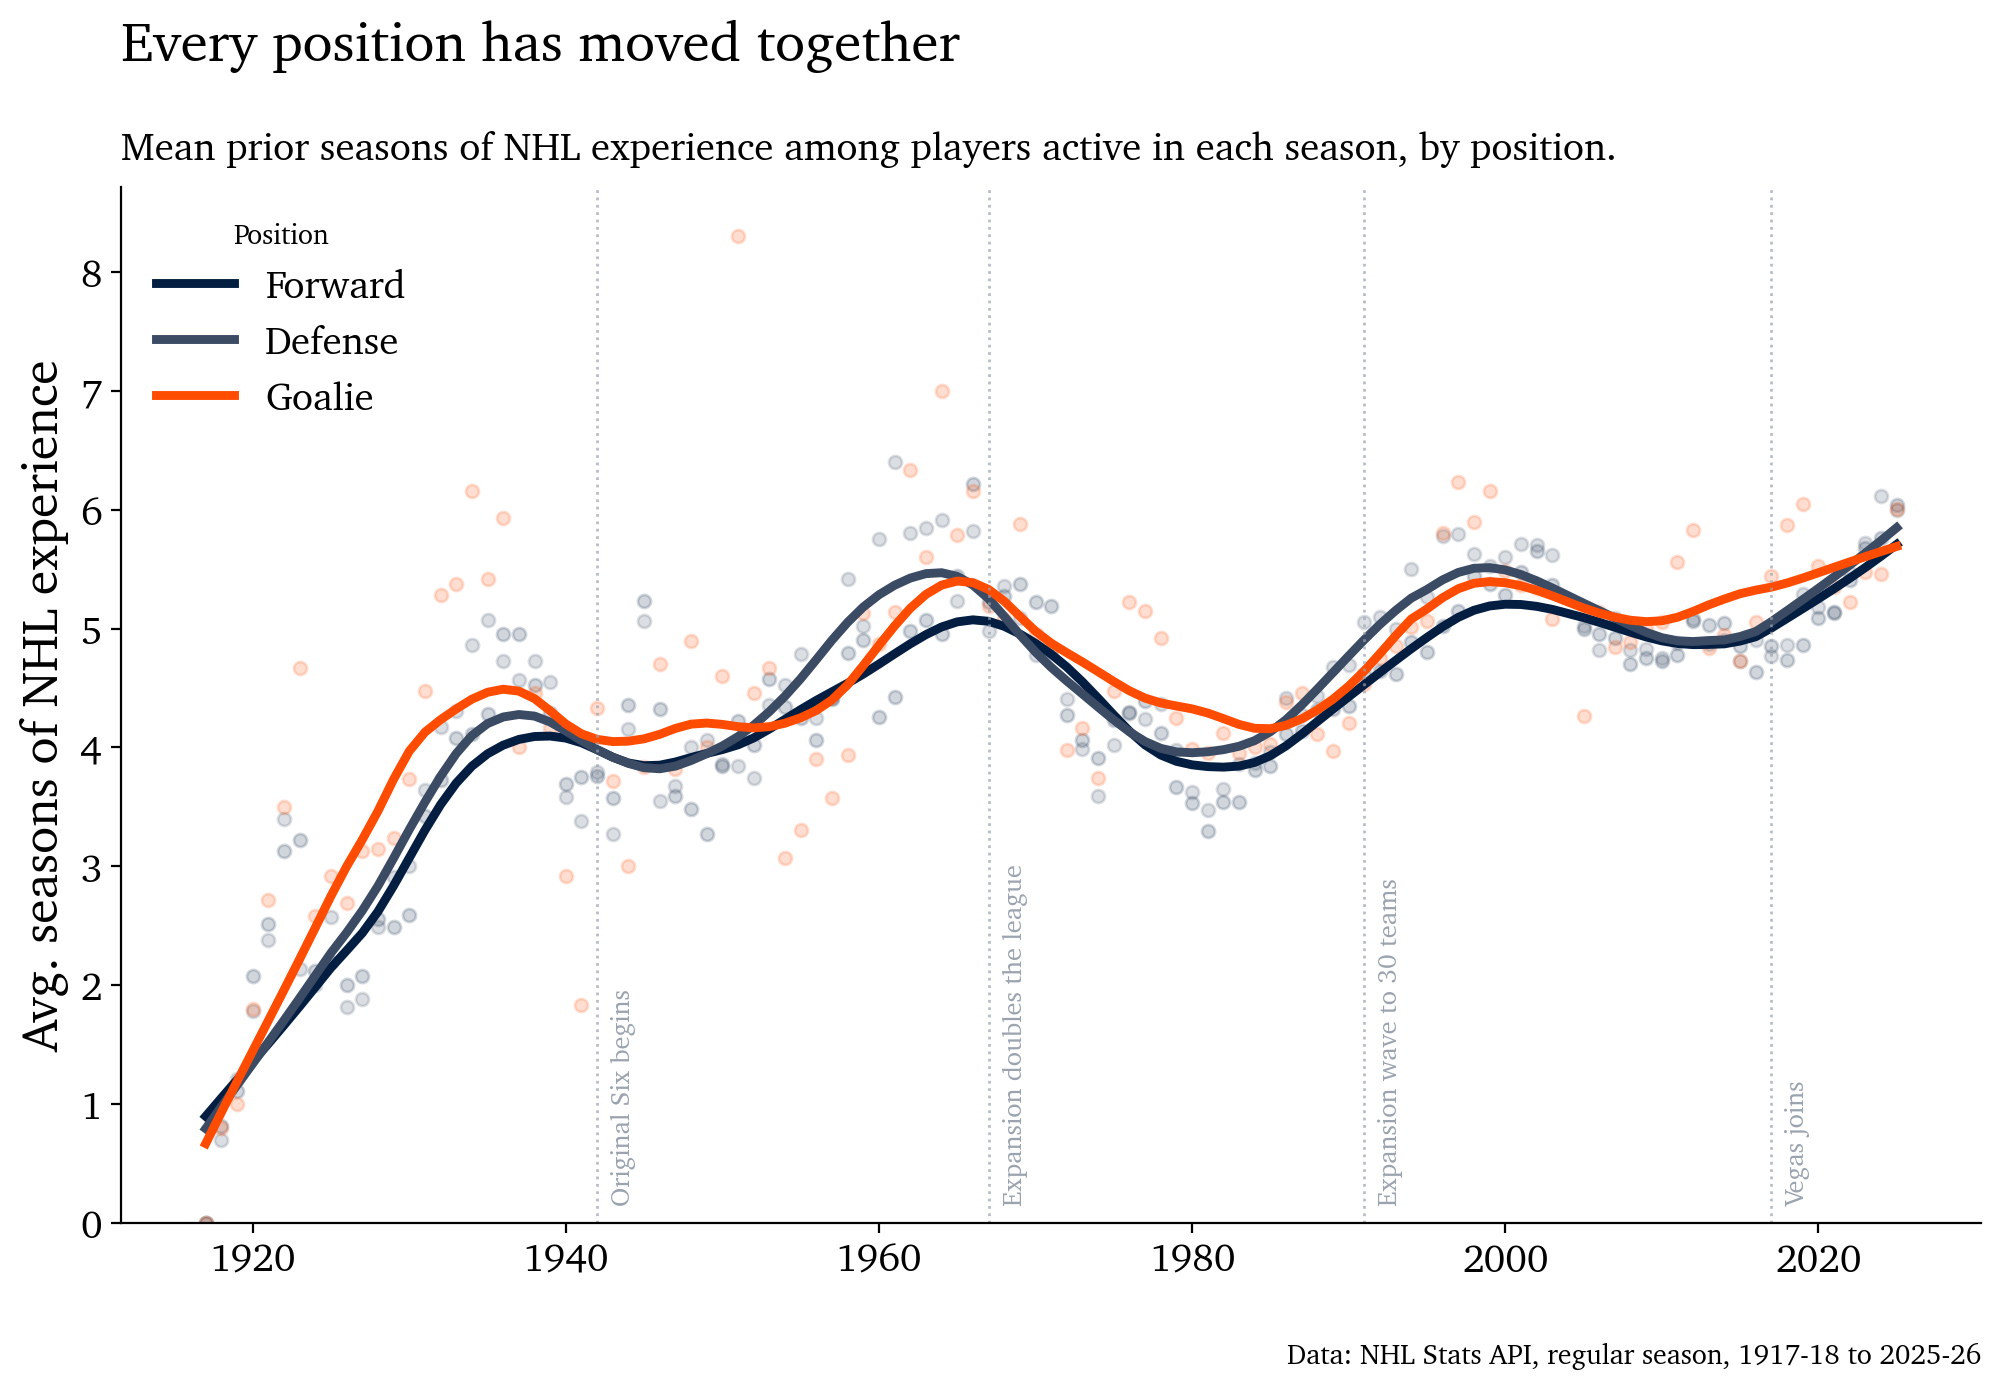

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
for g in ["Forward", "Defense", "Goalie"]:
    d_ = ps2[ps2.pos_group == g].groupby("year").exp.mean()
    ax.scatter(d_.index, d_.values, color=POS_COLORS[g], alpha=.18, s=22)
    sm_ = lowess(d_.values, d_.index, frac=.18, return_sorted=True)
    ax.plot(sm_[:, 0], sm_[:, 1], color=POS_COLORS[g], lw=3.2, label=g)
ax.set_ylabel("Avg. seasons of NHL experience", fontsize=FS_AXIS_LABEL)
ax.set_ylim(0, ax.get_ylim()[1])
for yr, lbl in ERA_MARKS:
    ax.axvline(yr, color=GRAY, lw=1, ls=":", alpha=.7)
    ax.text(yr + 0.9, 0.15, lbl, fontsize=9.5, color=GRAY, rotation=90, va="bottom")
hd_legend(ax, title="Position")
finish(fig, ax, "Every position has moved together",
       "Mean prior seasons of NHL experience among players active in each season, by position.",
       "Data: NHL Stats API, regular season, 1917-18 to 2025-26")

# But careers aren't getting longer

## Median career length by debut season

The natural explanation for an older league is that careers got longer. This is the figure from the post that says they didn't: the Kaplan-Meier median career by debut season, with a 95% band.

The dashed line is worth a look. It's what you get if you drop active players instead of censoring them: the "average career" falls off a cliff from about 2005 on. That cliff isn't real. Those cohorts just haven't finished yet.

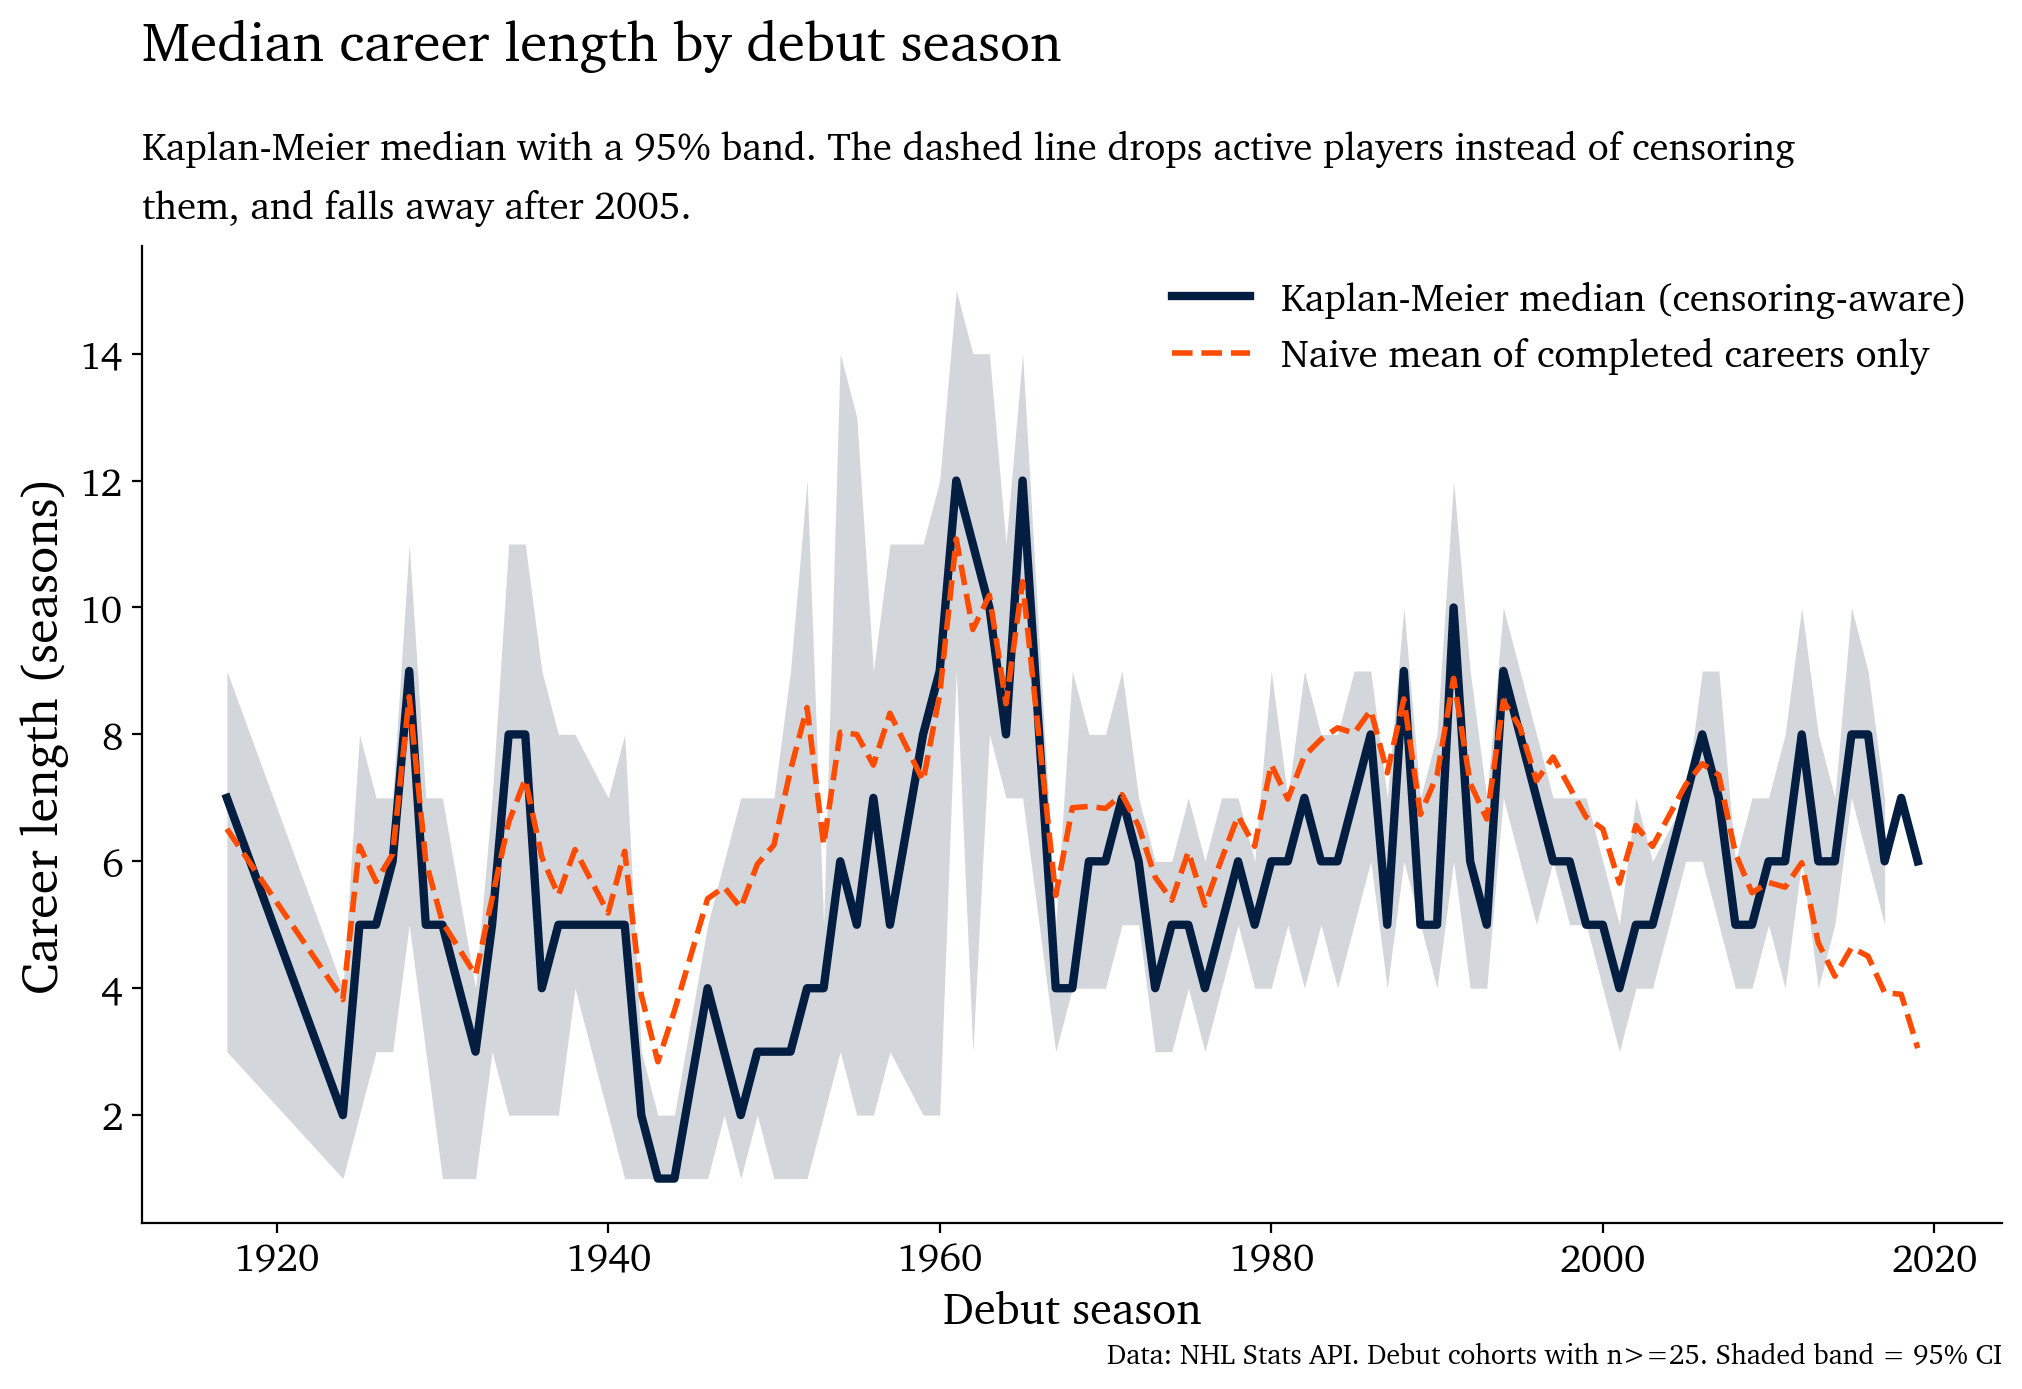

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(coh.year, coh.lo, coh.hi, color=BLUE_PALE, alpha=.22, lw=0)
ax.plot(coh.year, coh.km_median, color=BLUE_DARK, lw=3, label="Kaplan-Meier median (censoring-aware)")
ax.plot(coh.year, coh.naive_completed, color=ORANGE, lw=2, ls="--",
        label="Naive mean of completed careers only")
ax.set_ylabel("Career length (seasons)", fontsize=FS_AXIS_LABEL)
ax.set_xlabel("Debut season", fontsize=FS_XAXIS_LABEL)
hd_legend(ax, loc="upper right")
finish(fig, ax, "Median career length by debut season",
       "Kaplan-Meier median with a 95% band. The dashed line drops active players instead of censoring them, and falls away after 2005.",
       "Data: NHL Stats API. Debut cohorts with n>=25. Shaded band = 95% CI")

## The full distribution, by decade

Here's more granularity than the post had room for: the quartiles, the 90th percentile, the mean (area under the survival curve), and the share of each debut cohort that makes it to a 5th, 10th and 15th season. Anything a cohort hasn't finished yet is left blank rather than guessed.

Since 1950, the median by debut decade goes 5, 8, 5, 6, 7, 6. There's no direction to it, just a cycle. The 1960s produced the longest careers because a six-team league only let in players who were going to stick. The 1970s produced the shortest because expansion and the WHA filled rosters with players who didn't.

I also fit a trend line to the single-year medians over a few different windows. The only upward trends come from windows that start in the war years, when careers were briefly very short, or at the 1967 expansion. Start in 1950 or 1980 and it's flat.

In [12]:
def km(g):
    return SurvfuncRight(g.span.values, (~g.censored).astype(int).values)


def surv_at(sf, t):
    m = sf.surv_times <= t
    return sf.surv_prob[m][-1] if m.any() else 1.0


rows = []
with np.errstate(divide="ignore", invalid="ignore"):
    for dec, g in car.groupby(car.first_year // 10 * 10):
        if dec < 1920:
            continue
        sf = km(g)
        r = {"decade": f"{dec}s", "debuts": len(g), "still active": g.censored.mean()}
        for p in [.25, .5, .75, .9]:
            try:
                r[f"p{int(p*100)}"] = sf.quantile(p)
            except Exception:
                r[f"p{int(p*100)}"] = np.nan
        r["mean (RMST, 25 seasons)"] = sum(surv_at(sf, t) for t in range(25))
        r["reach 5th season"] = surv_at(sf, 4)
        r["reach 10th season"] = surv_at(sf, 9)
        r["reach 15th season"] = surv_at(sf, 14)
        rows.append(r)
KMD = pd.DataFrame(rows).set_index("decade")
# a quantile the curve has not yet crossed is not estimable, not zero
KMD.loc[KMD["still active"] > .25, ["p75", "p90", "mean (RMST, 25 seasons)"]] = np.nan
table(KMD, {"debuts": "{:,}", "still active": "{:.0%}", "p25": "{:.0f}", "p50": "{:.0f}",
            "p75": "{:.0f}", "p90": "{:.0f}", "mean (RMST, 25 seasons)": "{:.2f}",
            "reach 5th season": "{:.0%}", "reach 10th season": "{:.0%}",
            "reach 15th season": "{:.0%}"})

tr_rows = []
done_dec = KMD.loc[[f"{d}s" for d in range(1930, 2010, 10)]]
x = np.arange(1930, 2010, 10).astype(float)
for c in ["p50", "mean (RMST, 25 seasons)", "reach 10th season"]:
    m = sm.OLS(done_dec[c].values.astype(float), sm.add_constant(x)).fit()
    tr_rows.append({"measure": c, "trend per decade": m.params[1] * 10, "p-value": m.pvalues[1]})
table(pd.DataFrame(tr_rows), {"trend per decade": "{:+.3f}", "p-value": "{:.3f}"}, index=False,
      caption="Linear trend across debut decades, 1930s-2000s")
rows = []
for lo, hi in [(1924, 2019), (1946, 2019), (1950, 2019), (1967, 2019), (1980, 2019), (1950, 2008)]:
    x_ = coh[coh.year.between(lo, hi)]
    m = sm.OLS(x_.km_median.values, sm.add_constant(x_.year.values.astype(float))).fit()
    rows.append({"debut years": f"{lo}-{hi}", "cohorts": len(x_), "trend per decade": m.params[1] * 10,
                 "p-value": m.pvalues[1]})
table(pd.DataFrame(rows), {"trend per decade": "{:+.2f}", "p-value": "{:.3f}"}, index=False,
      caption="Trend in the single-year Kaplan-Meier median (the series in fig 3), by window")

,debuts,still active,p25,p50,p75,p90,"mean (RMST, 25 seasons)",reach 5th season,reach 10th season,reach 15th season
decade,,,,,,,,,,
1920s,285,0%,2,5,9,13,6.02,52%,25%,5%
1930s,290,0%,1,4,9,12,5.68,49%,22%,3%
1940s,394,0%,1,2,8,12,4.81,38%,18%,5%
1950s,297,0%,1,5,13,18,7.52,52%,33%,19%
1960s,404,0%,3,8,12,15,7.86,63%,42%,13%
1970s,994,0%,2,5,9,13,6.16,56%,25%,5%
1980s,"1,183",0%,3,6,12,16,7.69,62%,35%,16%
1990s,"1,245",0%,3,7,12,15,7.53,62%,35%,13%
2000s,"1,376",3%,2,6,11,15,6.97,57%,30%,11%


measure,trend per decade,p-value
p50,+0.464,0.104
"mean (RMST, 25 seasons)",+0.254,0.147
reach 10th season,+0.016,0.224


debut years,cohorts,trend per decade,p-value
1924-2019,90,+0.22,0.006
1946-2019,71,+0.17,0.135
1950-2019,67,+0.03,0.790
1967-2019,52,+0.26,0.040
1980-2019,39,-0.02,0.928
1950-2008,56,-0.00,0.977


Every percentile, 10th through 90th, rides the same expansion cycle and none of them trend.

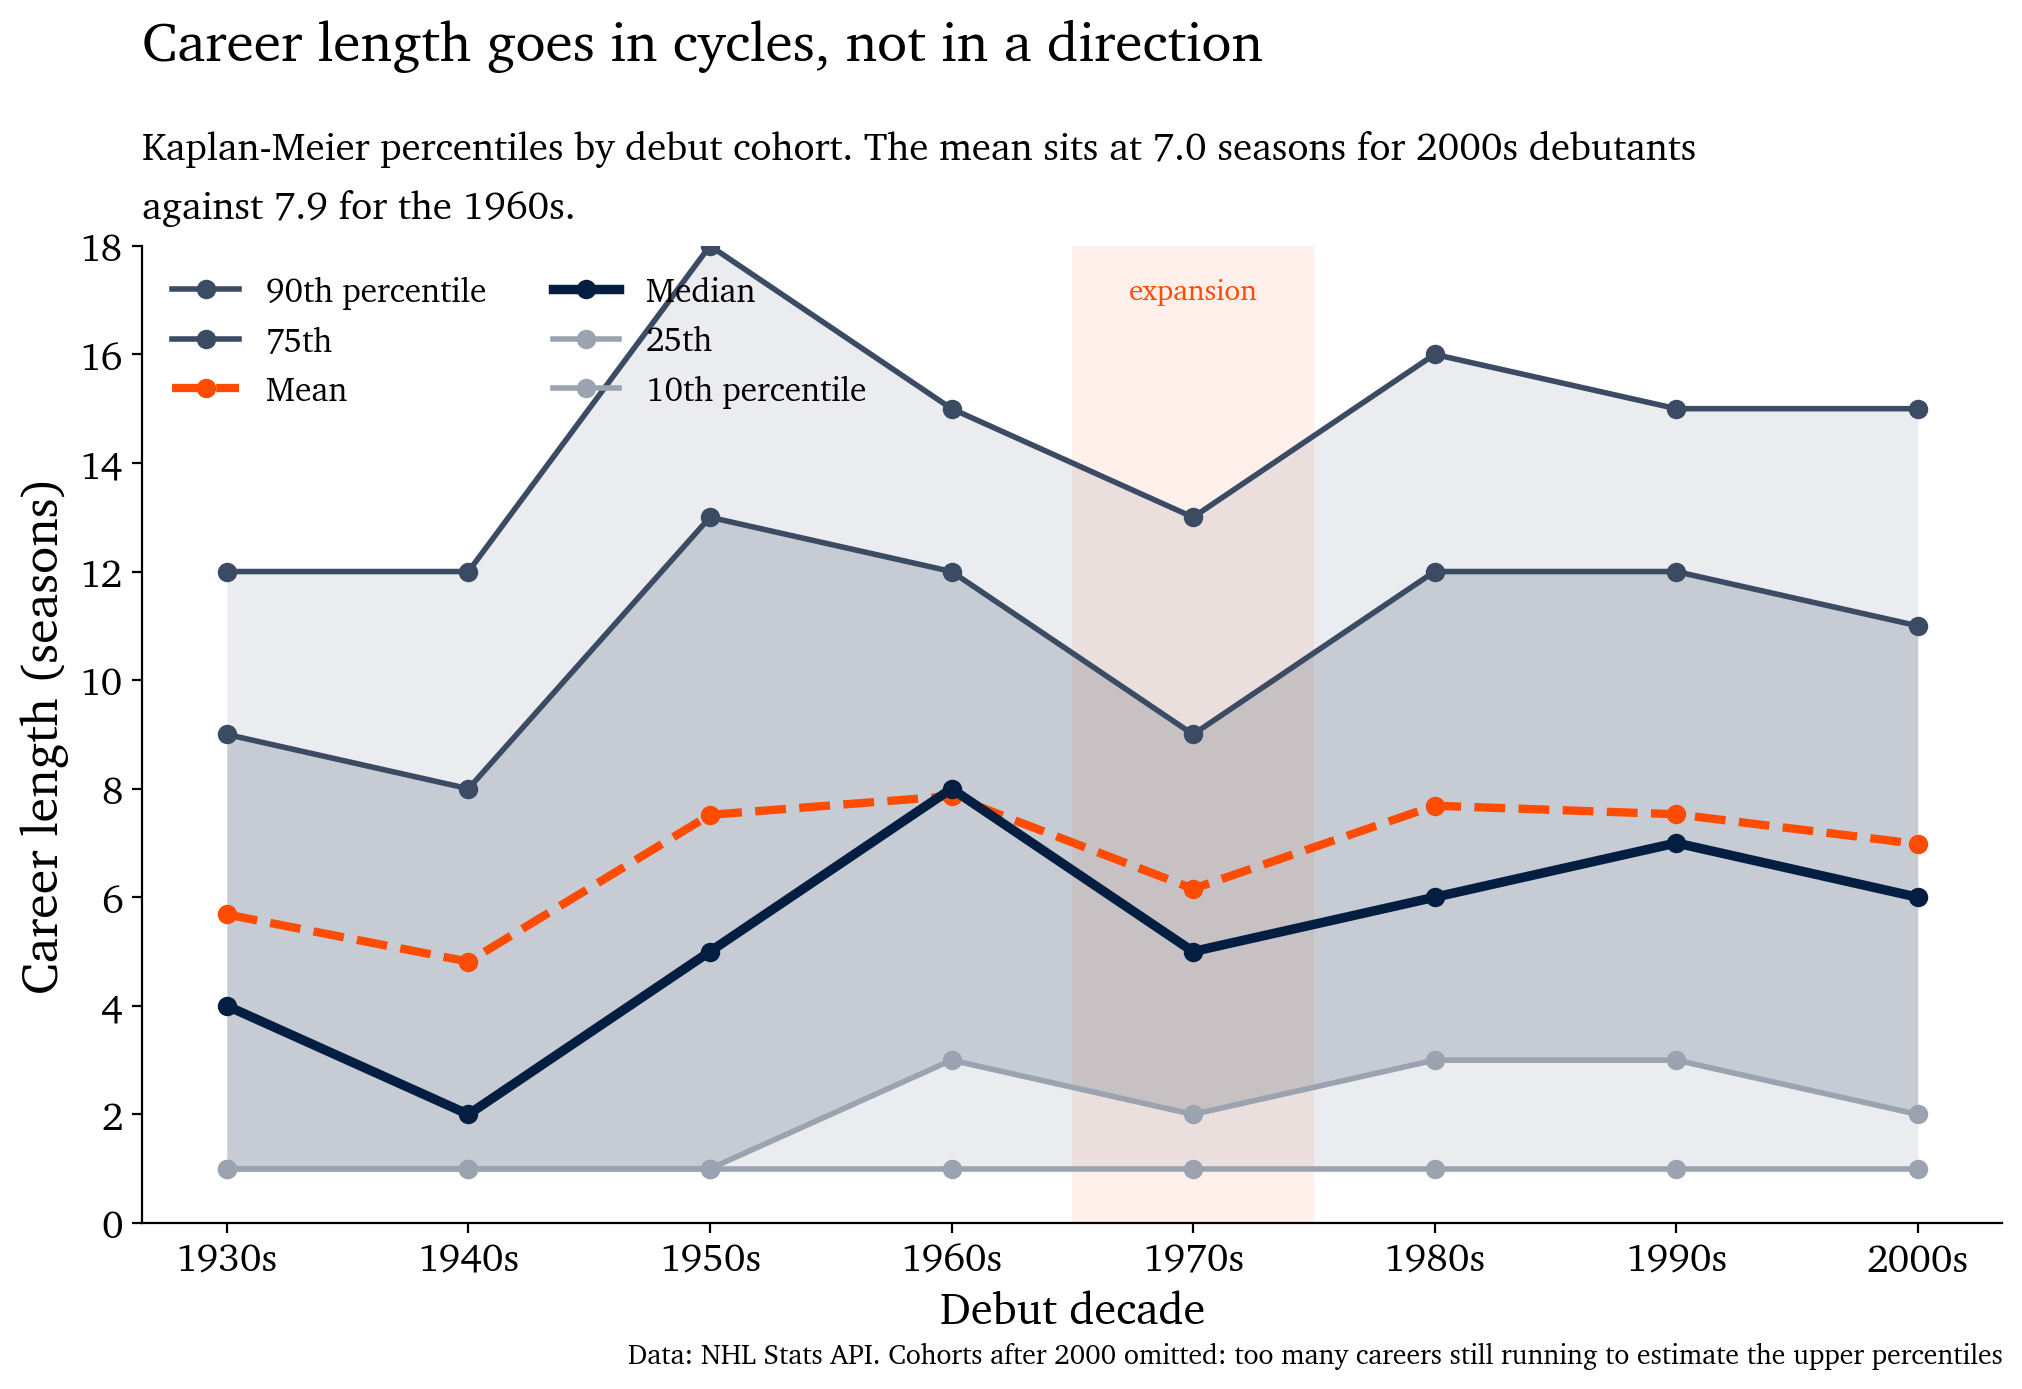

In [13]:
QC = []
with np.errstate(divide="ignore", invalid="ignore"):
    for dec, g in car.groupby(car.first_year // 10 * 10):
        if len(g) < 150 or dec < 1930 or dec > 2000:
            continue
        sf = km(g)
        r = {"decade": int(dec)}
        for p in [.10, .25, .50, .75, .90]:
            try:
                r[f"p{int(p*100)}"] = sf.quantile(p)
            except Exception:
                r[f"p{int(p*100)}"] = np.nan
        r["mean"] = np.sum([surv_at(sf, t) for t in range(26)])
        QC.append(r)
QC = pd.DataFrame(QC).set_index("decade")

fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(QC.index, QC.p10, QC.p90, color=BLUE_PALE, alpha=.10, lw=0, zorder=1)
ax.fill_between(QC.index, QC.p25, QC.p75, color=BLUE_PALE, alpha=.20, lw=0, zorder=1)
for col, colour, lbl, lw, ls in [("p90", BLUE_PALE, "90th percentile", 2.0, "-"),
                                 ("p75", BLUE_PALE, "75th", 2.0, "-"),
                                 ("mean", ORANGE, "Mean", 3.0, "--"),
                                 ("p50", BLUE_DARK, "Median", 3.4, "-"),
                                 ("p25", GRAY, "25th", 2.0, "-"),
                                 ("p10", GRAY, "10th percentile", 2.0, "-")]:
    ax.plot(QC.index, QC[col], color=colour, lw=lw, ls=ls, marker="o", ms=6, zorder=3, label=lbl)
ax.axvspan(1965, 1975, color=ORANGE, alpha=.08, lw=0, zorder=0)
ax.text(1970, 17.4, "expansion", fontsize=10.5, color=ORANGE, ha="center", va="top", style="italic")
ax.set_xlabel("Debut decade", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Career length (seasons)", fontsize=FS_AXIS_LABEL)
ax.set_xticks(QC.index)
ax.set_xticklabels([f"{d}s" for d in QC.index])
ax.set_ylim(0, 18)
hd_legend(ax, loc="upper left", ncol=2, fontsize=12)
finish(fig, ax, "Career length goes in cycles, not in a direction",
       f"Kaplan-Meier percentiles by debut cohort. The mean sits at {QC['mean'].loc[2000]:.1f} seasons for 2000s debutants against {QC['mean'].loc[1960]:.1f} for the 1960s.",
       "Data: NHL Stats API. Cohorts after 2000 omitted: too many careers still running to estimate the upper percentiles")

## Survival curves

Another way to look at the same thing: the share of each debut cohort still in the league after a given number of seasons. Recent cohorts get through their first few seasons more often than older ones did, but the curves come back together further out. (The 2015-19 cohort has only had six to ten seasons to show us anything.)

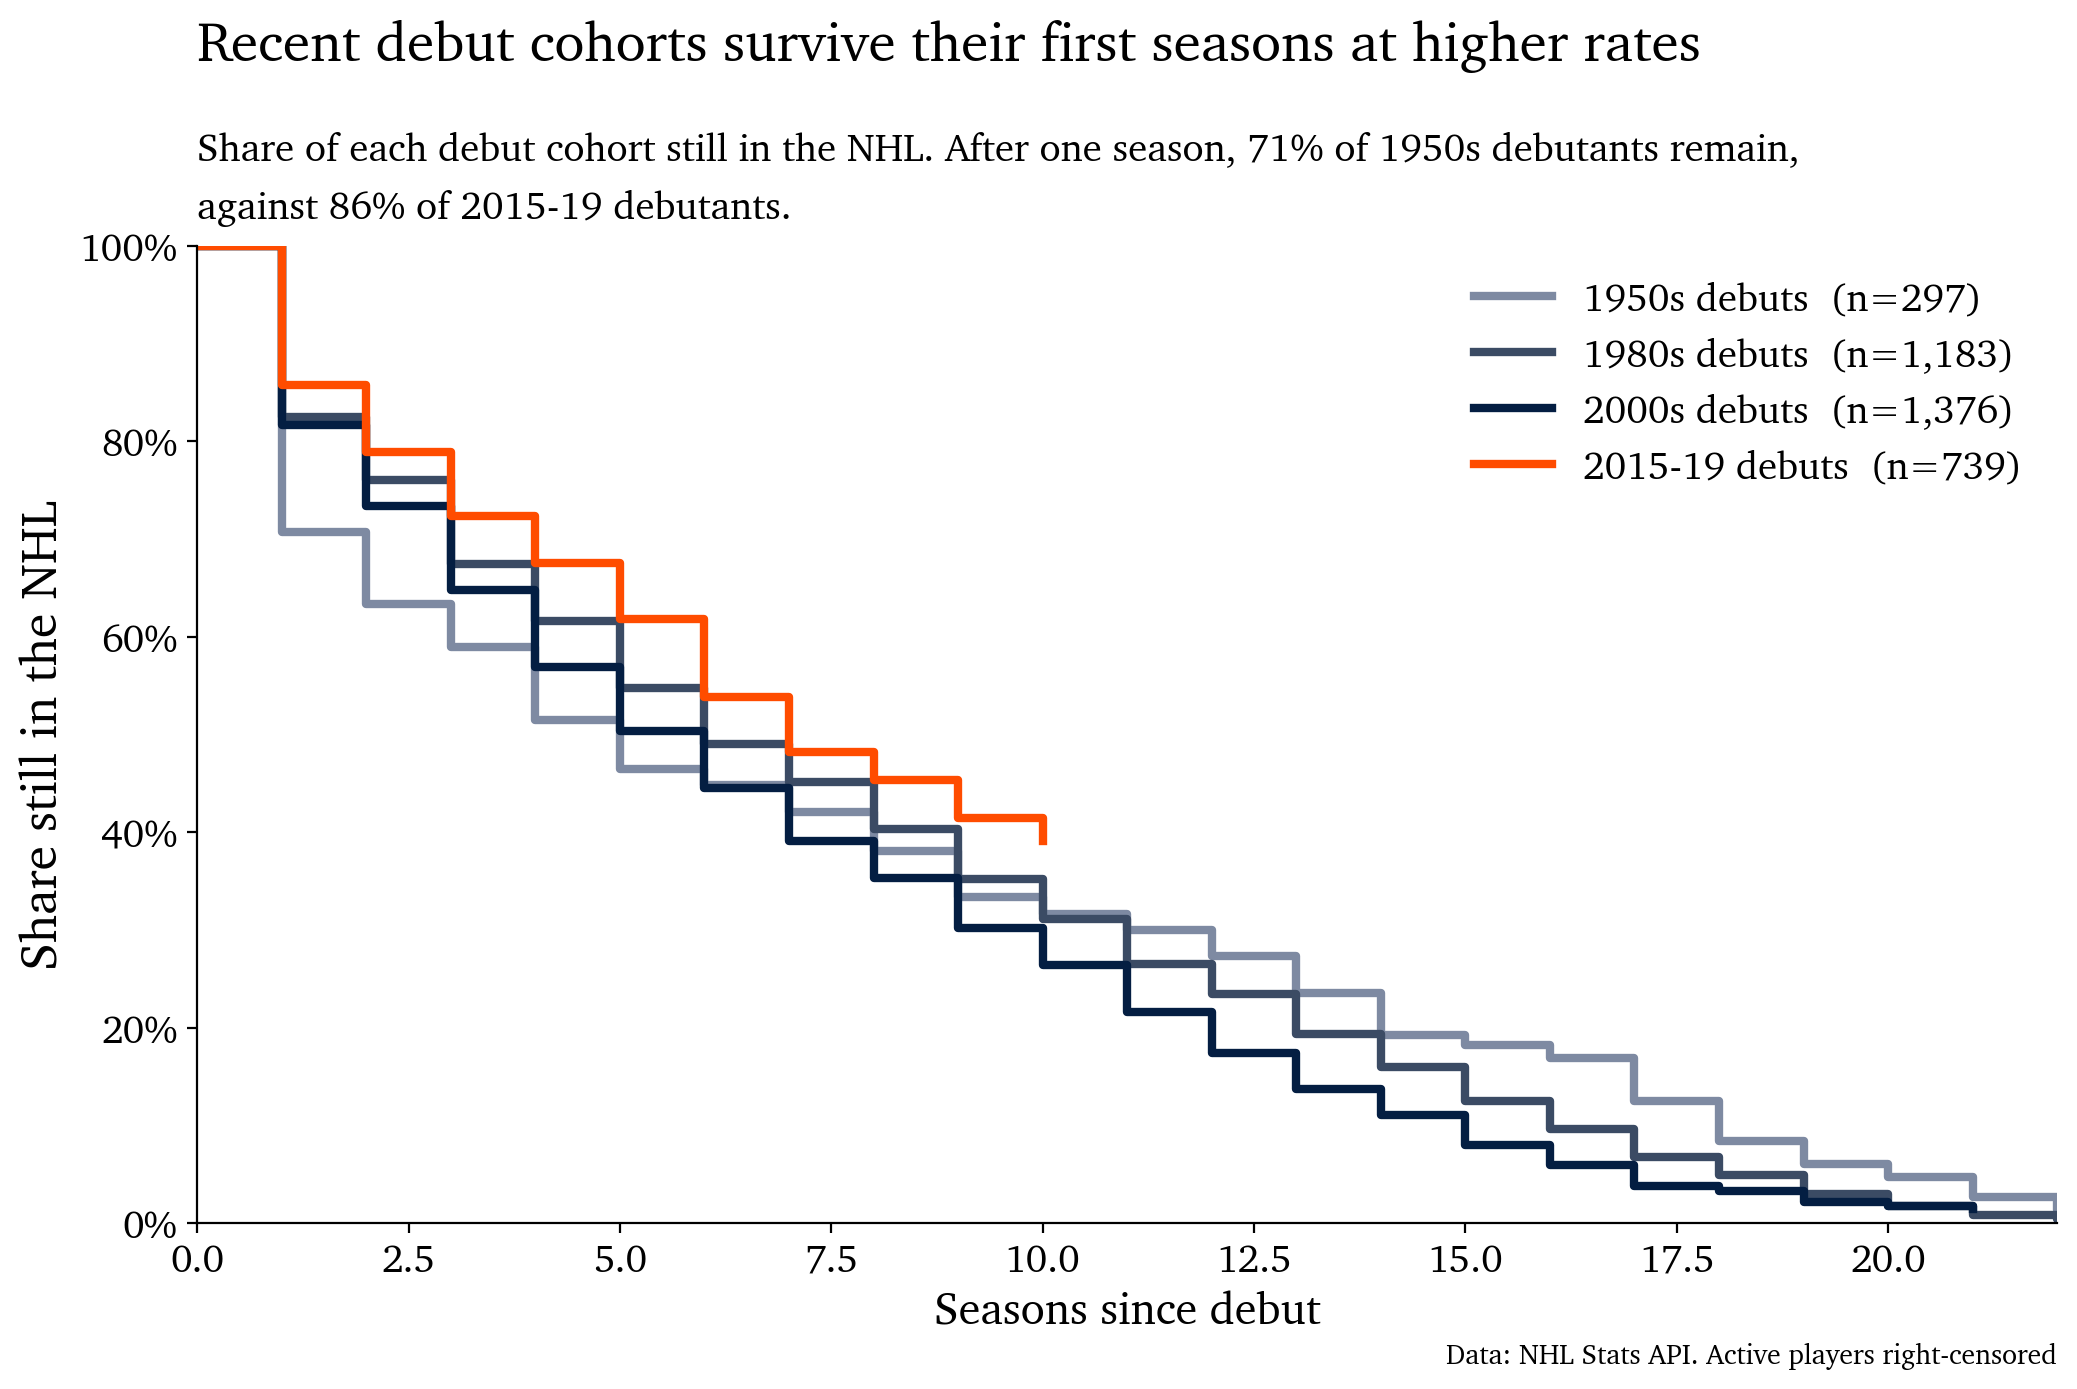

cohort,after 1,after 3,after 5,after 8
1950s debuts,71%,59%,46%,38%
1980s debuts,83%,67%,55%,40%
2000s debuts,82%,65%,50%,35%
2015-19 debuts,86%,72%,62%,45%


In [14]:
bands = [(1950, 1959, "1950s debuts", "#7E8AA2"), (1980, 1989, "1980s debuts", BLUE_PALE),
         (2000, 2009, "2000s debuts", BLUE_DARK), (2015, 2019, "2015-19 debuts", ORANGE)]
fig, ax = plt.subplots(figsize=(12, 7))
surv_rows = []
for lo_y, hi_y, lbl, c in bands:
    grp = car[car.first_year.between(lo_y, hi_y)]
    sf = km(grp)
    t = np.concatenate([[0], sf.surv_times])
    s = np.concatenate([[1.0], sf.surv_prob])
    ax.step(t, s, where="post", color=c, lw=3, label=f"{lbl}  (n={len(grp):,})")
    surv_rows.append({"cohort": lbl, **{f"after {k}": surv_at(sf, k) for k in [1, 3, 5, 8]}})
ax.set_xlim(0, 22)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y*100)}%"))
ax.set_xlabel("Seasons since debut", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share still in the NHL", fontsize=FS_AXIS_LABEL)
hd_legend(ax)
finish(fig, ax, "Recent debut cohorts survive their first seasons at higher rates",
       f"Share of each debut cohort still in the NHL. After one season, {surv_rows[0]['after 1']:.0%} of 1950s debutants remain, against {surv_rows[-1]['after 1']:.0%} of 2015-19 debutants.",
       "Data: NHL Stats API. Active players right-censored")
table(pd.DataFrame(surv_rows), {f"after {k}": "{:.0%}" for k in [1, 3, 5, 8]}, index=False,
      caption="Share of each cohort still in the league, by seasons since debut")

## What an NHL career actually looks like

The shape of the distribution explains a lot of what follows. Career length is heavily right-skewed: most players last a few seasons and a handful last twenty. So the mean sits well above the median, and the mean can move when the long tail moves even if the typical player doesn't change at all. Keep that in mind for the next section.

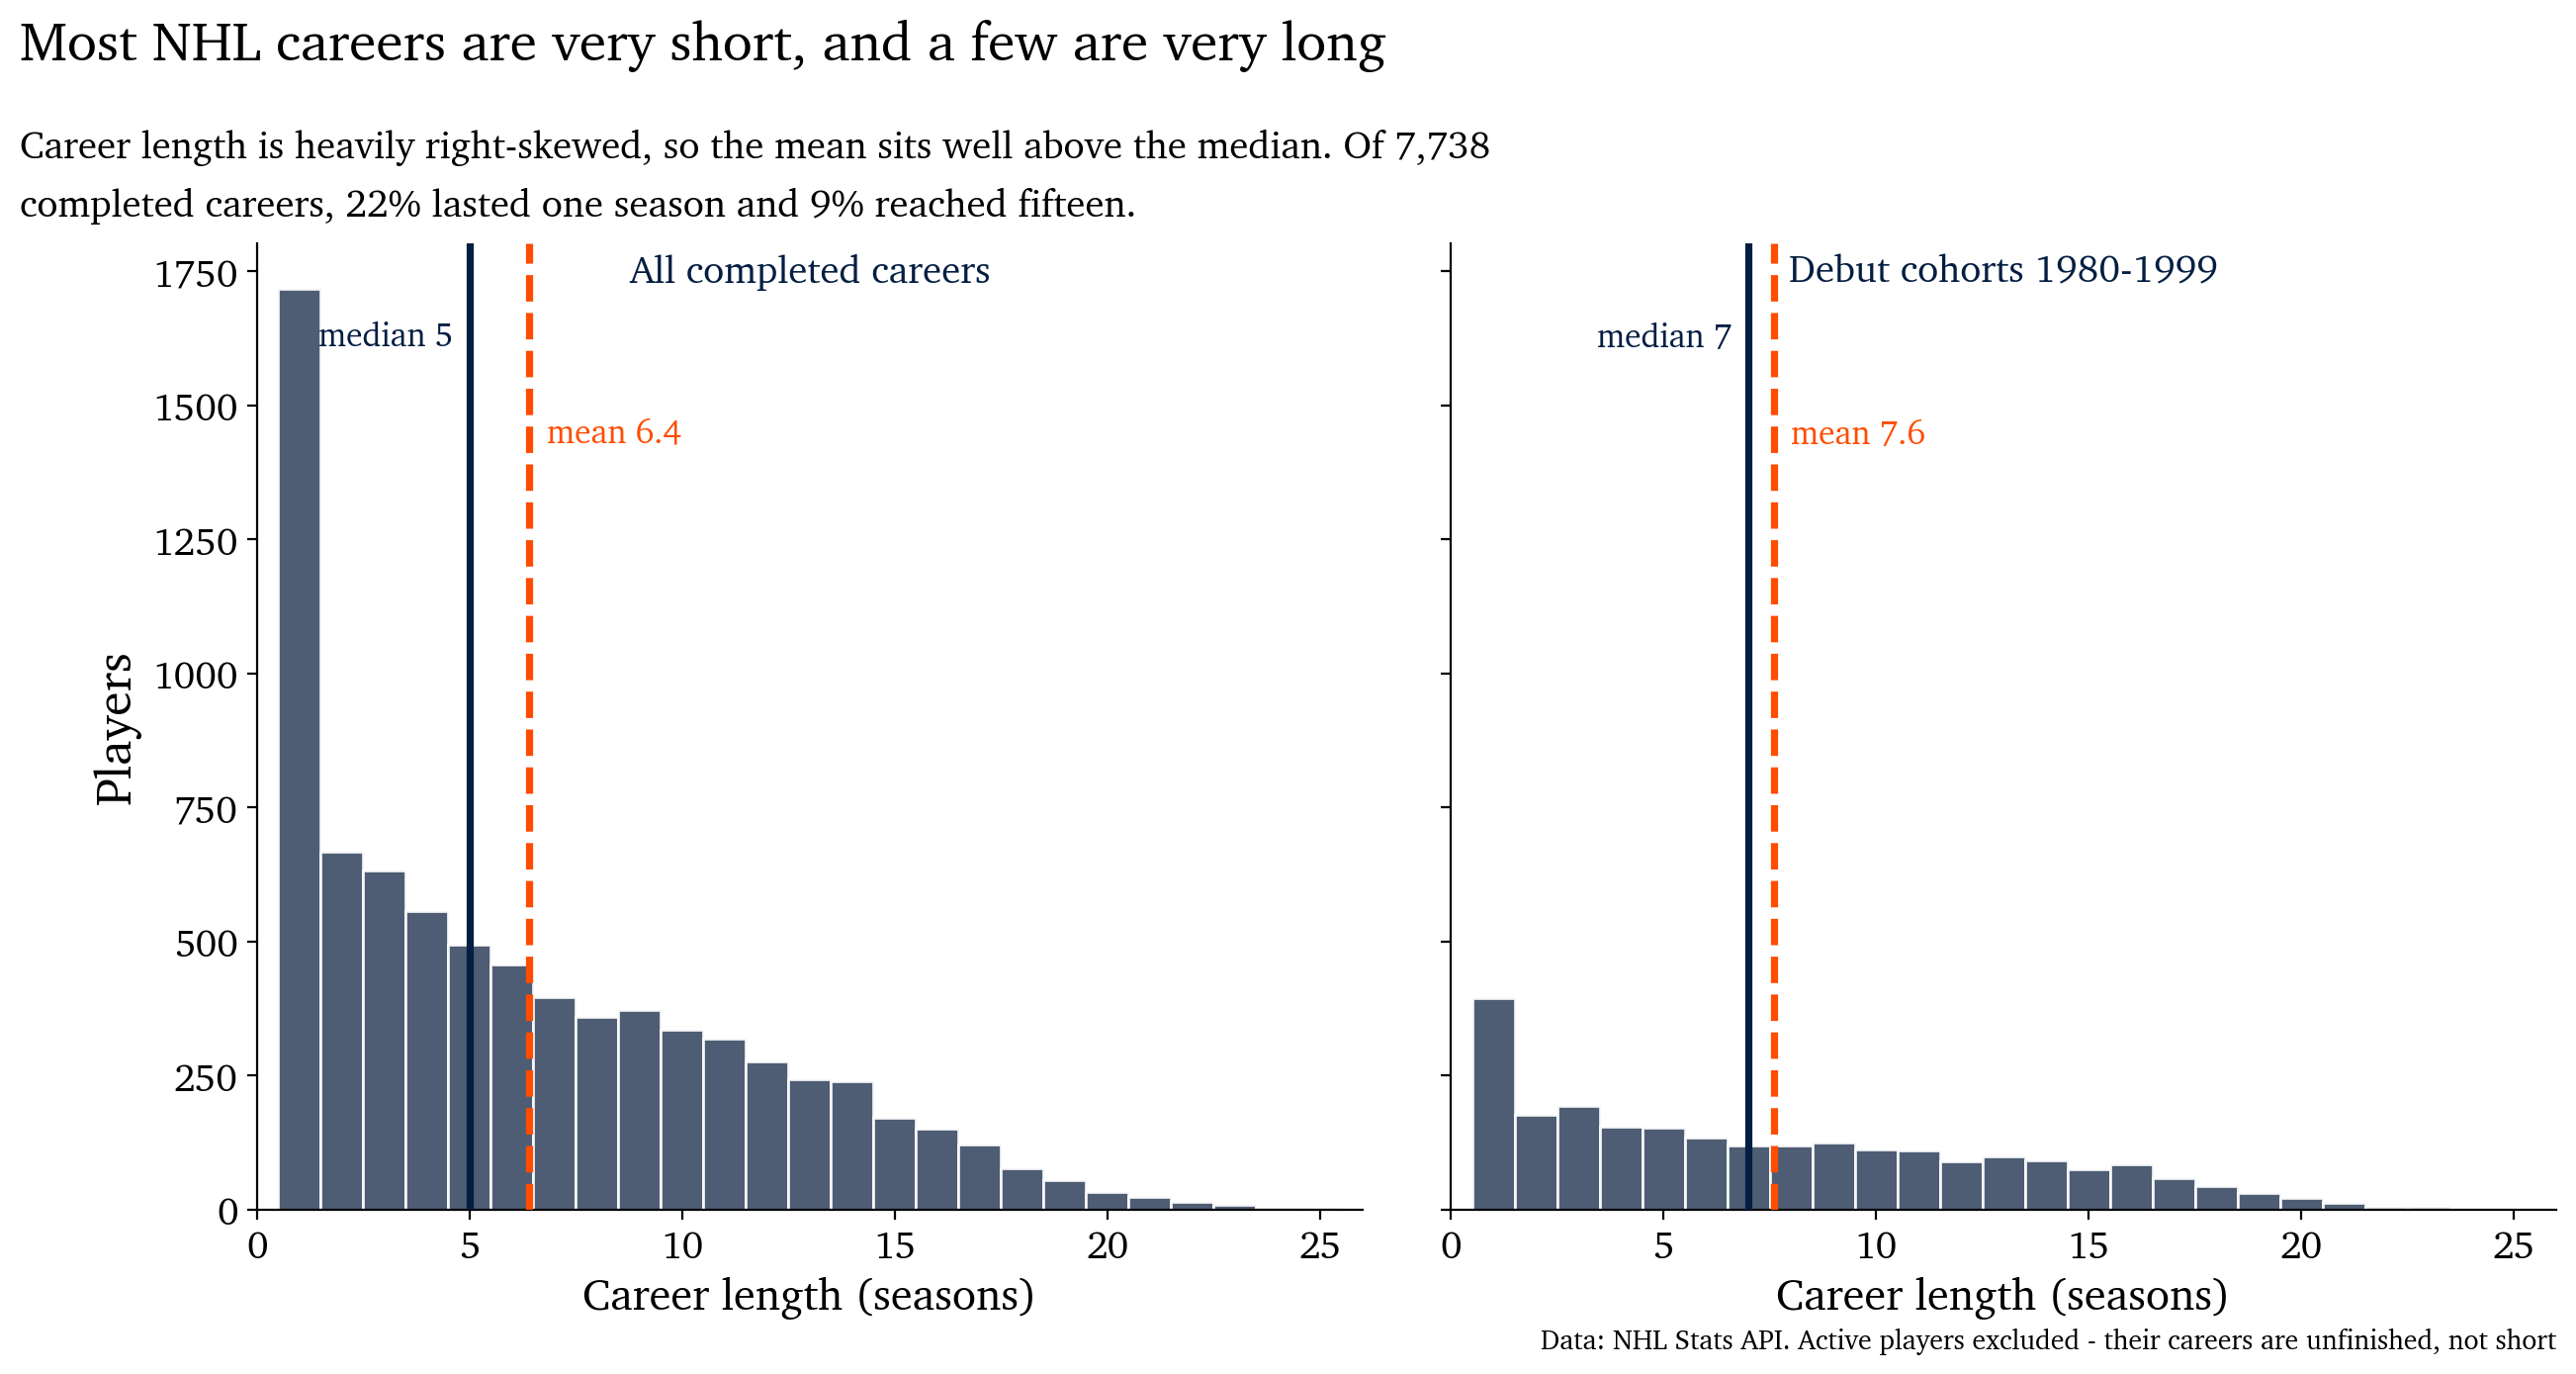

completed careers: n=7,738  mean 6.41  median 5  skew 0.84
span (seasons elapsed) differs from seasons actually played for 25% of players (mean gap 0.52 seasons)


In [15]:
done = car[~car.censored].copy()
cohort = done[done.first_year.between(1980, 1999)]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7), sharey=True, gridspec_kw={"wspace": 0.08})
BINS = np.arange(0.5, 26.5, 1)
for ax, d_, lbl in ((axL, done, "All completed careers"), (axR, cohort, "Debut cohorts 1980-1999")):
    ax.hist(d_.span, bins=BINS, color=BLUE_PALE, alpha=.9, edgecolor="white", lw=.6)
    mn, md = d_.span.mean(), d_.span.median()
    ax.axvline(md, color=BLUE_DARK, lw=2.6, zorder=4)
    ax.axvline(mn, color=ORANGE, lw=2.6, ls="--", zorder=4)
    top = ax.get_ylim()[1]
    ax.text(md - 0.4, top * .92, f"median {md:.0f}", color=BLUE_DARK, fontsize=12, ha="right", va="top")
    ax.text(mn + 0.4, top * .82, f"mean {mn:.1f}", color=ORANGE, fontsize=12, ha="left", va="top")
    ax.text(0.5, 0.99, lbl, transform=ax.transAxes, ha="center", va="top", fontsize=14,
            weight="bold", color=BLUE_DARK)
    ax.set_xlabel("Career length (seasons)", fontsize=FS_XAXIS_LABEL)
    ax.set_xlim(0, 26)
    sns.despine(ax=ax)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=FS_TICK)
axL.set_ylabel("Players", fontsize=FS_AXIS_LABEL)
finish(fig, axL, "Most NHL careers are very short, and a few are very long",
       f"Career length is heavily right-skewed, so the mean sits well above the median. Of {len(done):,} completed careers, {(done.span==1).mean()*100:.0f}% lasted one season and {(done.span>=15).mean()*100:.0f}% reached fifteen.",
       "Data: NHL Stats API. Active players excluded - their careers are unfinished, not short", title_x=0.045)
gap_ = done.span - done.n_seasons
print(f"completed careers: n={len(done):,}  mean {done.span.mean():.2f}  median {done.span.median():.0f}  "
      f"skew {done.span.skew():.2f}")
print(f"span (seasons elapsed) differs from seasons actually played for {(gap_ > 0).mean():.0%} of players "
      f"(mean gap {gap_.mean():.2f} seasons)")

## Are rookies arriving younger?

The other way you'd get more veterans is by bringing players in younger, so they have more runway to rack up seasons. Nope. Measured as age on October 1 of the debut season (skaters only; goalies aren't in the bio table), debut age has sat around 22 for most of the league's history.

,n,mean,median,p25,p75
1910s,62,27.5,27.0,24.8,29.8
1920s,260,24.7,23.7,21.6,27.2
1930s,272,22.9,22.6,21.2,24.4
1940s,358,22.5,21.9,20.3,24.4
1950s,265,21.9,21.5,19.9,23.5
1960s,358,22.8,22.0,20.5,24.2
1970s,891,22.2,21.5,20.4,23.4
1980s,"1,065",21.6,21.1,19.7,22.8
1990s,"1,129",22.3,22.1,20.6,23.6
2000s,"1,232",22.6,22.3,20.7,23.8


1950-2025 debuts: mean 22.2, median 21.8, IQR 20.4-23.5  (n=6,944)


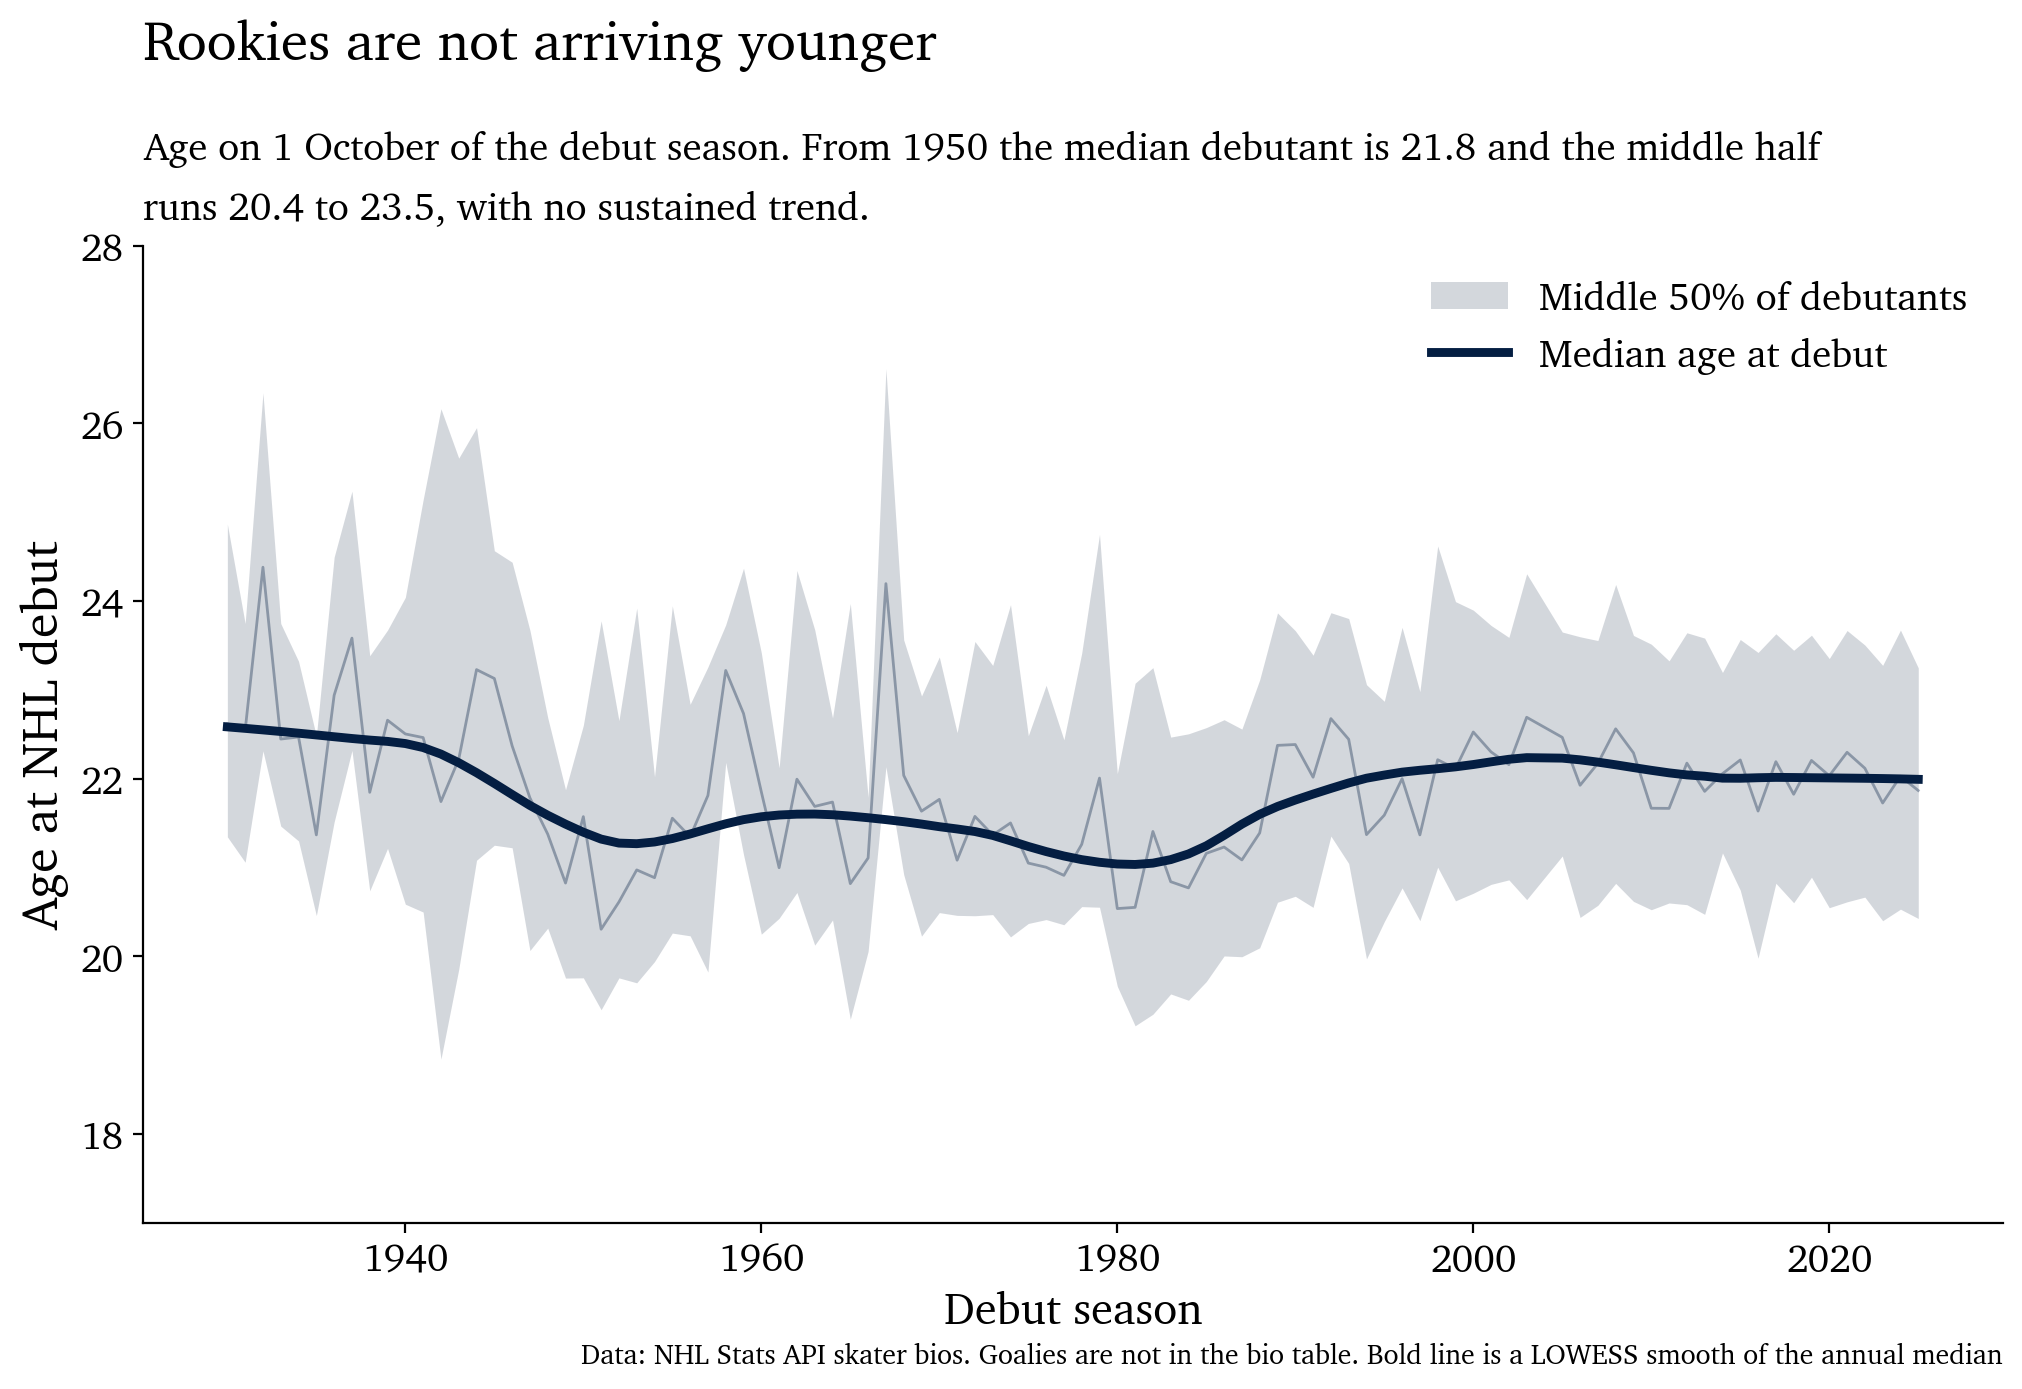

In [16]:
b = bios[["playerId", "birth_date"]].copy()
b["birth"] = pd.to_datetime(b.birth_date, errors="coerce")
da = car.merge(b, on="playerId")
da["debut_age"] = (pd.to_datetime(da.first_year.astype(str) + "-10-01") - da.birth).dt.days / 365.25
da = da[da.debut_age.between(16, 40)]
agg = da.groupby(da.first_year // 10 * 10).debut_age.agg(
    n="size", mean="mean", median="median", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75))
agg.index = [f"{i}s" for i in agg.index]
table(agg, {"n": "{:,}", "mean": "{:.1f}", "median": "{:.1f}", "p25": "{:.1f}", "p75": "{:.1f}"},
      caption="Age at debut (1 October of the debut season), skaters with a known birth date")
m50 = da[da.first_year.between(1950, 2025)]
print(f"1950-2025 debuts: mean {m50.debut_age.mean():.1f}, median {m50.debut_age.median():.1f}, "
      f"IQR {m50.debut_age.quantile(.25):.1f}-{m50.debut_age.quantile(.75):.1f}  (n={len(m50):,})")

yr_ = da[da.first_year >= 1930].groupby("first_year").debut_age
fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(yr_.quantile(.25).index, yr_.quantile(.25), yr_.quantile(.75), color=BLUE_PALE,
                alpha=.22, lw=0, label="Middle 50% of debutants")
ax.plot(yr_.median().index, yr_.median(), color=BLUE_DARK, lw=1, alpha=.35)
s_ = lowess(yr_.median().values, yr_.median().index.values, frac=.2, return_sorted=True)
ax.plot(s_[:, 0], s_[:, 1], color=BLUE_DARK, lw=3.2, label="Median age at debut")
ax.set_ylim(17, 28)
ax.set_xlabel("Debut season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Age at NHL debut", fontsize=FS_AXIS_LABEL)
hd_legend(ax, loc="upper right")
finish(fig, ax, "Rookies are not arriving younger",
       f"Age on 1 October of the debut season. From 1950 the median debutant is {m50.debut_age.median():.1f} and the middle half runs {m50.debut_age.quantile(.25):.1f} to {m50.debut_age.quantile(.75):.1f}, with no sustained trend.",
       "Data: NHL Stats API skater bios. Goalies are not in the bio table. Bold line is a LOWESS smooth of the annual median")

# Where the veterans come from

If careers haven't changed, the change has to be coming from how players flow through the league.

## Fewer players coming in

The number of players debuting each season has barely grown since the 1980s, while the league kept adding teams. So each season, a smaller share of the league is new. And since the league isn't shrinking, it has to lose players at about the rate it adds them. Fewer coming in means fewer going out, and the ones who stay are further into their careers on average.

Here are the raw flows by era. The last column is a handy way to think about it: how many players are in the league for every one who debuts.

How big the change looks depends a lot on which decade you compare against, so here's the 2020s against a few different baselines:

In [17]:
flow_ps = (player_seasons.drop_duplicates(["playerId", "season"])
           .merge(car[["playerId", "first_year", "last_year", "first_idx"]], on="playerId"))
flow_ps["yr"] = flow_ps.season // 10000
flow_ps["sidx"] = flow_ps.yr.map(season_order)
flow_ps["ten"] = flow_ps.sidx - flow_ps.first_idx + 1
flow_ps["deb"] = flow_ps.yr == flow_ps.first_year
flow_ps["ext"] = flow_ps.yr == flow_ps.last_year
ts_ = team_seasons.assign(yr=team_seasons.season // 10000)
FL = flow_ps.groupby("yr").agg(players=("playerId", "nunique"), debuts=("deb", "sum"), exits=("ext", "sum"))
FL["teams"] = ts_.groupby("yr").teamId.nunique()
FL.loc[LAST, "exits"] = np.nan          # nobody can be seen to leave in the last season
FL["in_pct"] = FL.debuts / FL.players
FL["out_pct"] = FL.exits / FL.players

rows = []
for lo, hi in [(1942, 1966), (1967, 1978), (1979, 1990), (1991, 2000), (2001, 2010),
               (2011, 2020), (2021, LAST)]:
    w = FL.loc[lo:hi]
    rows.append({"period": f"{lo}-{hi}", "teams": w.teams.mean(), "players": w.players.mean(),
                 "debuts": w.debuts.mean(), "exits": w.exits.mean(),
                 "debuts / players": w.debuts.sum() / w.players.sum(),
                 "exits / players": w.exits.sum() / w.players.loc[w.exits.notna()].sum(),
                 "players per debut": w.players.sum() / w.debuts.sum()})
table(pd.DataFrame(rows), {"teams": "{:.1f}", "players": "{:,.0f}", "debuts": "{:.0f}", "exits": "{:.0f}",
                           "debuts / players": "{:.1%}", "exits / players": "{:.1%}",
                           "players per debut": "{:.1f}"}, index=False)

now = FL.loc[2020:]
rows = []
for a, b_, lbl in [(1942, 1966, "Original Six"), (1960, 1969, "1960s"), (1970, 1979, "1970s"),
                   (1980, 1989, "1980s"), (1990, 1999, "1990s"), (2000, 2009, "2000s")]:
    base = FL.loc[a:b_]
    rows.append({"baseline": lbl, "league size": now.players.mean() / base.players.mean(),
                 "debuts": now.debuts.mean() / base.debuts.mean(),
                 "exits": now.exits.mean() / base.exits.mean()})
table(pd.DataFrame(rows), {"league size": "{:.2f}x", "debuts": "{:.2f}x", "exits": "{:.2f}x"}, index=False,
      caption="2020s average relative to each baseline")

period,teams,players,debuts,exits,debuts / players,exits / players,players per debut
1942-1966,6.0,153,32,28,21.2%,18.6%,4.7
1967-1978,15.4,423,83,65,19.7%,15.3%,5.1
1979-1990,21.0,692,126,105,18.2%,15.2%,5.5
1991-2000,26.1,858,128,109,14.9%,12.7%,6.7
2001-2010,30.0,968,152,153,15.7%,15.8%,6.4
2011-2020,30.4,980,143,133,14.6%,13.6%,6.9
2021-2025,32.0,"1,053",132,154,12.6%,14.6%,8.0


baseline,league size,debuts,exits
Original Six,6.86x,4.09x,5.11x
1960s,4.95x,3.28x,6.46x
1970s,2.20x,1.33x,1.82x
1980s,1.51x,1.12x,1.38x
1990s,1.25x,1.06x,1.42x
2000s,1.08x,0.87x,0.95x


The figure from the post: the size of the league, the rookies inside it, and the players leaving it each season.

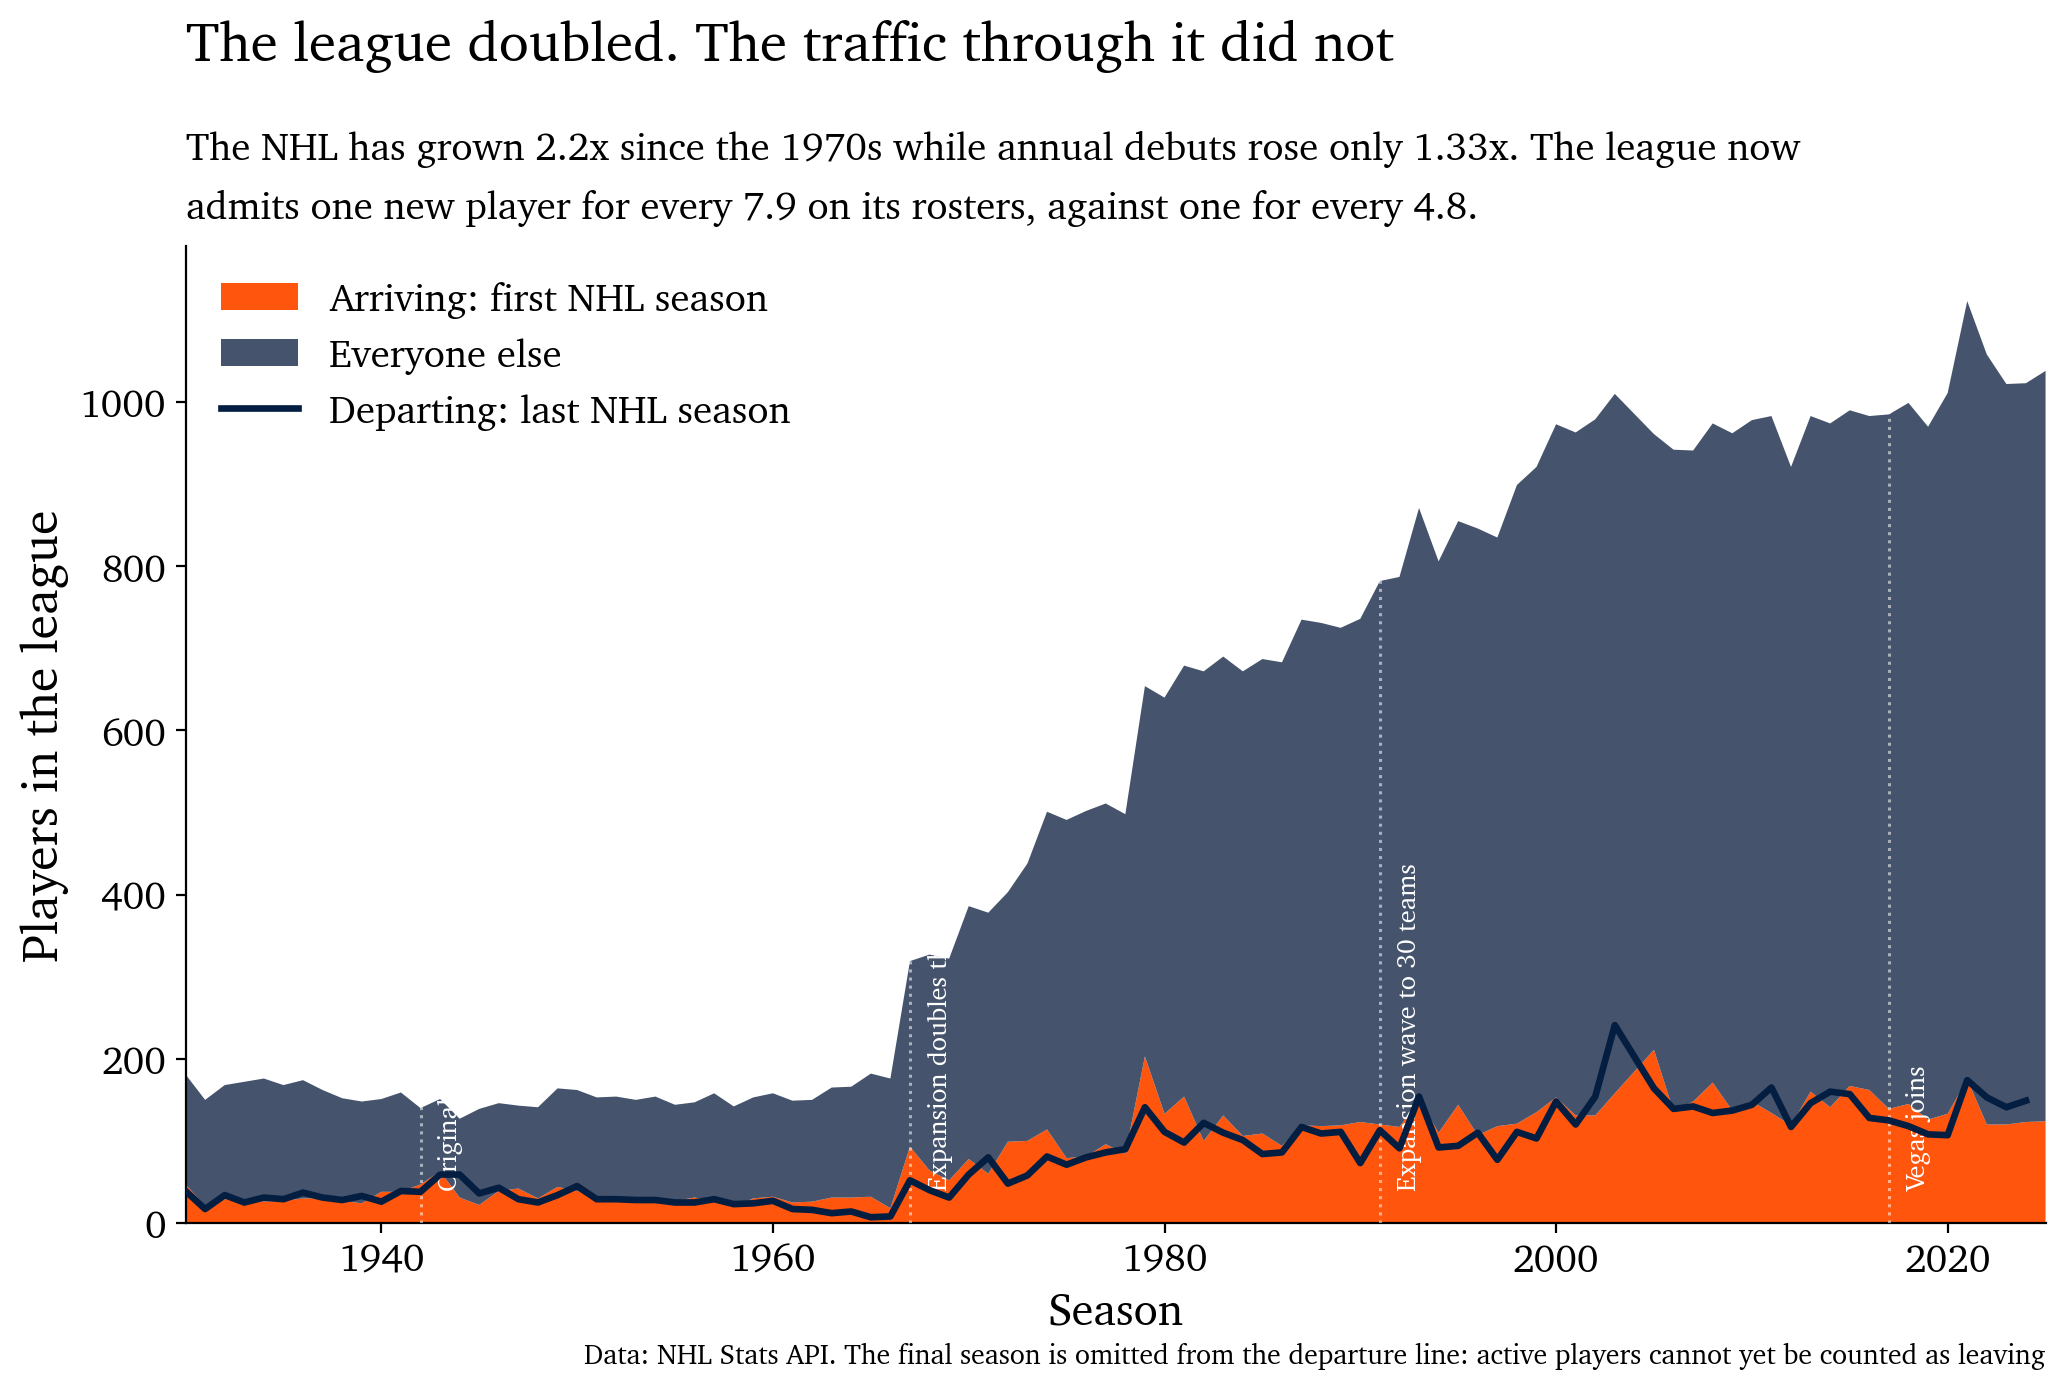

In [18]:
FX = FL.loc[:LAST - 1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(FL.index, 0, FL.debuts, color=ORANGE, alpha=.95, lw=0, label="Arriving: first NHL season")
ax.fill_between(FL.index, FL.debuts, FL.players, color=BLUE_PALE, alpha=.95, lw=0, label="Everyone else")
ax.plot(FX.index, FX.exits, color=BLUE_DARK, lw=2.4, zorder=4, label="Departing: last NHL season")
for yr, lbl in ERA_MARKS:
    ax.axvline(yr, color="white", lw=1.1, ls=":", alpha=.55, zorder=3)
    ax.text(yr + 0.9, 40, lbl, fontsize=9.5, color="white", rotation=90, va="bottom")
ax.set_xlim(1930, LAST)
ax.set_ylim(0, FL.players.max() * 1.06)
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Players in the league", fontsize=FS_AXIS_LABEL)
hd_legend(ax, loc="upper left")
p70, p20 = FL.loc[1970:1979, "players"].mean(), FL.loc[2020:, "players"].mean()
# debuts are observable in the final season (exits are not), so both use the full window
d70, d20 = FL.loc[1970:1979, "debuts"].mean(), FL.loc[2020:, "debuts"].mean()
finish(fig, ax, "The league doubled. The traffic through it did not",
       f"The NHL has grown {p20/p70:.1f}x since the 1970s while annual debuts rose only {d20/d70:.2f}x. The league now admits one new player for every {p20/d20:.1f} on its rosters, against one for every {p70/d70:.1f}.",
       "Data: NHL Stats API. The final season is omitted from the departure line: active players cannot yet be counted as leaving")

The same flows as a share of the league. Arrivals fell a lot after the 1970s; departures fell less.

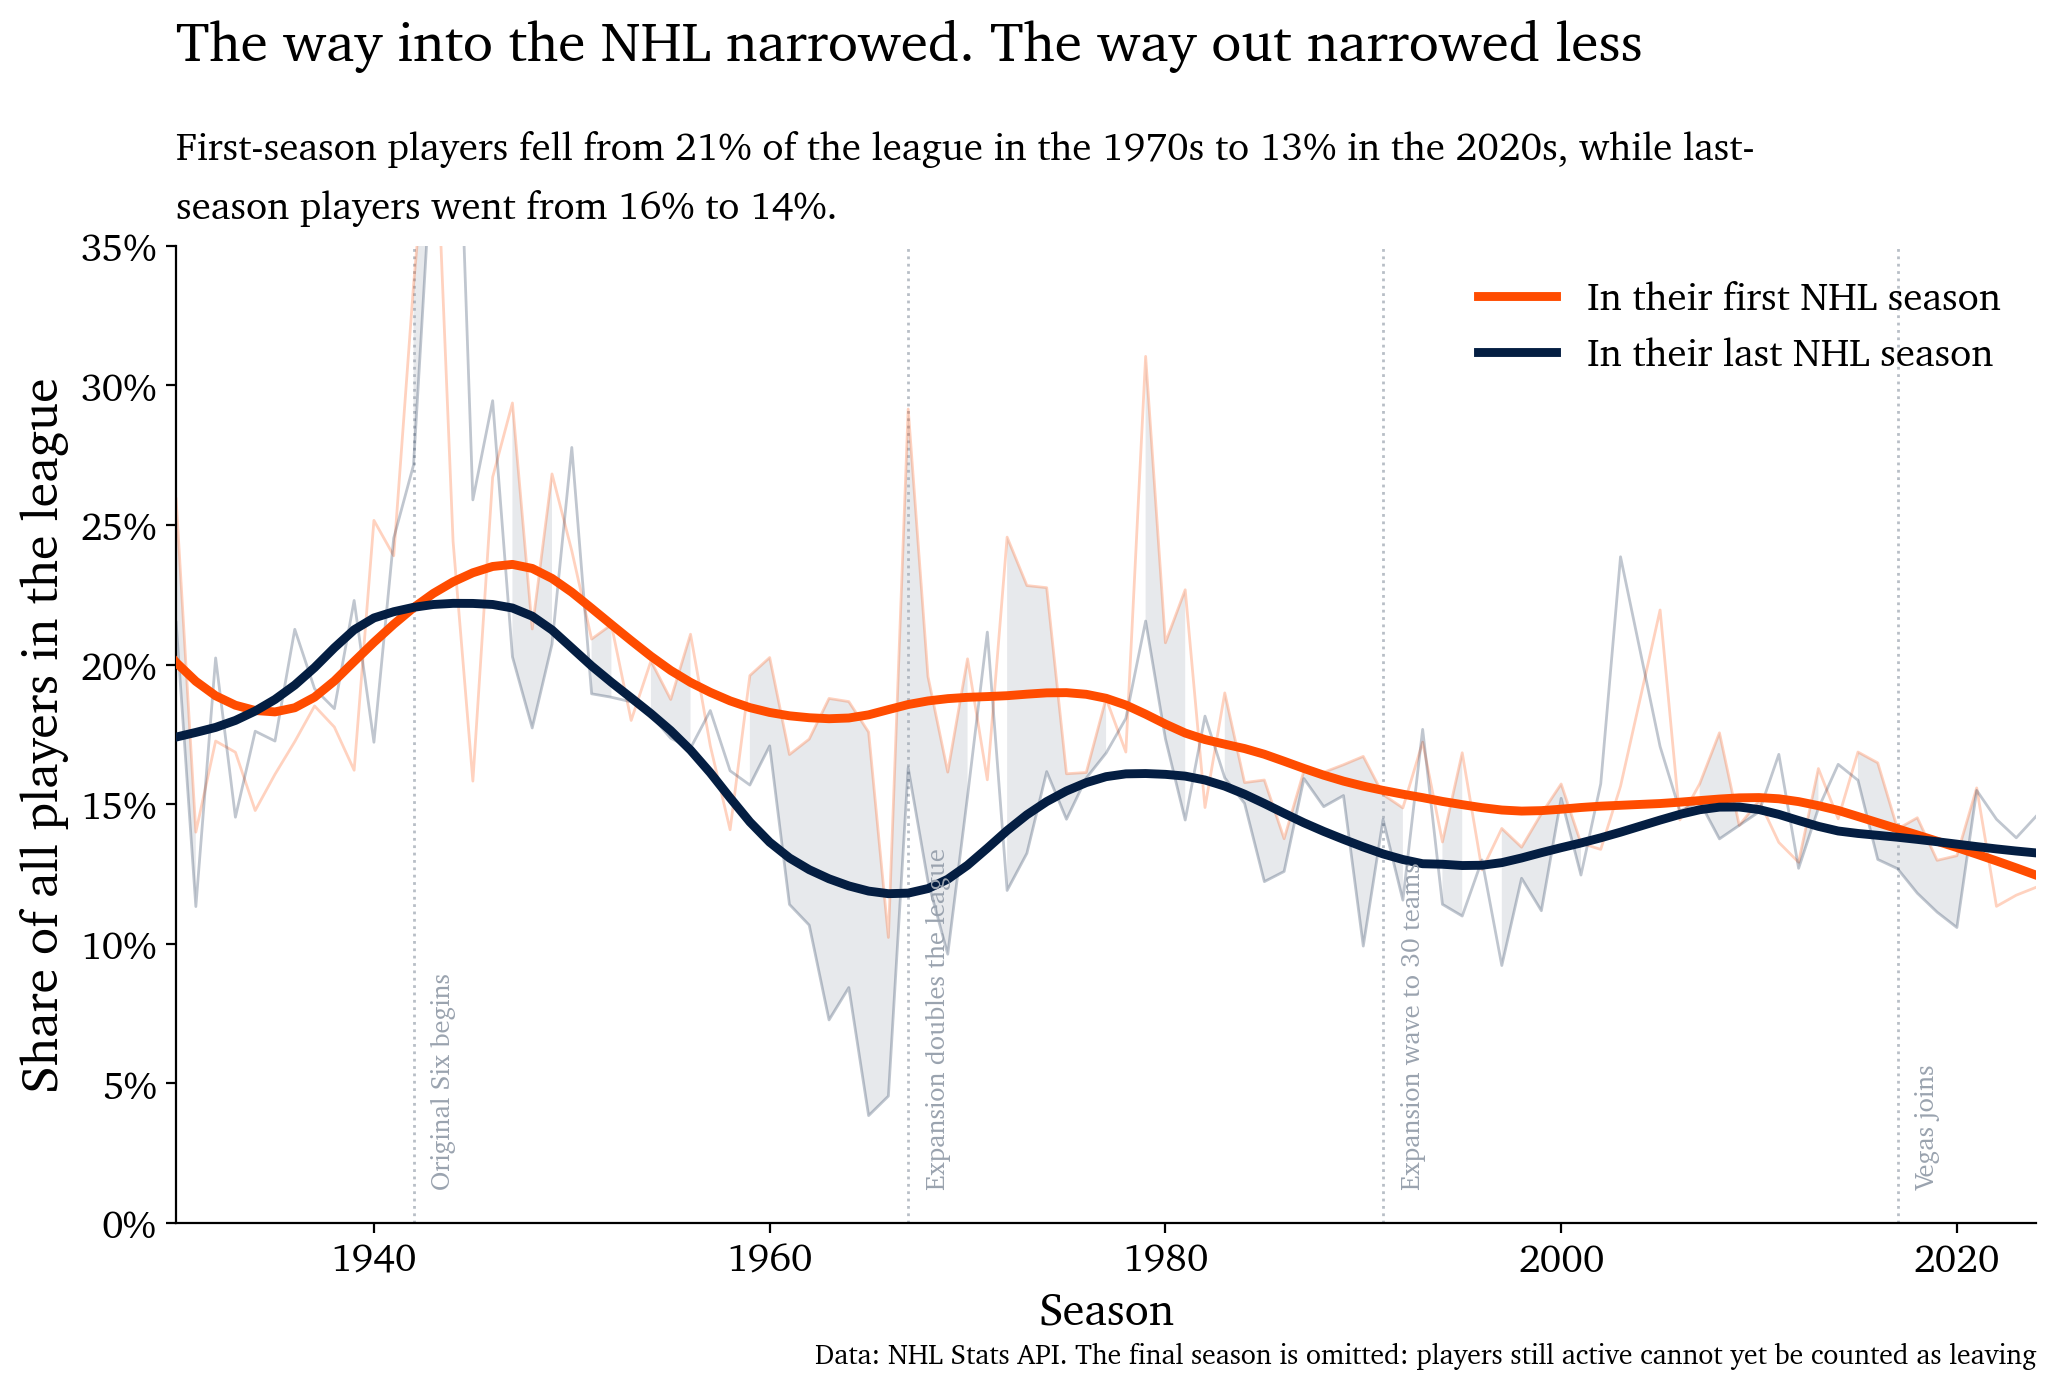

In [19]:
FS_ = FL.loc[:LAST - 1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(FS_.index, FS_.in_pct, FS_.out_pct, where=FS_.in_pct >= FS_.out_pct,
                color=BLUE_PALE, alpha=.12, lw=0, zorder=1)
for col, colour, lbl in [("in_pct", ORANGE, "In their first NHL season"),
                         ("out_pct", BLUE_DARK, "In their last NHL season")]:
    ax.plot(FS_.index, FS_[col], color=colour, lw=1.0, alpha=.25, zorder=2)
    s_ = lowess(FS_[col].values, FS_.index.values, frac=.20, return_sorted=True)
    ax.plot(s_[:, 0], s_[:, 1], color=colour, lw=3.2, zorder=3, label=lbl)
for yr, lbl in ERA_MARKS:
    ax.axvline(yr, color=GRAY, lw=1, ls=":", alpha=.7, zorder=1)
    ax.text(yr + 0.9, 0.012, lbl, fontsize=9.5, color=GRAY, rotation=90, va="bottom")
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share of all players in the league", fontsize=FS_AXIS_LABEL)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v*100)}%"))
ax.set_xlim(1930, LAST - 1)
ax.set_ylim(0, 0.35)
hd_legend(ax, loc="upper right")
i70, i20 = FS_.loc[1970:1979, "in_pct"].mean(), FS_.loc[2020:, "in_pct"].mean()
o70, o20 = FS_.loc[1970:1979, "out_pct"].mean(), FS_.loc[2020:, "out_pct"].mean()
finish(fig, ax, "The way into the NHL narrowed. The way out narrowed less",
       f"First-season players fell from {i70*100:.0f}% of the league in the 1970s to {i20*100:.0f}% in the 2020s, while last-season players went from {o70*100:.0f}% to {o20*100:.0f}%.",
       "Data: NHL Stats API. The final season is omitted: players still active cannot yet be counted as leaving")

## Who is leaving

This is the "who's leaving" figure from the post: the share of players at each stage of their career who never play another NHL season. Each point pools five seasons, and the bands are 95% intervals. Rookies wash out at about the same rate they always have. Players in their tenth season or later left at about 24% a year in the mid-2000s; now it's 17%.

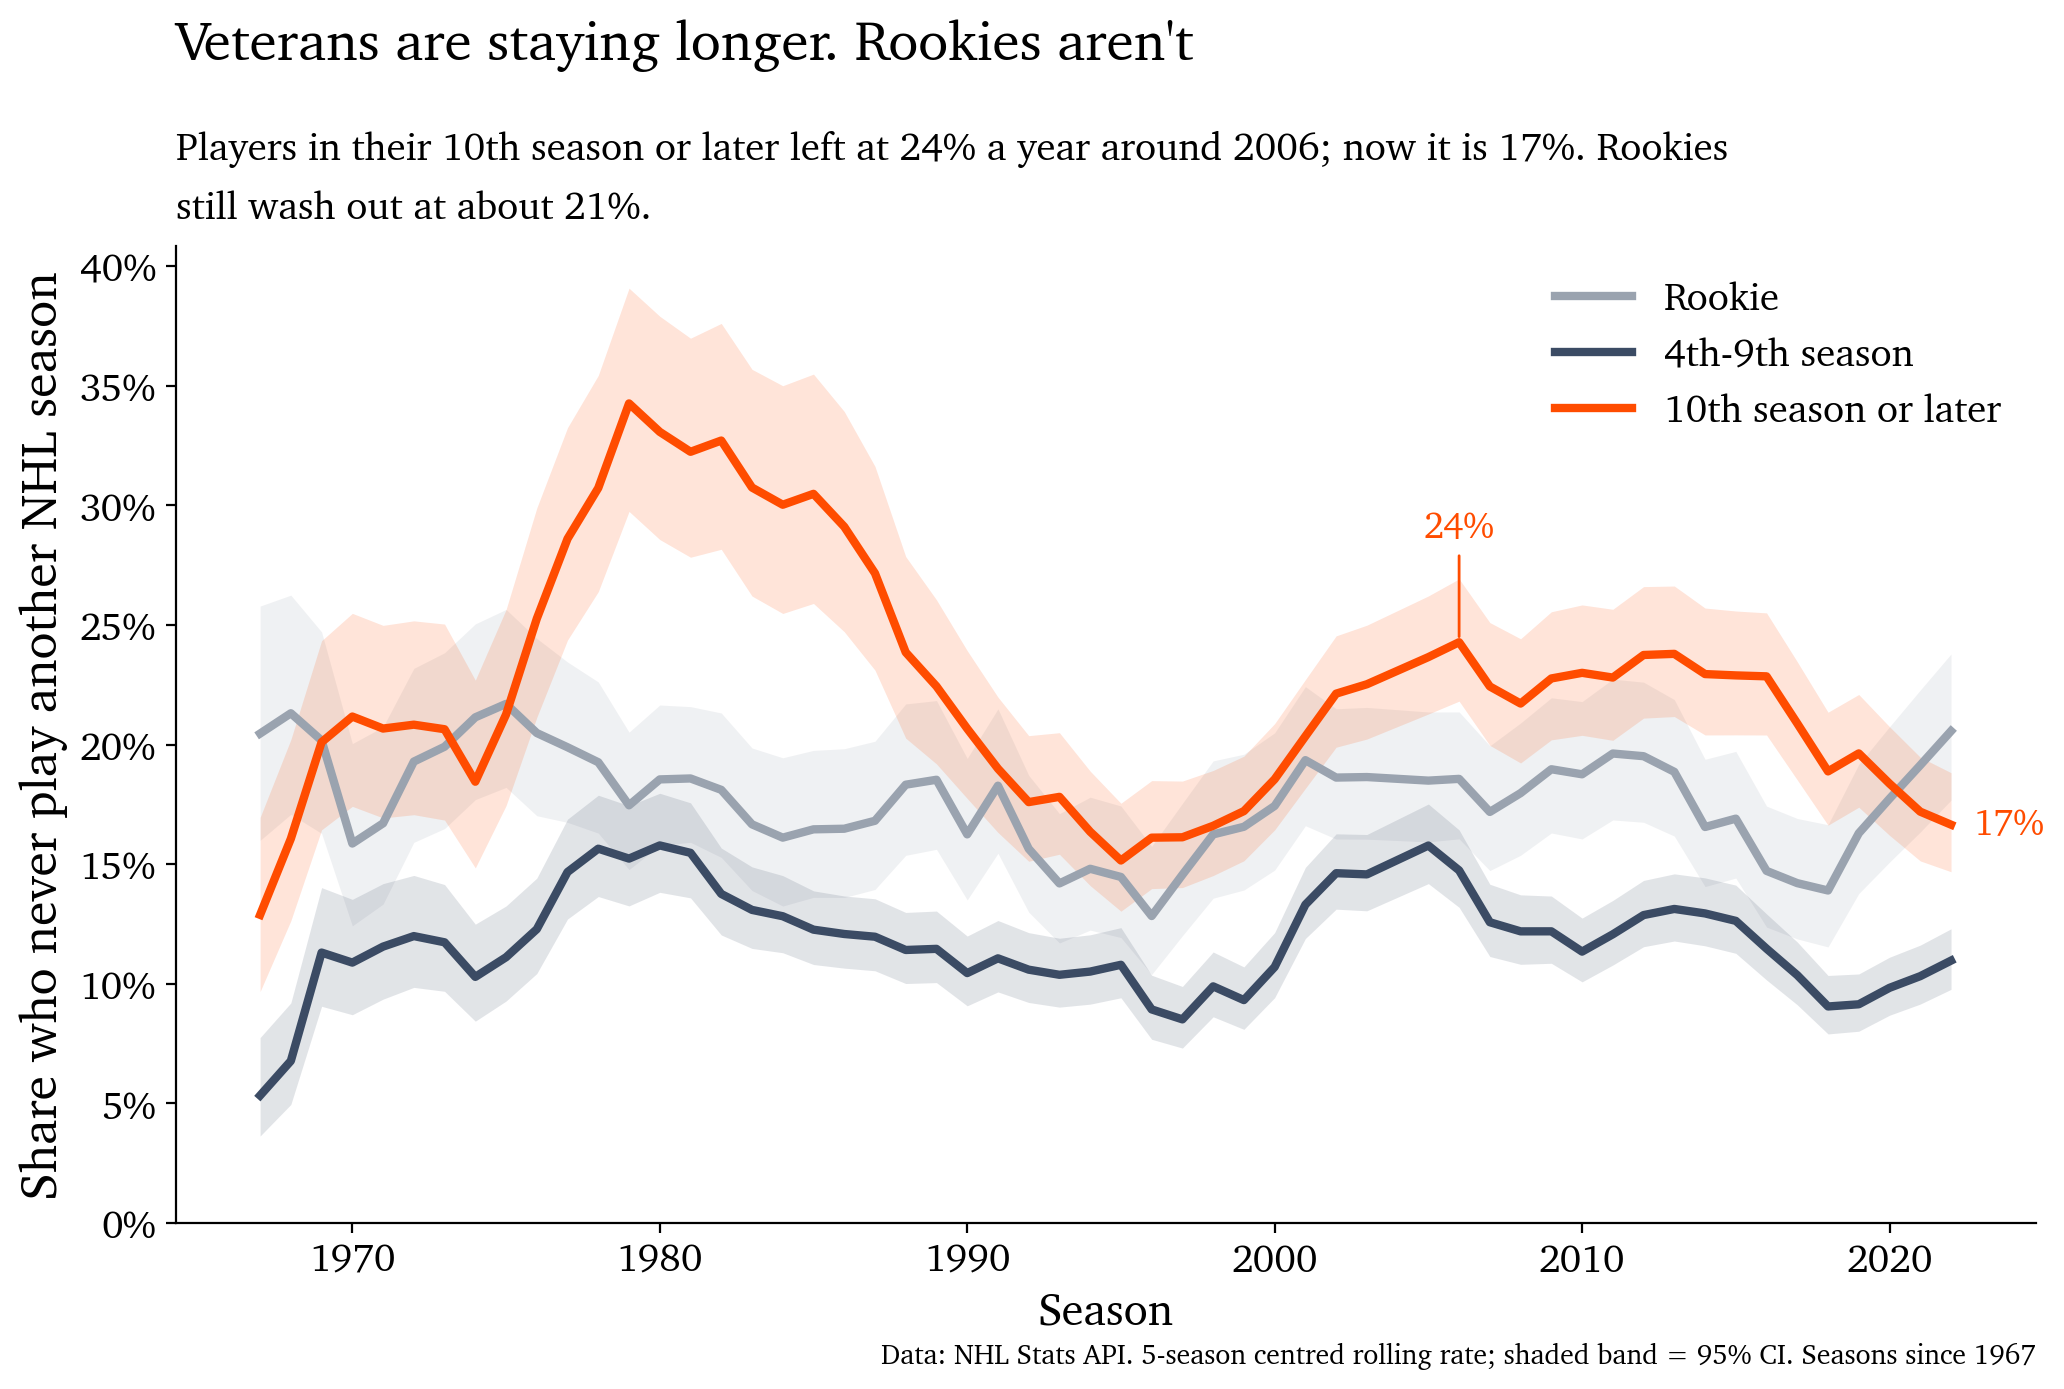

In [20]:
EX_WIN, EX_START = 5, 1967
EX_GROUPS = [("Rookie", flow_ps.ten == 1, GRAY),
             ("4th-9th season", flow_ps.ten.between(4, 9), BLUE_PALE),
             ("10th season or later", flow_ps.ten >= 10, ORANGE)]


def wilson(k, n, z=1.96):
    p = k / n
    d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return c - h, c + h


fig, ax = plt.subplots(figsize=(12, 7))
EXR = {}
for lbl, mask, colour in EX_GROUPS:
    g = flow_ps[mask & (flow_ps.yr < LAST)].groupby("yr").ext.agg(["sum", "size"])
    r = g.rolling(EX_WIN, center=True, min_periods=EX_WIN).sum().dropna()
    r = r[r.index >= EX_START]
    EXR[lbl] = r["sum"] / r["size"]
    lo, hi = wilson(r["sum"], r["size"])
    ax.fill_between(r.index, lo, hi, color=colour, alpha=.15, lw=0)
    ax.plot(r.index, EXR[lbl], color=colour, lw=3, label=lbl)
vet = EXR["10th season or later"]
peak = vet.loc[1990:].idxmax()
ax.annotate(f"{vet[peak]:.0%}", (peak, vet[peak]), xytext=(0, 38), textcoords="offset points",
            ha="center", fontsize=13, color=ORANGE, arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1))
ax.annotate(f"{vet.iloc[-1]:.0%}", (vet.index[-1], vet.iloc[-1]), xytext=(8, 0),
            textcoords="offset points", va="center", fontsize=13, color=ORANGE)
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share who never play another NHL season", fontsize=FS_AXIS_LABEL)
hd_legend(ax, loc="upper right")
finish(fig, ax, "Veterans are staying longer. Rookies aren't",
       f"Players in their 10th season or later left at {vet[peak]:.0%} a year around {peak}; now it is {vet.iloc[-1]:.0%}. Rookies still wash out at about {EXR['Rookie'].iloc[-1]:.0%}.",
       f"Data: NHL Stats API. {EX_WIN}-season centred rolling rate; shaded band = 95% CI. Seasons since {EX_START}")

### Digging into the exit rates

Here's the full table by period, with a couple more tenure groups than the figure shows. Then a direct comparison of 2001-08 with the latest eight seasons.

Rookie exits haven't budged (18.1% then, 18.3% now). Veteran exits fell by almost five points, which is very unlikely to be noise. The interesting extra wrinkle is that it isn't only the ten-year veterans: players in their 4th to 9th seasons also got noticeably stickier, going from 13.9% to 10.1%. So the fuller picture is that once you're **established** in the league, you're more likely to stay than you used to be, while the washout rate at the door hasn't changed at all.

In [21]:
X = flow_ps[(flow_ps.yr < LAST)].copy()
X["grp"] = pd.cut(X.ten, [0, 1, 3, 9, 99], labels=["Rookie", "2nd-3rd", "4th-9th", "10th+"])
X["period"] = pd.cut(X.yr, [1966, 1979, 1990, 2000, 2008, 2016, LAST - 1],
                     labels=["1967-79", "1980-90", "1991-2000", "2001-08", "2009-16", f"2017-{LAST-1}"])
tab = X.groupby(["period", "grp"], observed=True).ext.mean().unstack()
table(tab, "{:.1%}", caption="Share who never play another NHL season, by tenure and period")

rows = []
for g in ["Rookie", "2nd-3rd", "4th-9th", "10th+"]:
    a = X[(X.grp == g) & X.yr.between(2001, 2008)]
    b_ = X[(X.grp == g) & X.yr.between(2017, LAST - 1)]
    t = sm.stats.proportions_ztest([b_.ext.sum(), a.ext.sum()], [len(b_), len(a)])
    rows.append({"tenure": g, "2001-08": a.ext.mean(), f"2017-{LAST-1}": b_.ext.mean(),
                 "change (pts)": (b_.ext.mean() - a.ext.mean()) * 100,
                 "z": t[0], "p-value": t[1], "n (recent)": len(b_)})
table(pd.DataFrame(rows), {"2001-08": "{:.1%}", f"2017-{LAST-1}": "{:.1%}", "change (pts)": "{:+.1f}",
                           "z": "{:+.2f}", "p-value": "{:.4f}", "n (recent)": "{:,}"}, index=False,
      caption="Exit rates, 2001-08 against the most recent eight seasons, two-proportion z-test")

grp,Rookie,2nd-3rd,4th-9th,10th+
period,,,,
1967-79,20.1%,12.8%,12.5%,23.0%
1980-90,17.5%,10.9%,12.4%,27.1%
1991-2000,15.2%,11.4%,10.1%,17.1%
2001-08,18.1%,11.8%,13.9%,22.6%
2009-16,18.0%,9.9%,12.6%,22.8%
2017-2024,18.3%,10.7%,10.1%,17.9%


tenure,2001-08,2017-2024,change (pts),z,p-value,n (recent)
Rookie,18.1%,18.3%,+0.2,+0.11,0.9153,"1,081"
2nd-3rd,11.8%,10.7%,-1.1,-0.94,0.3464,"1,629"
4th-9th,13.9%,10.1%,-3.8,-4.56,0.0000,"3,608"
10th+,22.6%,17.9%,-4.7,-3.43,0.0006,"1,873"


### Players who leave and come back

"Never plays another NHL season" has one wrinkle: some players sit out a year (injury, Europe, contract) and come back. Here's how often a player who misses the next season shows up again later.

The 2020s row looks low only because those comebacks haven't had time to happen yet. That means the most recent exit rates are, if anything, a little too high, so the drop in veteran exits is probably slightly bigger than it looks.

In [22]:
# How often does a player's 'last season' turn out not to be? Measure it where we can see it:
# for every season, the share of players who miss the next season but are back later.
act = {y: set(g.playerId) for y, g in flow_ps.groupby("yr")}
Y = sorted(act)
nxt = {y: Y[i + 1] for i, y in enumerate(Y[:-1])}
later = {y: set().union(*[act[z] for z in Y[i + 2:]]) if i + 2 < len(Y) else set() for i, y in enumerate(Y)}
rr = flow_ps[flow_ps.yr.isin(nxt)].copy()
rr["back_next"] = [p in act[nxt[y]] for p, y in zip(rr.playerId, rr.yr)]
rr["back_later"] = [(not bn) and (p in later[y]) for p, y, bn in zip(rr.playerId, rr.yr, rr.back_next)]
rr["grp"] = np.where(rr.ten >= 10, "10th+", np.where(rr.ten == 1, "Rookie", "2nd-9th"))
gone = rr[~rr.back_next]
comeback = gone.groupby([gone.yr // 10 * 10, "grp"]).back_later.mean().unstack()
comeback.index = [f"{i}s" for i in comeback.index]
table(comeback.loc["1960s":], "{:.1%}",
      caption="Of players who miss the following season, the share who come back later")
print("The last few seasons cannot show a comeback yet, so recent exit rates are biased up, "
      "and the recent fall in veteran exits is if anything understated.")

grp,10th+,2nd-9th,Rookie
1960s,26.5%,55.2%,48.4%
1970s,8.1%,21.2%,31.1%
1980s,2.1%,24.1%,35.5%
1990s,7.4%,31.5%,43.9%
2000s,5.0%,23.1%,33.1%
2010s,4.0%,25.3%,39.5%
2020s,5.9%,17.2%,20.7%


The last few seasons cannot show a comeback yet, so recent exit rates are biased up, and the recent fall in veteran exits is if anything understated.


A stricter definition of leaving gives the same answer: did the player appear again the very next season? Ten-year veterans came back 77% of the time in 2001-08 and 81% since 2017, while rookie retention barely moved.

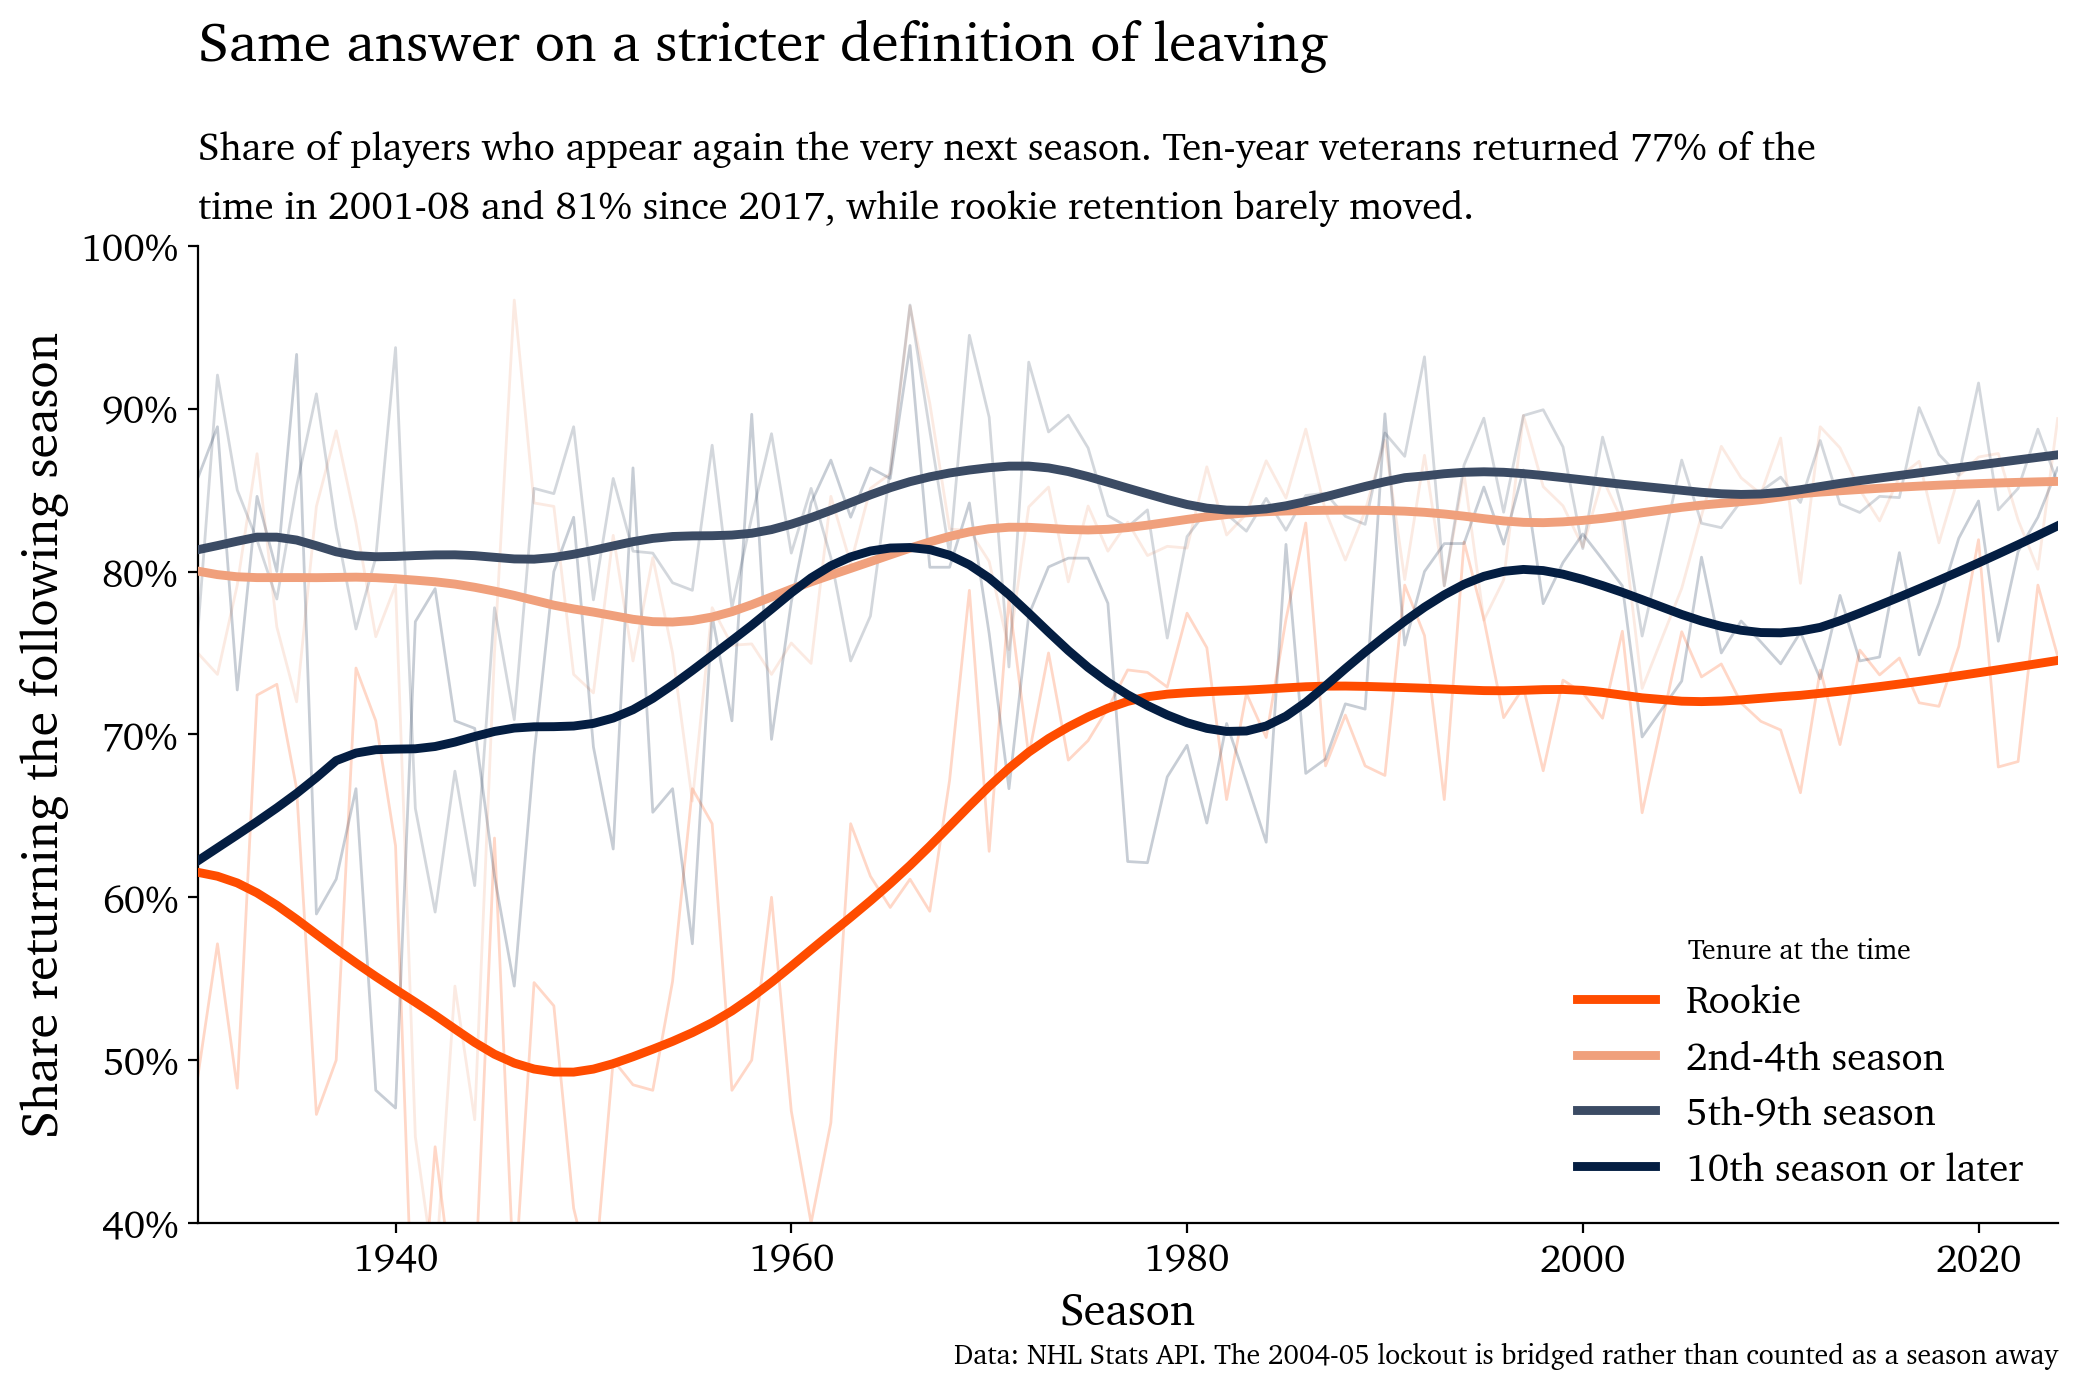

In [23]:
ret = rr.copy()
ret["grp4"] = pd.cut(ret.ten, [0, 1, 4, 9, 99], labels=["Rookie", "2nd-4th season", "5th-9th season",
                                                       "10th season or later"])
RET = ret.groupby(["yr", "grp4"], observed=True).back_next.mean().unstack()
GCOL = {"Rookie": ORANGE, "2nd-4th season": "#F0A07C", "5th-9th season": BLUE_PALE,
        "10th season or later": BLUE_DARK}
fig, ax = plt.subplots(figsize=(12, 7))
for g in GCOL:
    ax.plot(RET.index, RET[g], color=GCOL[g], lw=1.0, alpha=.22, zorder=2)
    s_ = lowess(RET[g].dropna().values, RET[g].dropna().index.values, frac=.25, return_sorted=True)
    ax.plot(s_[:, 0], s_[:, 1], color=GCOL[g], lw=3.2, zorder=3, label=g)
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share returning the following season", fontsize=FS_AXIS_LABEL)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v*100)}%"))
ax.set_xlim(1930, LAST - 1)
ax.set_ylim(0.4, 1.0)
hd_legend(ax, title="Tenure at the time", loc="lower right")
v00 = RET.loc[2001:2008, "10th season or later"].mean()
v20 = RET.loc[2017:LAST - 1, "10th season or later"].mean()
finish(fig, ax, "Same answer on a stricter definition of leaving",
       f"Share of players who appear again the very next season. Ten-year veterans returned {v00*100:.0f}% of the time in 2001-08 and {v20*100:.0f}% since 2017, while rookie retention barely moved.",
       "Data: NHL Stats API. The 2004-05 lockout is bridged rather than counted as a season away")

## How much of this is just arithmetic?

So there are two things going on: fewer rookies coming in, and established players staying longer. I wanted a rough sense of how much each one contributes, so I ran a simple simulation. Give every debut cohort the same survival curve, so careers can't change by construction, feed in the actual number of debuts each season, and see what veteran share comes out.

From 1991 to 2020, frozen careers plus the real intake track the actual veteran share to within about three points. The 1980s miss badly because the 1970s expansion cohorts washed out much faster than any "normal" career curve would predict. For 2025-26, the simulation lands at about 25%, and the league is actually at 31%.

So the intake alone gets you from the high teens to about a quarter of the league. **The last six points or so are what frozen careers can't produce**, and that's where the veterans staying longer comes in. Building the curve from 1980-2000 careers instead of 1950-2000 moves things by about a point.

This is a back-of-the-envelope decomposition, not a formal one. One pooled curve can't capture every cohort's quirks, and it ignores players who leave and come back.

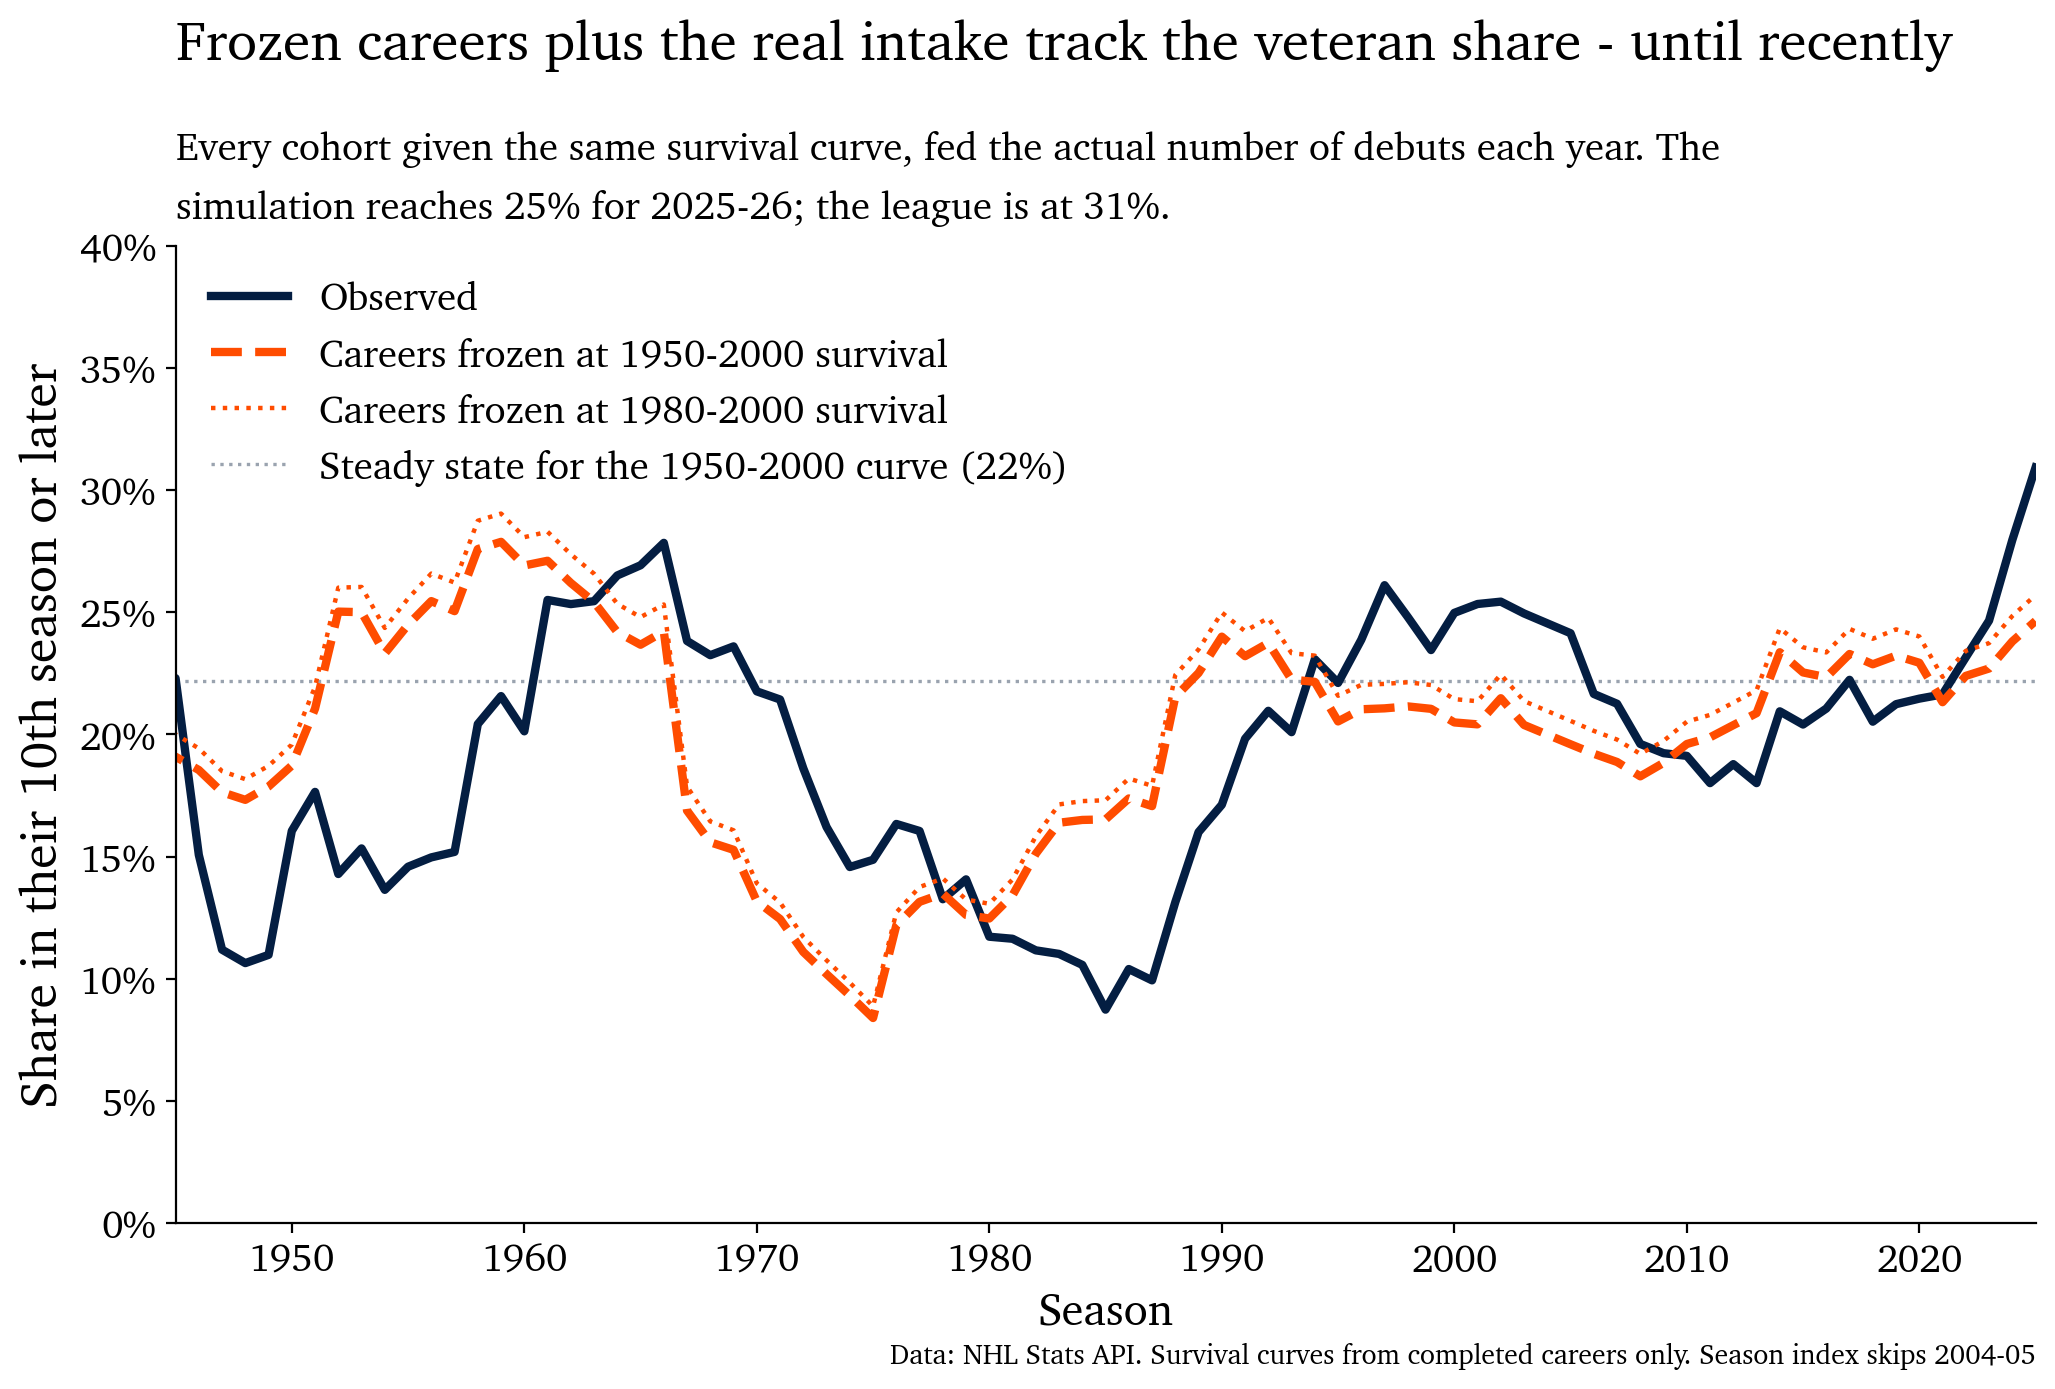

period,observed,simulated (1950-2000 curve),simulated (1980-2000 curve)
1967-1979,18.3%,12.6%,13.3%
1980-1990,11.9%,17.5%,18.3%
1991-2000,22.9%,21.7%,22.7%
2001-2010,22.3%,19.6%,20.6%
2011-2020,20.3%,22.2%,23.2%
2021-2025,25.7%,23.0%,24.0%
2025-26 alone,30.9%,24.6%,25.7%


In [24]:
done_pool = car[(~car.censored) & car.first_year.between(1950, 2000)]
sf_pool = SurvfuncRight(done_pool.span.values, np.ones(len(done_pool), int))
# a player who debuted t seasons ago is still in the league iff his span exceeds t,
# so S[t] = P(span > t) is the share of a cohort alive in its (t+1)th season
S = np.array([surv_at(sf_pool, t) for t in range(40)])
yrs = FL.index.tolist()
deb = FL.debuts.to_dict()


def simulate(S):
    out = {}
    for y in yrs:
        tot = vet = 0.0
        for cy in yrs:
            if cy > y:
                break
            t = season_order[y] - season_order[cy]
            if t < len(S):
                alive = deb[cy] * S[t]
                tot += alive
                vet += alive if t >= 9 else 0
        out[y] = vet / tot
    return pd.Series(out)


SIM = simulate(S)
eq = S[9:].sum() / S.sum()
alt_pool = car[(~car.censored) & car.first_year.between(1980, 2000)]
sf_alt = SurvfuncRight(alt_pool.span.values, np.ones(len(alt_pool), int))
S2 = np.array([surv_at(sf_alt, t) for t in range(40)])
SIM2 = simulate(S2)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(mixyr.index, mixyr.vet10, color=BLUE_DARK, lw=3, label="Observed")
ax.plot(SIM.index, SIM, color=ORANGE, lw=3, ls="--", label="Careers frozen at 1950-2000 survival")
ax.plot(SIM2.index, SIM2, color=ORANGE, lw=1.6, ls=":", label="Careers frozen at 1980-2000 survival")
ax.axhline(eq, color=GRAY, lw=1.2, ls=":", zorder=1, label=f"Steady state for the 1950-2000 curve ({eq:.0%})")
ax.set_xlim(1945, LAST)
ax.set_ylim(0, .4)
ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_xlabel("Season", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Share in their 10th season or later", fontsize=FS_AXIS_LABEL)
hd_legend(ax, loc="upper left")
finish(fig, ax, "Frozen careers plus the real intake track the veteran share - until recently",
       f"Every cohort given the same survival curve, fed the actual number of debuts each year. The simulation reaches {SIM.loc[LAST]:.0%} for {LAST}-{str(LAST+1)[-2:]}; the league is at {mixyr.vet10.loc[LAST]:.0%}.",
       "Data: NHL Stats API. Survival curves from completed careers only. Season index skips 2004-05")
rows = []
for lo, hi in [(1967, 1979), (1980, 1990), (1991, 2000), (2001, 2010), (2011, 2020), (2021, LAST)]:
    rows.append({"period": f"{lo}-{hi}", "observed": mixyr.vet10.loc[lo:hi].mean(),
                 "simulated (1950-2000 curve)": SIM.loc[lo:hi].mean(),
                 "simulated (1980-2000 curve)": SIM2.loc[lo:hi].mean()})
rows.append({"period": f"{LAST}-{str(LAST+1)[-2:]} alone", "observed": mixyr.vet10.loc[LAST],
             "simulated (1950-2000 curve)": SIM.loc[LAST], "simulated (1980-2000 curve)": SIM2.loc[LAST]})
table(pd.DataFrame(rows), {c: "{:.1%}" for c in ["observed", "simulated (1950-2000 curve)",
                                                  "simulated (1980-2000 curve)"]}, index=False)

# Does experience win?

## Game by game, 2010-11 to 2024-25

For every regular-season game since 2010-11 I know exactly who dressed, so each team's experience on a given night is the average prior NHL seasons of its lineup. Each game shows up twice, once from each team's side, so home ice cancels out in the pooled comparisons. Standard errors are clustered by team-season (or by game, for the logit).

There are three different kinds of variation here, and they're very different sizes. Teams differ from the league average by about 0.9 seasons (SD). A team's lineup on a given night differs from its own season average by about 0.5. And the gap between the two lineups in a game has an SD of 1.5.

Here's every model in one table.

In [25]:
ts_id = L.teamId.astype(str) + "_" + L.season.astype(str)


def cluster(y, X_, groups):
    return sm.OLS(y, sm.add_constant(X_)).fit(cov_type="cluster", cov_kwds={"groups": groups})


Bm = cluster(L.won, L[["between"]], ts_id)
Wm = cluster(L.won, L[["within"]], ts_id)
B, Bse, W, Wse = Bm.params["between"], Bm.bse["between"], Wm.params["within"], Wm.bse["within"]
dm = L[["won", "exp", "opp_exp", "home"]].sub(
    L.groupby(["teamId", "season"])[["won", "exp", "opp_exp", "home"]].transform("mean"))
assert abs(cluster(dm.won, dm[["exp"]], ts_id).params["exp"] - W) < 1e-6
fe_fit = cluster(dm.won, dm[["exp", "opp_exp", "home"]], ts_id)
ols_fit = cluster(L.won, L[["exp", "opp_exp", "home"]], ts_id)
gap_fit = sm.Logit(L.won, sm.add_constant(L[["gap"]])).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": L.game_id})

sd = pd.DataFrame({"component": ["between teams (team-season mean vs league)",
                                 "within a team-season (lineup vs own norm)",
                                 "gap between the two lineups in a game"],
                   "SD (seasons)": [L.drop_duplicates(["teamId", "season"]).between.std(),
                                    L.within.std(), L.gap.std()]})
table(sd, {"SD (seasons)": "{:.2f}"}, index=False, caption=f"{L.game_id.nunique():,} games, "
      f"{len(L):,} team-games, {L.groupby(['teamId', 'season']).ngroups} team-seasons")
res = pd.DataFrame([
    ("Logit on the experience gap (per season)", gap_fit.params["gap"], gap_fit.bse["gap"], "log-odds; clustered by game"),
    ("  as win probability near 50/50", gap_fit.params["gap"] / 4, gap_fit.bse["gap"] / 4, "divide-by-4 rule"),
    ("Between teams, unadjusted", B, Bse, "LPM; clustered by team-season"),
    ("Between teams, + opponent exp. and home ice", ols_fit.params["exp"], ols_fit.bse["exp"], "LPM"),
    ("Within a team-season", W, Wse, "LPM with team-season FE"),
    ("Within, + opponent exp. and home ice", fe_fit.params["exp"], fe_fit.bse["exp"], "LPM with team-season FE"),
    ("  opponent's experience (FE model)", fe_fit.params["opp_exp"], fe_fit.bse["opp_exp"], ""),
    ("  home ice (FE model)", fe_fit.params["home"], fe_fit.bse["home"], ""),
], columns=["estimate", "coef", "SE", "notes"])
res["95% CI"] = [f"[{c - 1.96*s:+.4f}, {c + 1.96*s:+.4f}]" for c, s in zip(res.coef, res.SE)]
table(res, {"coef": "{:+.4f}", "SE": "{:.4f}"}, index=False)

component,SD (seasons)
between teams (team-season mean vs league),0.93
within a team-season (lineup vs own norm),0.54
gap between the two lineups in a game,1.53


estimate,coef,SE,notes,95% CI
Logit on the experience gap (per season),+0.0927,0.0099,log-odds; clustered by game,"[+0.0734, +0.1121]"
as win probability near 50/50,+0.0232,0.0025,divide-by-4 rule,"[+0.0184, +0.0280]"
"Between teams, unadjusted",+0.0313,0.0047,LPM; clustered by team-season,"[+0.0220, +0.0405]"
"Between teams, + opponent exp. and home ice",+0.0228,0.0036,LPM,"[+0.0157, +0.0299]"
Within a team-season,-0.0003,0.0054,LPM with team-season FE,"[-0.0108, +0.0102]"
"Within, + opponent exp. and home ice",+0.0003,0.0053,LPM with team-season FE,"[-0.0102, +0.0107]"
opponent's experience (FE model),-0.0223,0.0023,,"[-0.0268, -0.0177]"
home ice (FE model),+0.0846,0.0051,,"[+0.0746, +0.0945]"


The figure from the post: win rate by the experience gap between the two lineups, in half-season bins, with the logistic fit. Each extra season of experience over your opponent is worth about 2.3 points of win probability.

For a sense of scale, here's what the model predicts across the range of gaps, and how often each size of gap actually happens. A one-season gap, which shows up in about half of all games, is worth roughly 52-48. A three-season gap is worth about 57-43, but only about one game in twenty has a gap that big.

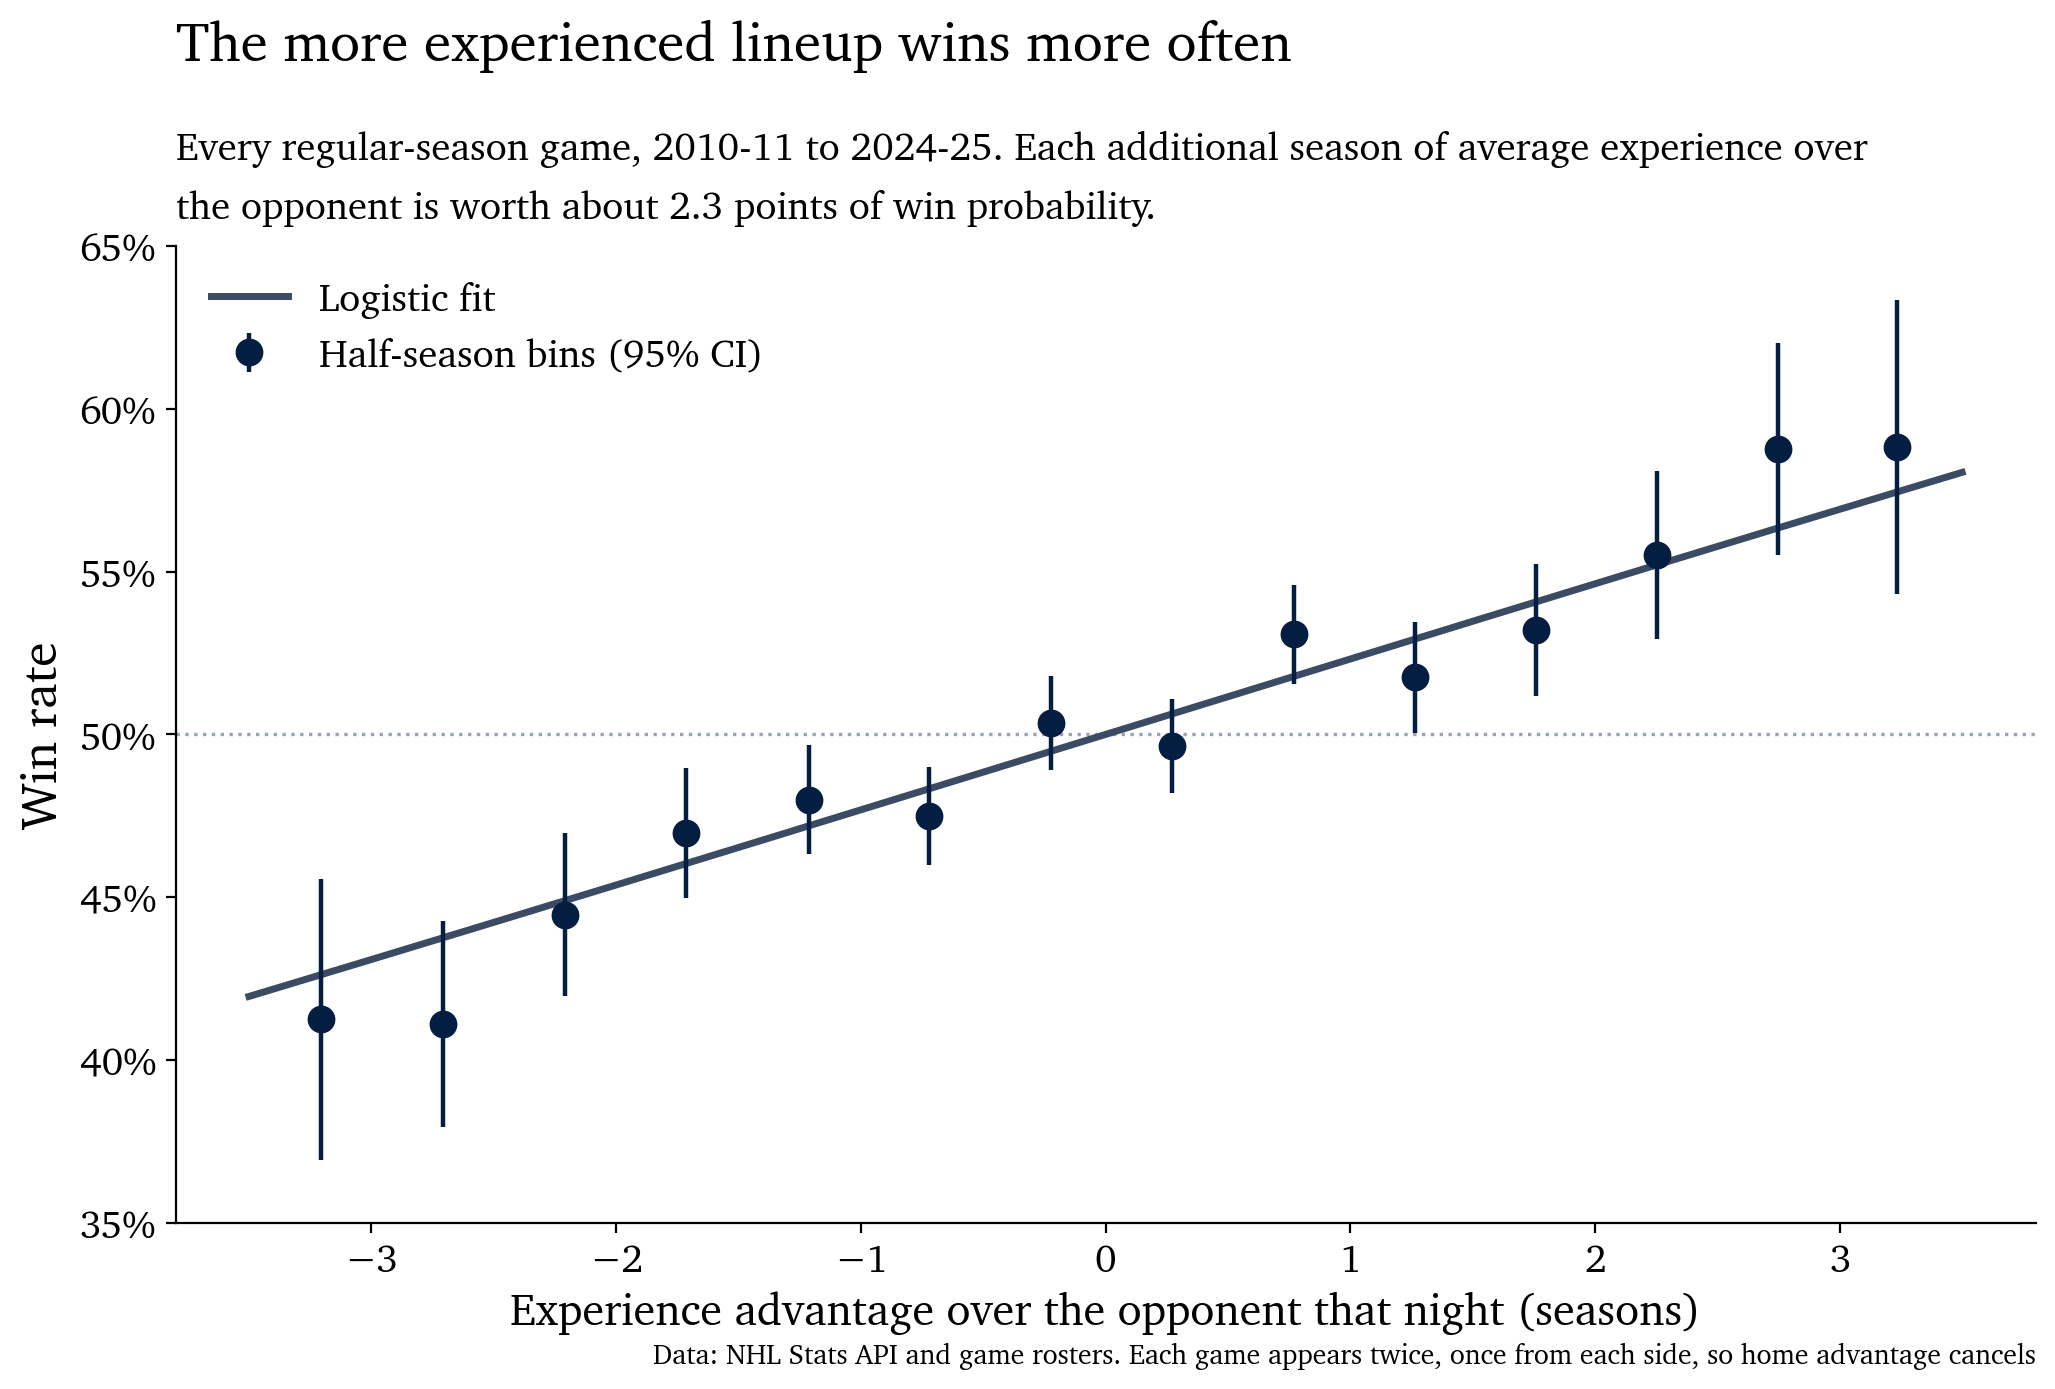

experience gap (seasons),model win probability,share of team-games at least this far apart
-3,43.1%,5.4%
-2,45.4%,19.1%
-1,47.7%,51.8%
+0,50.0%,100.0%
+1,52.3%,51.8%
+2,54.6%,19.1%
+3,56.9%,5.4%


In [26]:
def gbin(df, col, edges=None, q=None):
    b_ = pd.qcut(df[col], q) if q else pd.cut(df[col], edges)
    o = df.groupby(b_, observed=True).agg(x=(col, "mean"), p=("won", "mean"), n=("won", "size"))
    o["se"] = np.sqrt(o.p * (1 - o.p) / o.n)
    return o.reset_index(drop=True)


bins = gbin(L, "gap", edges=np.arange(-3.5, 3.51, 0.5))
fig, ax = plt.subplots(figsize=(12, 7))
ax.axhline(0.5, color=GRAY, ls=":", lw=1.2, zorder=1)
grid = np.linspace(-3.5, 3.5, 200)
ax.plot(grid, gap_fit.predict(sm.add_constant(pd.DataFrame({"gap": grid}))), color=BLUE_PALE, lw=2.5,
        zorder=2, label="Logistic fit")
ax.errorbar(bins.x, bins.p, yerr=1.96 * bins.se, fmt="o", ms=9, lw=0, elinewidth=1.6, color=BLUE_DARK,
            zorder=3, label="Half-season bins (95% CI)")
ax.set_xlabel("Experience advantage over the opponent that night (seasons)", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Win rate", fontsize=FS_AXIS_LABEL)
ax.set_xlim(-3.8, 3.8)
ax.set_ylim(0.35, 0.65)
ax.yaxis.set_major_formatter(FuncFormatter(pct))
hd_legend(ax, loc="upper left")
finish(fig, ax, "The more experienced lineup wins more often",
       f"Every regular-season game, 2010-11 to 2024-25. Each additional season of average experience over the opponent is worth about {gap_fit.params['gap']/4*100:.1f} points of win probability.",
       "Data: NHL Stats API and game rosters. Each game appears twice, once from each side, so home advantage cancels")

pred = pd.DataFrame({"experience gap (seasons)": [-3, -2, -1, 0, 1, 2, 3]})
pred["model win probability"] = gap_fit.predict(sm.add_constant(pred.rename(columns={"experience gap (seasons)": "gap"})))
ag = L.gap.abs()
pred["share of team-games at least this far apart"] = [(ag >= abs(g)).mean() if g else 1.0
                                                       for g in pred["experience gap (seasons)"]]
table(pred, {"experience gap (seasons)": "{:+d}", "model win probability": "{:.1%}",
             "share of team-games at least this far apart": "{:.1%}"}, index=False)

## Is it the experience, or the team?

This is the question I kept coming back to, and I think it's the most interesting figure in the notebook. Good players last longer, so good teams end up experienced almost by default. Is experience actually *doing* anything, or is it just a marker of a good roster?

One way to get at that is to split the effect in two:

- **Between teams (left):** teams more experienced than the league average win more, about 3 points of win probability per season.
- **Within one team (right):** the same team, on nights when injuries, call-ups and rest leave it with a more experienced lineup than its own season average. Here the effect is **zero**: -0.03 points, with a 95% interval of about -1.1 to +1.0.

So when a team is experienced, it wins. When the *same* team happens to dress a more experienced lineup, it doesn't win any more often. My read is that **experience marks a good roster, but I can't show that it acts on the game.**

Two caveats. The within-team test is about nightly lineup changes, not roster building, so it doesn't say roster construction is irrelevant. And it's conservative: when an injured veteran is replaced by a call-up, the lineup usually gets both less experienced *and* worse, and even that doesn't move the needle.

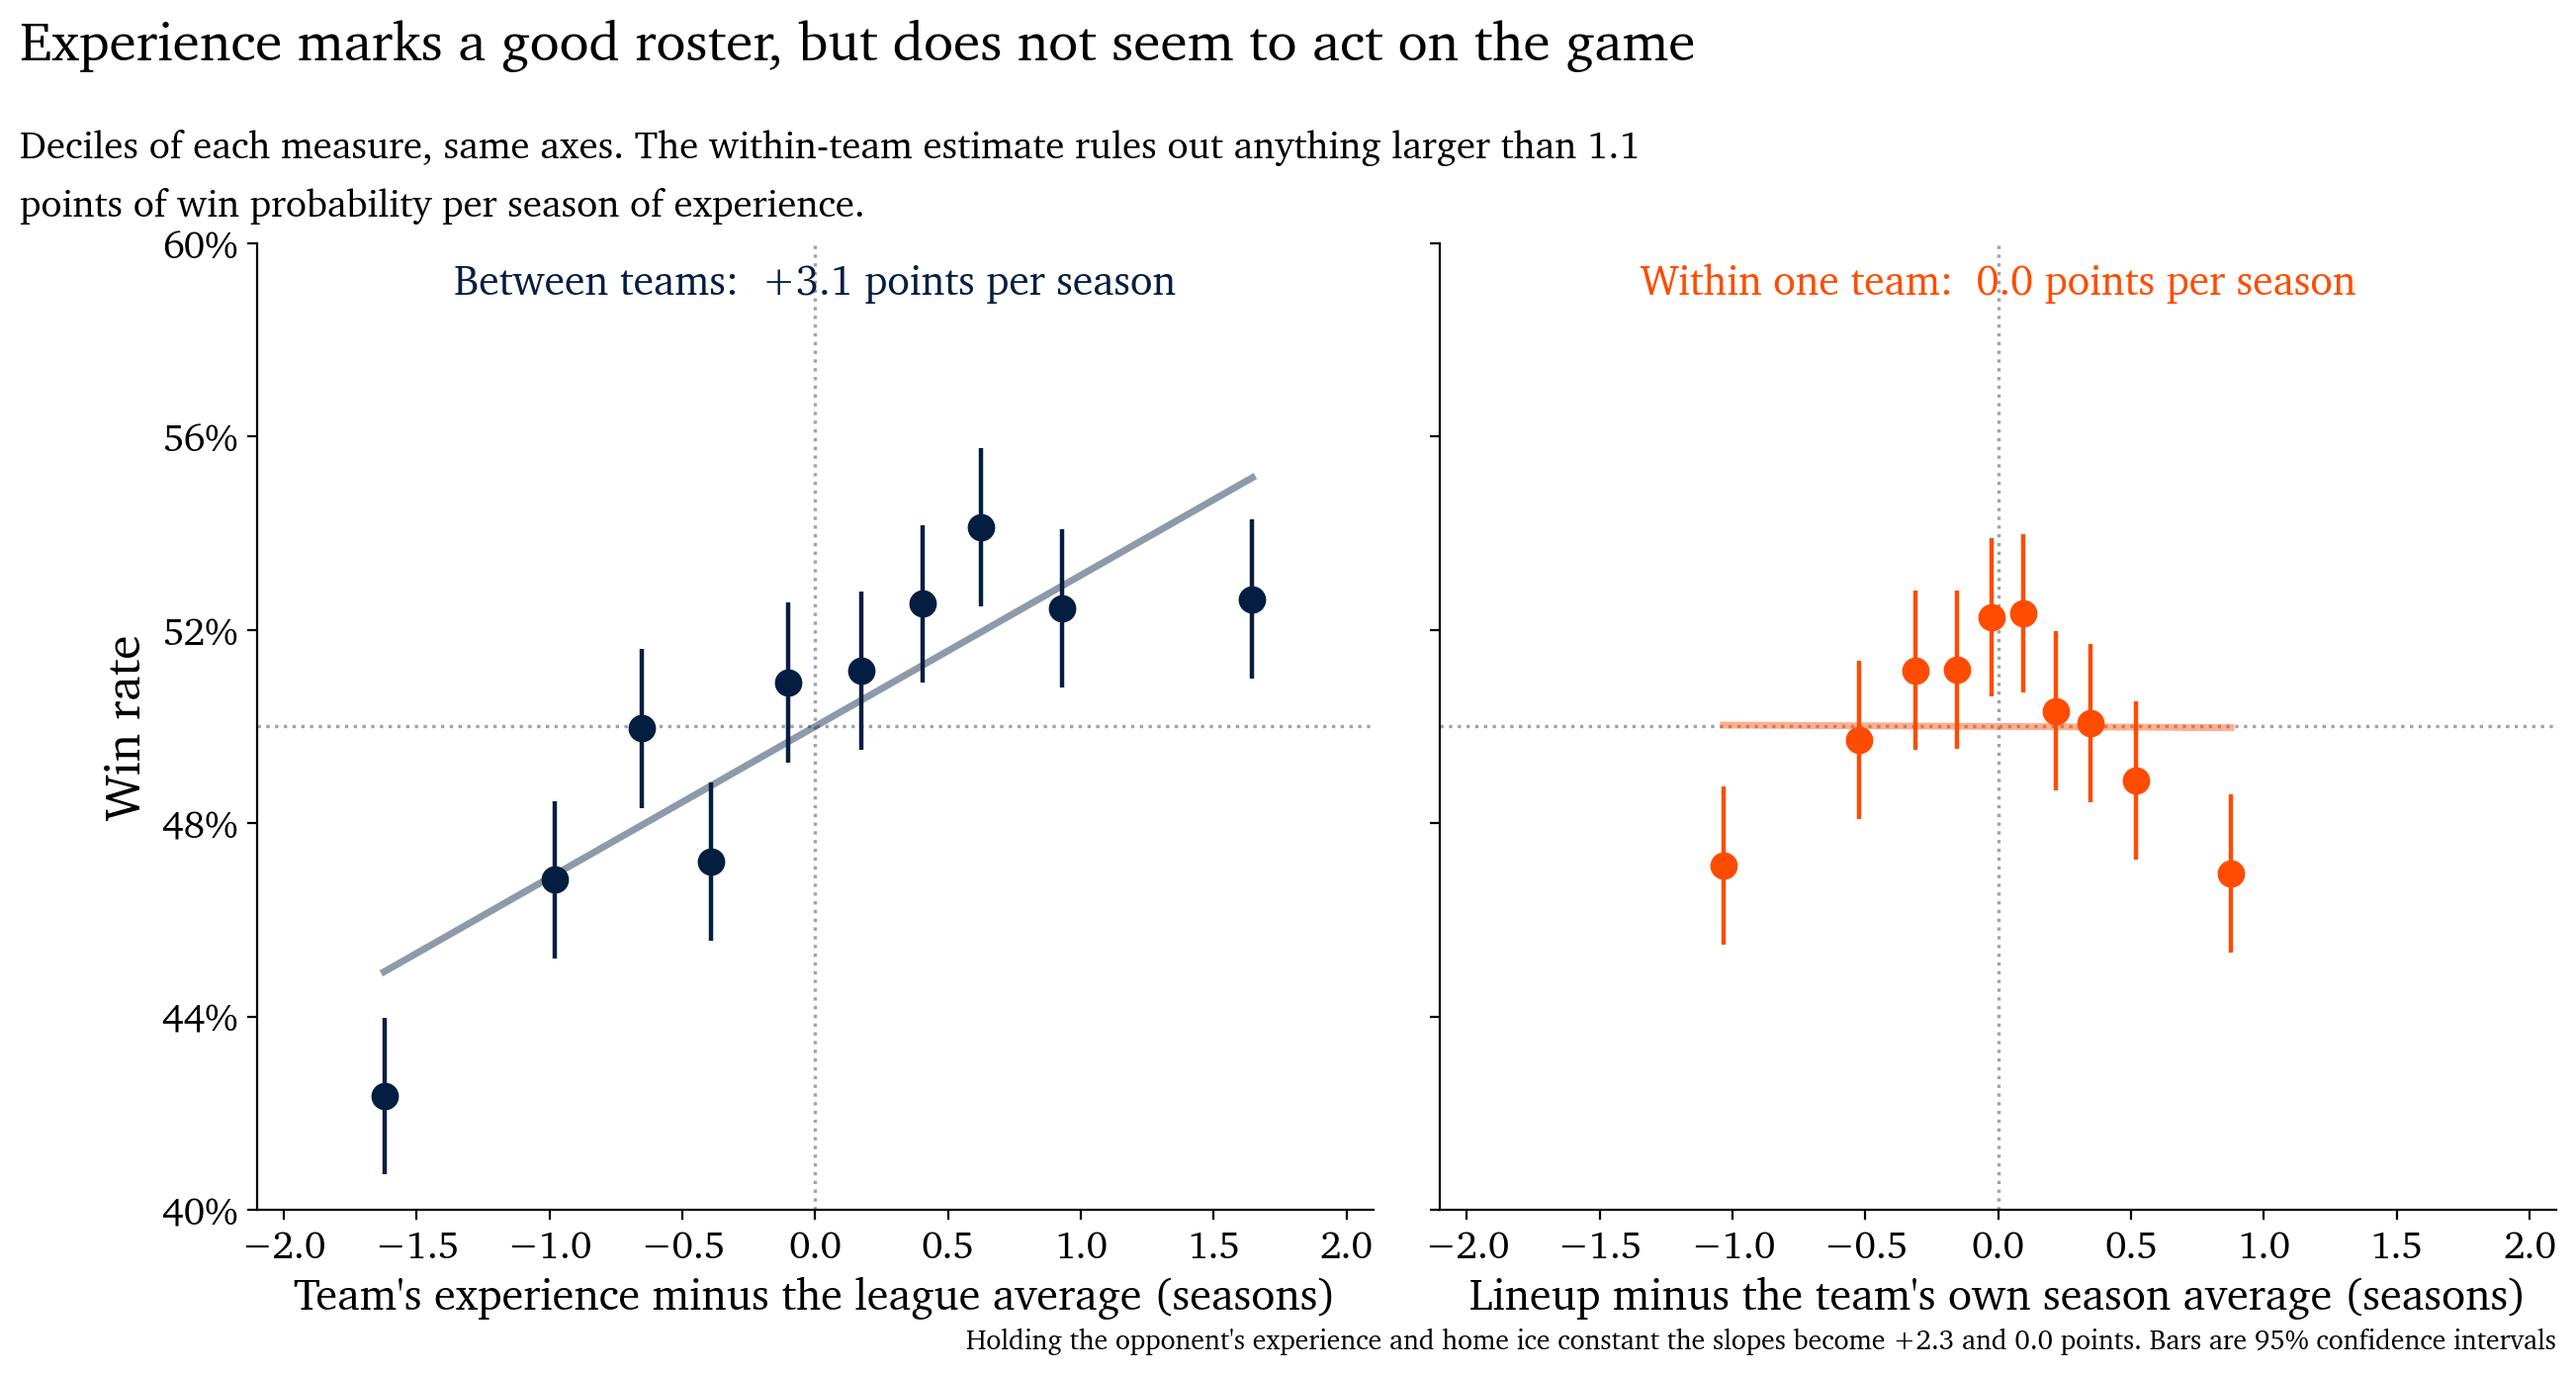

In [27]:
def signed(pp):
    return "0.0" if abs(pp) < 0.05 else f"{pp:+.1f}"


bw, wi = gbin(L, "between", q=10), gbin(L, "within", q=10)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7), sharey=True, gridspec_kw={"wspace": 0.06})
for ax, b_, col, coef, head, xlab in (
        (axL, bw, BLUE_DARK, B, "Between teams", "Team's experience minus the league average (seasons)"),
        (axR, wi, ORANGE, W, "Within one team", "Lineup minus the team's own season average (seasons)")):
    ax.axhline(0.5, color=GRAY, ls=":", lw=1.2, zorder=1)
    ax.axvline(0, color=GRAY, ls=":", lw=1.2, zorder=1)
    xs = np.linspace(b_.x.min(), b_.x.max(), 50)
    ax.plot(xs, 0.5 + coef * xs, color=col, lw=2.5, alpha=.45, zorder=2)
    ax.errorbar(b_.x, b_.p, yerr=1.96 * b_.se, fmt="o", ms=9, lw=0, elinewidth=1.6, color=col, zorder=3)
    ax.text(0.5, 0.98, f"{head}:  {signed(coef*100)} points per season", transform=ax.transAxes,
            ha="center", va="top", fontsize=15, weight="bold", color=col)
    ax.set_xlim(-2.1, 2.1)
    ax.set_xlabel(xlab, fontsize=FS_XAXIS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    sns.despine(ax=ax)
    ax.grid(False)
axL.set_ylim(0.40, 0.60)
axL.set_yticks(np.arange(0.40, 0.601, 0.04))
axL.yaxis.set_major_formatter(FuncFormatter(pct))
axL.set_ylabel("Win rate", fontsize=FS_AXIS_LABEL)
finish(fig, axL, "Experience marks a good roster, but does not seem to act on the game",
       f"Deciles of each measure, same axes. The within-team estimate rules out anything larger than {abs(W - 1.96*Wse)*100:.1f} points of win probability per season of experience.",
       f"Holding the opponent's experience and home ice constant the slopes become {signed(ols_fit.params['exp']*100)} and {signed(fe_fit.params['exp']*100)} points. Bars are 95% confidence intervals",
       title_x=0.045)

## Season by season, 1917 to today

The game data only goes back to 2010, but standings go back to the start. Does a team's games-weighted experience predict its points percentage? Here it is four ways, each holding more constant:

- **Raw:** every team-season pooled together.
- **Within the season:** teams compared only to the other teams that season, which takes the era out of it.
- **Within the franchise:** also holds constant everything permanent about a club.
- **Year on year:** the plainest version of the question. When a team got more experienced than it was last season, did it get better?

The raw estimate is actually the smallest. League experience rose over the century while points percentage is centred on .500 by design, so pooling across eras waters the relationship down. Comparing within a season brings it back to about 3 points per season of experience. The year-on-year version keeps about 40% of that.

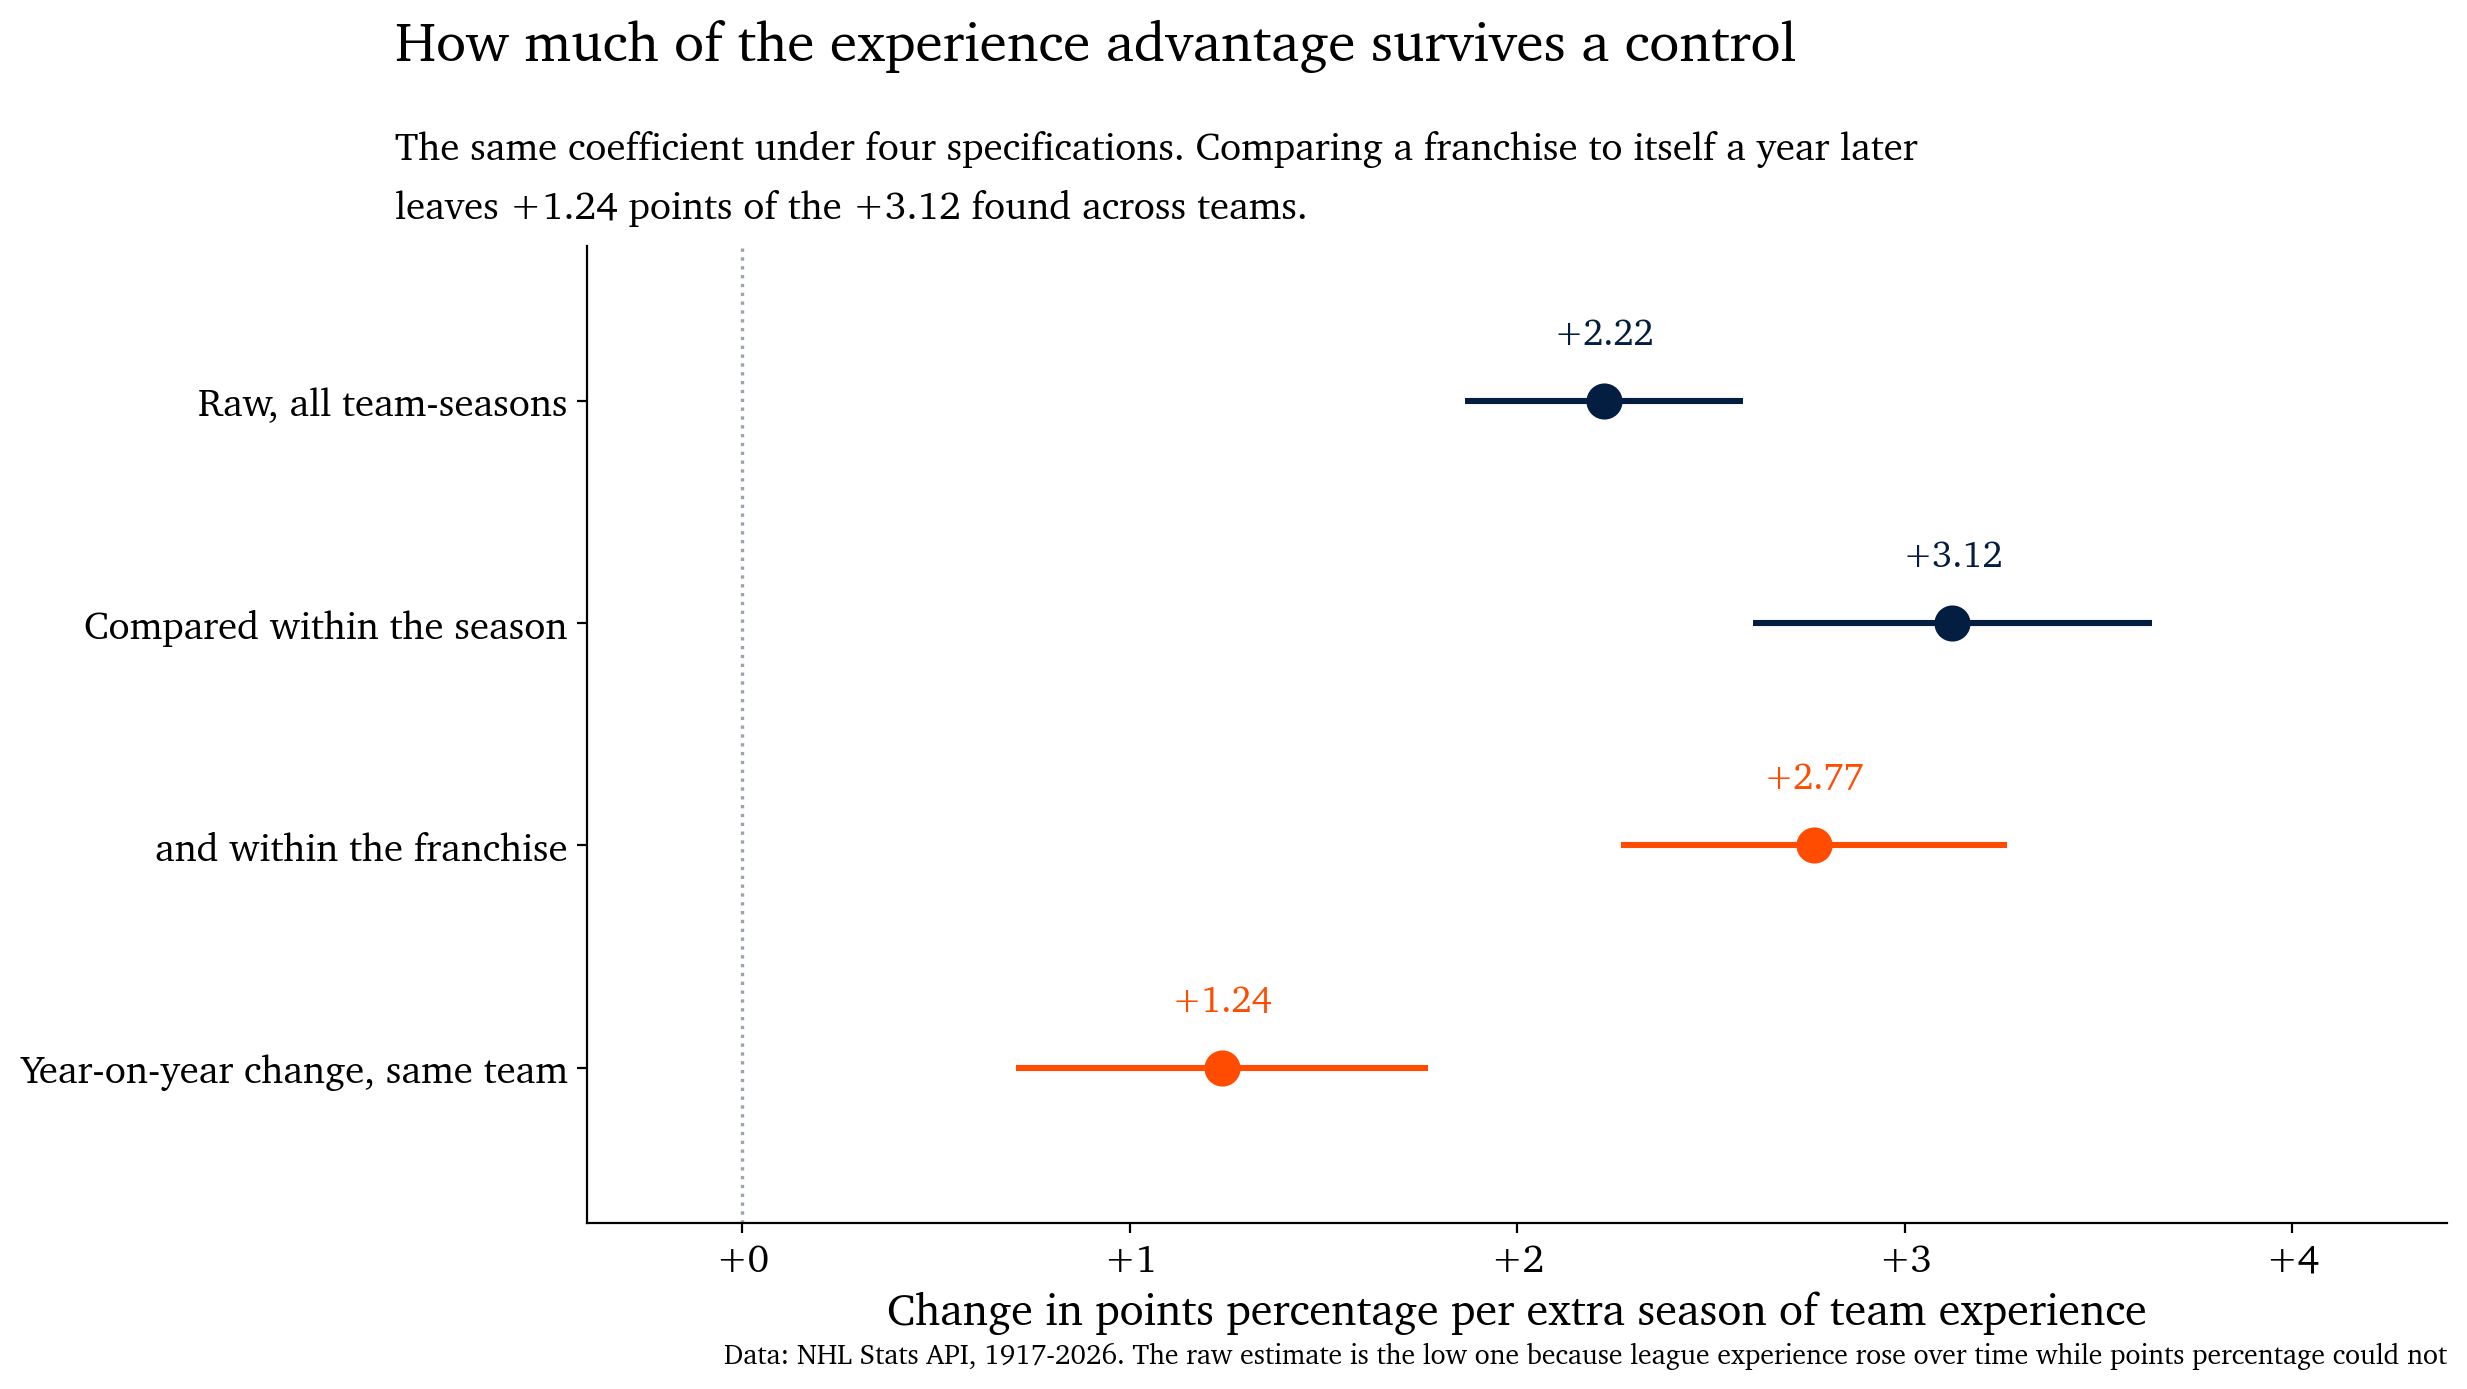

specification,points % per season,SE,n
"Raw, all team-seasons",+2.22,0.18,"1,755"
Compared within the season,+3.12,0.26,"1,755"
and within the franchise,+2.77,0.25,"1,755"
"Year-on-year change, same team",+1.24,0.27,"1,663"


within-season correlation of experience and points %: r = +0.292


In [28]:
d = tse.copy()


def fit(y, X_, groups):
    return sm.OLS(y, sm.add_constant(X_)).fit(cov_type="cluster", cov_kwds={"groups": groups})


seas_d = pd.get_dummies(d.season, prefix="s", drop_first=True).astype(float)
fran_d = pd.get_dummies(d.teamId, prefix="t", drop_first=True).astype(float)
specs = {"Raw, all team-seasons": fit(d.point_pct, d[["exp"]], d.season),
         "Compared within the season": fit(d.point_pct, pd.concat([d[["exp"]], seas_d], axis=1), d.season),
         "and within the franchise": fit(d.point_pct, pd.concat([d[["exp"]], seas_d, fran_d], axis=1), d.season)}
d = d.sort_values(["teamId", "yr"])
lag = d.groupby("teamId")[["yr", "exp", "point_pct"]].shift(1)
fd = (d.assign(d_exp=d.exp - lag.exp, d_pp=d.point_pct - lag.point_pct, gap_yr=d.yr - lag.yr)
       .query("gap_yr == 1").dropna(subset=["d_exp", "d_pp"]))
specs["Year-on-year change, same team"] = fit(fd.d_pp, fd[["d_exp"]], fd.season)
spec = pd.DataFrame([{"specification": k, "coef": m.params["d_exp" if "d_exp" in m.params else "exp"],
                      "se": m.bse["d_exp" if "d_exp" in m.params else "exp"], "n": int(m.nobs)}
                     for k, m in specs.items()])

fig, ax = plt.subplots(figsize=(12, 7))
yy = np.arange(len(spec))[::-1]
ax.axvline(0, color=GRAY, ls=":", lw=1.2, zorder=1)
for yi, r, col in zip(yy, spec.itertuples(), [BLUE_DARK, BLUE_DARK, ORANGE, ORANGE]):
    ax.errorbar(r.coef, yi, xerr=1.96 * r.se, fmt="o", ms=12, lw=0, elinewidth=2.2, color=col, zorder=3)
    ax.text(r.coef, yi + 0.22, f"{r.coef*100:+.2f}", ha="center", va="bottom", fontsize=13, color=col)
ax.set_yticks(yy)
ax.set_yticklabels(spec.specification)
ax.set_ylim(-0.7, len(spec) - 0.3)
ax.set_xlabel("Change in points percentage per extra season of team experience", fontsize=FS_XAXIS_LABEL)
hi_ = np.ceil((spec.coef + 1.96 * spec.se).max() * 100)
ax.set_xticks(np.arange(0, (hi_ + 1) / 100, 0.01))
ax.set_xlim(-0.004, (hi_ + 0.4) / 100)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:+.0f}"))
finish(fig, ax, "How much of the experience advantage survives a control",
       f"The same coefficient under four specifications. Comparing a franchise to itself a year later leaves {spec.coef.iloc[3]*100:+.2f} points of the {spec.coef.iloc[1]*100:+.2f} found across teams.",
       "Data: NHL Stats API, 1917-2026. The raw estimate is the low one because league experience rose over time while points percentage could not",
       title_x=0.045)
spec_t = spec.assign(coef=spec.coef * 100, se=spec.se * 100)
table(spec_t.rename(columns={"coef": "points % per season", "se": "SE"}),
      {"points % per season": "{:+.2f}", "SE": "{:.2f}", "n": "{:,}"}, index=False)
print(f"within-season correlation of experience and points %: r = {tse.exp_dev.corr(tse.point_pct_dev):+.3f}")

## Has it always been this way?

Not at all. Decade by decade, the relationship is all over the place before 1960, and in the 1930s it actually runs the other way: more experienced teams did *worse*. That holds up (and gets stronger) when you drop expansion franchises, which tend to be young and bad at the same time for reasons that have nothing to do with experience. From the 1960s on, it's positive in every decade. "Experience wins" is a modern pattern, not a law of hockey.

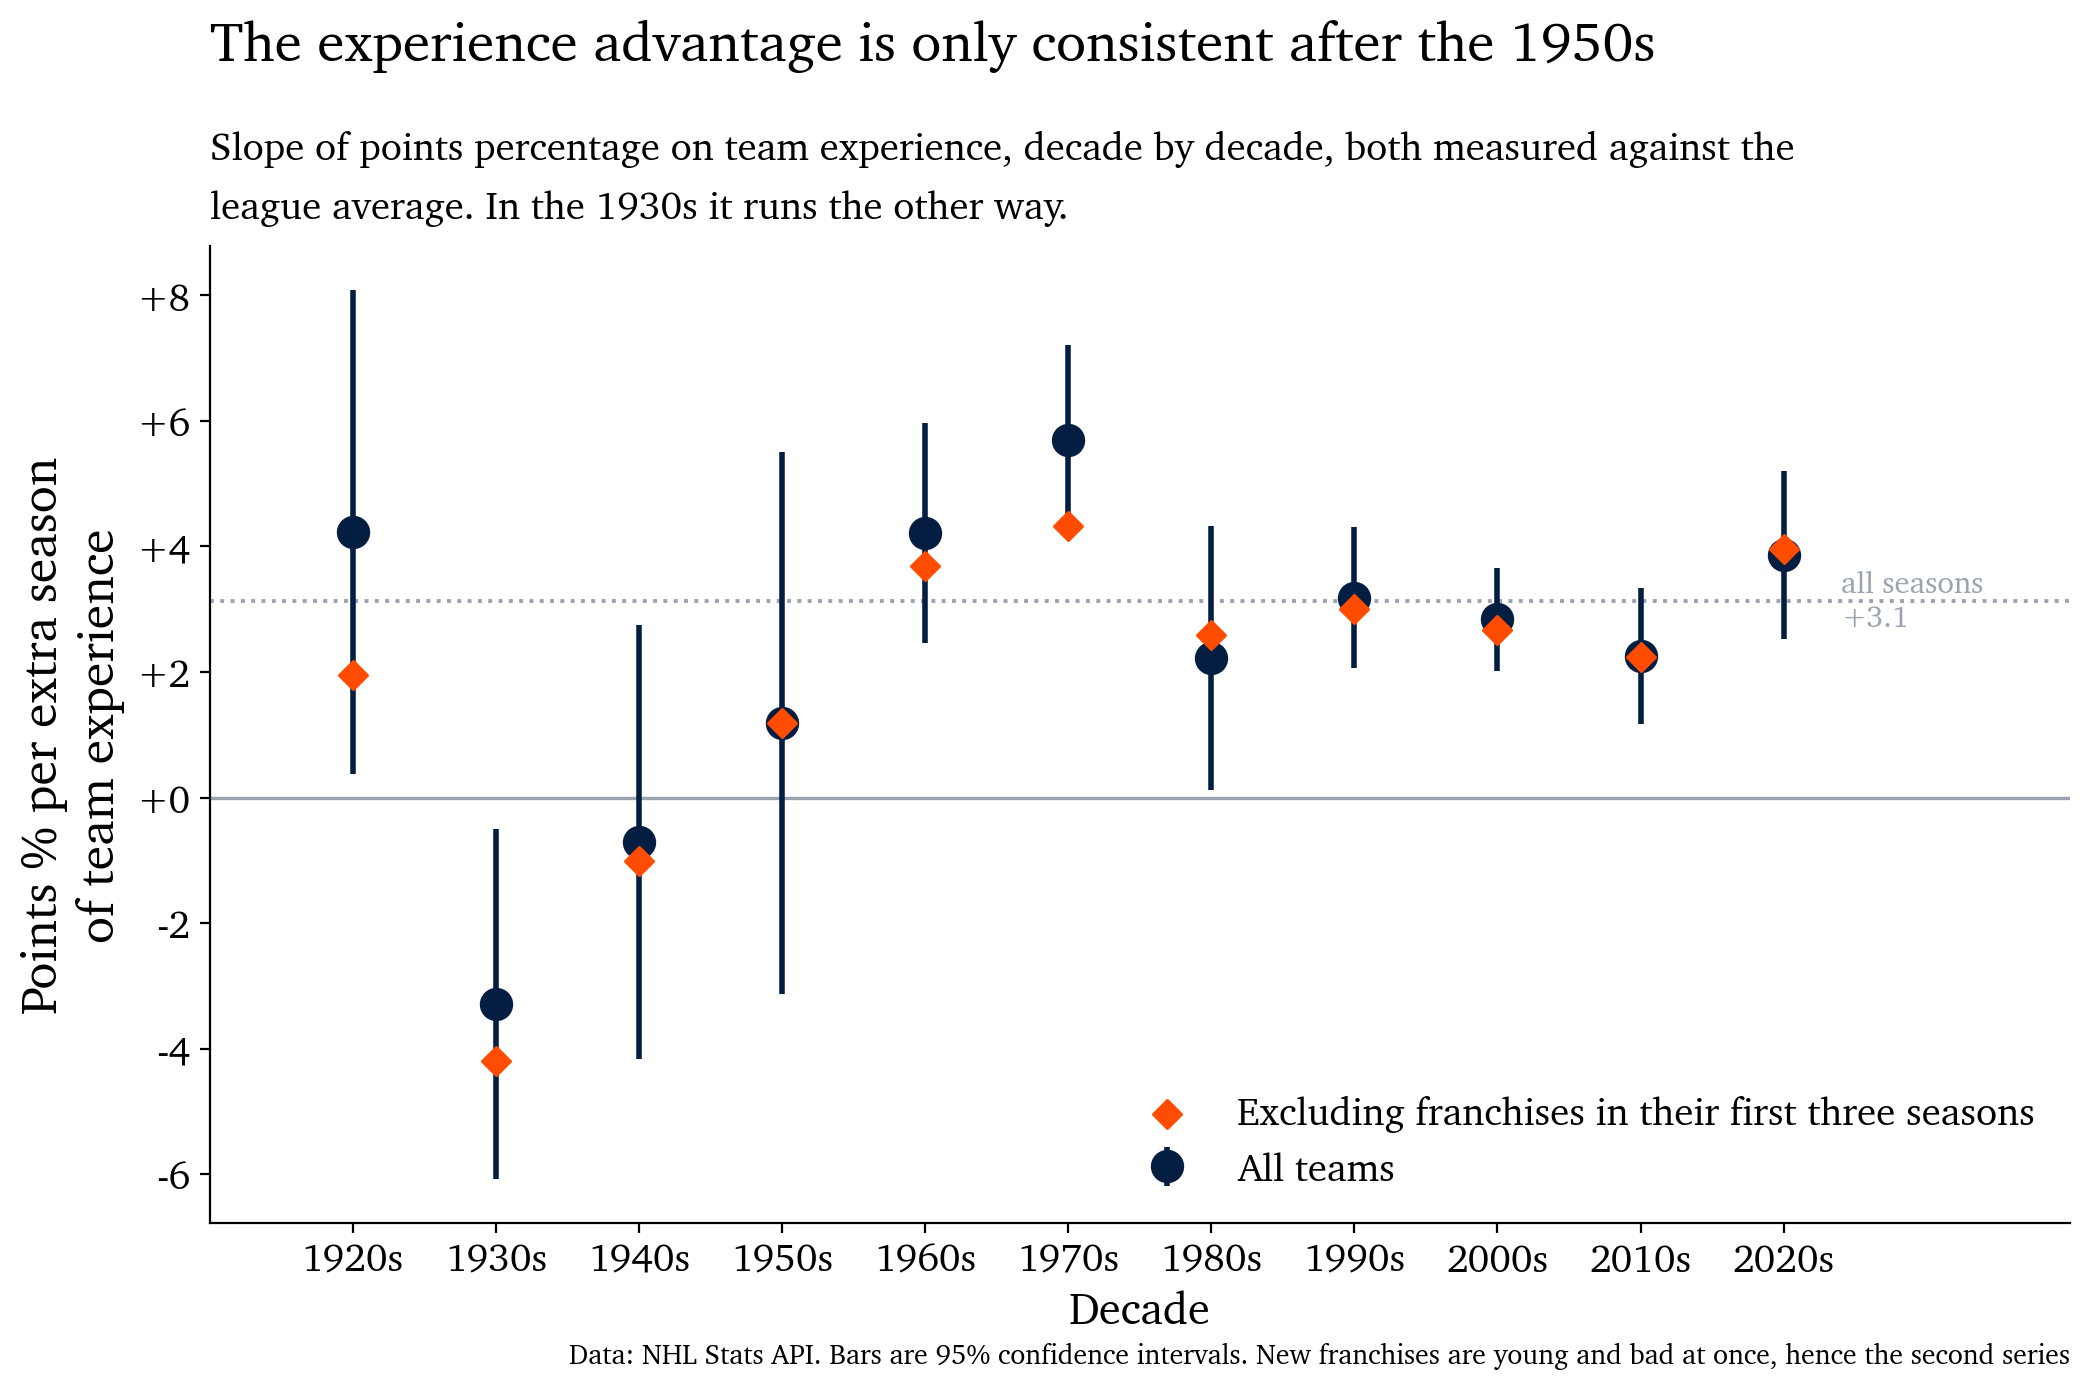

decade,slope,se,p-value,slope excl. new franchises,n
1920s,+4.23,1.97,0.035,+1.96,69
1930s,-3.28,1.42,0.024,-4.20,83
1940s,-0.71,1.77,0.689,-1.00,62
1950s,+1.19,2.20,0.592,+1.19,60
1960s,+4.21,0.89,0.000,+3.69,78
1970s,+5.70,0.77,0.000,+4.32,170
1980s,+2.23,1.07,0.039,+2.59,210
1990s,+3.19,0.57,0.000,+3.00,252
2000s,+2.84,0.42,0.000,+2.67,270
2010s,+2.25,0.55,0.000,+2.24,303


In [29]:
d["decade"] = (d.yr // 10) * 10
dec = []
for dc, g in d.groupby("decade"):
    if len(g) < 20:
        continue
    m = sm.OLS(g.point_pct_dev, sm.add_constant(g[["exp_dev"]])).fit()
    x_ = g[g.franchise_age >= 3]
    mx = sm.OLS(x_.point_pct_dev, sm.add_constant(x_[["exp_dev"]])).fit()
    dec.append({"decade": dc, "b": m.params.exp_dev, "se": m.bse.exp_dev, "p": m.pvalues.exp_dev,
                "b_est": mx.params.exp_dev, "n": len(g)})
dec = pd.DataFrame(dec)
pooled = specs["Compared within the season"].params["exp"]
fig, ax = plt.subplots(figsize=(12, 7))
ax.axhline(0, color=GRAY, ls="-", lw=1.2, zorder=1)
ax.axhline(pooled, color=GRAY, ls=":", lw=1.4, zorder=1)
ax.text(2029, pooled, f"all seasons\n{pooled*100:+.1f}", fontsize=11, color=GRAY, va="center", ha="left",
        style="italic")
ax.errorbar(dec.decade + 5, dec.b, yerr=1.96 * dec.se, fmt="o", ms=11, lw=0, elinewidth=2.0,
            color=BLUE_DARK, zorder=3, label="All teams")
ax.scatter(dec.decade + 5, dec.b_est, s=52, marker="D", color=ORANGE, zorder=4,
           label="Excluding franchises in their first three seasons")
ax.set_xlabel("Decade", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Points % per extra season\nof team experience", fontsize=FS_AXIS_LABEL)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:+.0f}"))
ax.set_xlim(1915, 2045)
ax.set_xticks(dec.decade + 5)
ax.set_xticklabels([f"{x}s" for x in dec.decade])
hd_legend(ax, loc="lower right")
finish(fig, ax, "The experience advantage is only consistent after the 1950s",
       "Slope of points percentage on team experience, decade by decade, both measured against the league average. In the 1930s it runs the other way.",
       "Data: NHL Stats API. Bars are 95% confidence intervals. New franchises are young and bad at once, hence the second series")
dec_t = dec.assign(decade=dec.decade.map(lambda x: f"{x}s"), b=dec.b * 100, se=dec.se * 100,
                   b_est=dec.b_est * 100)
table(dec_t.rename(columns={"b": "slope", "b_est": "slope excl. new franchises", "p": "p-value"}),
      {"slope": "{:+.2f}", "se": "{:.2f}", "p-value": "{:.3f}", "slope excl. new franchises": "{:+.2f}",
       "n": "{:,}"}, index=False)

## Rookies and veterans on the roster

The team average hides the mix, so here are the two ends of the roster separately. Teams that lean on rookies lose, and by a lot: about 5 points of points percentage for every ten extra points of rookie share. Leaning on long-time veterans (11th season or later) helps, but point for point the rookie penalty is about 2.6 times the veteran bonus. And the *spread* of experience on a roster, holding the average fixed, doesn't matter at all (last row).

The arrow almost certainly runs both ways on that rookie effect: rebuilding teams play rookies *because* they're rebuilding.

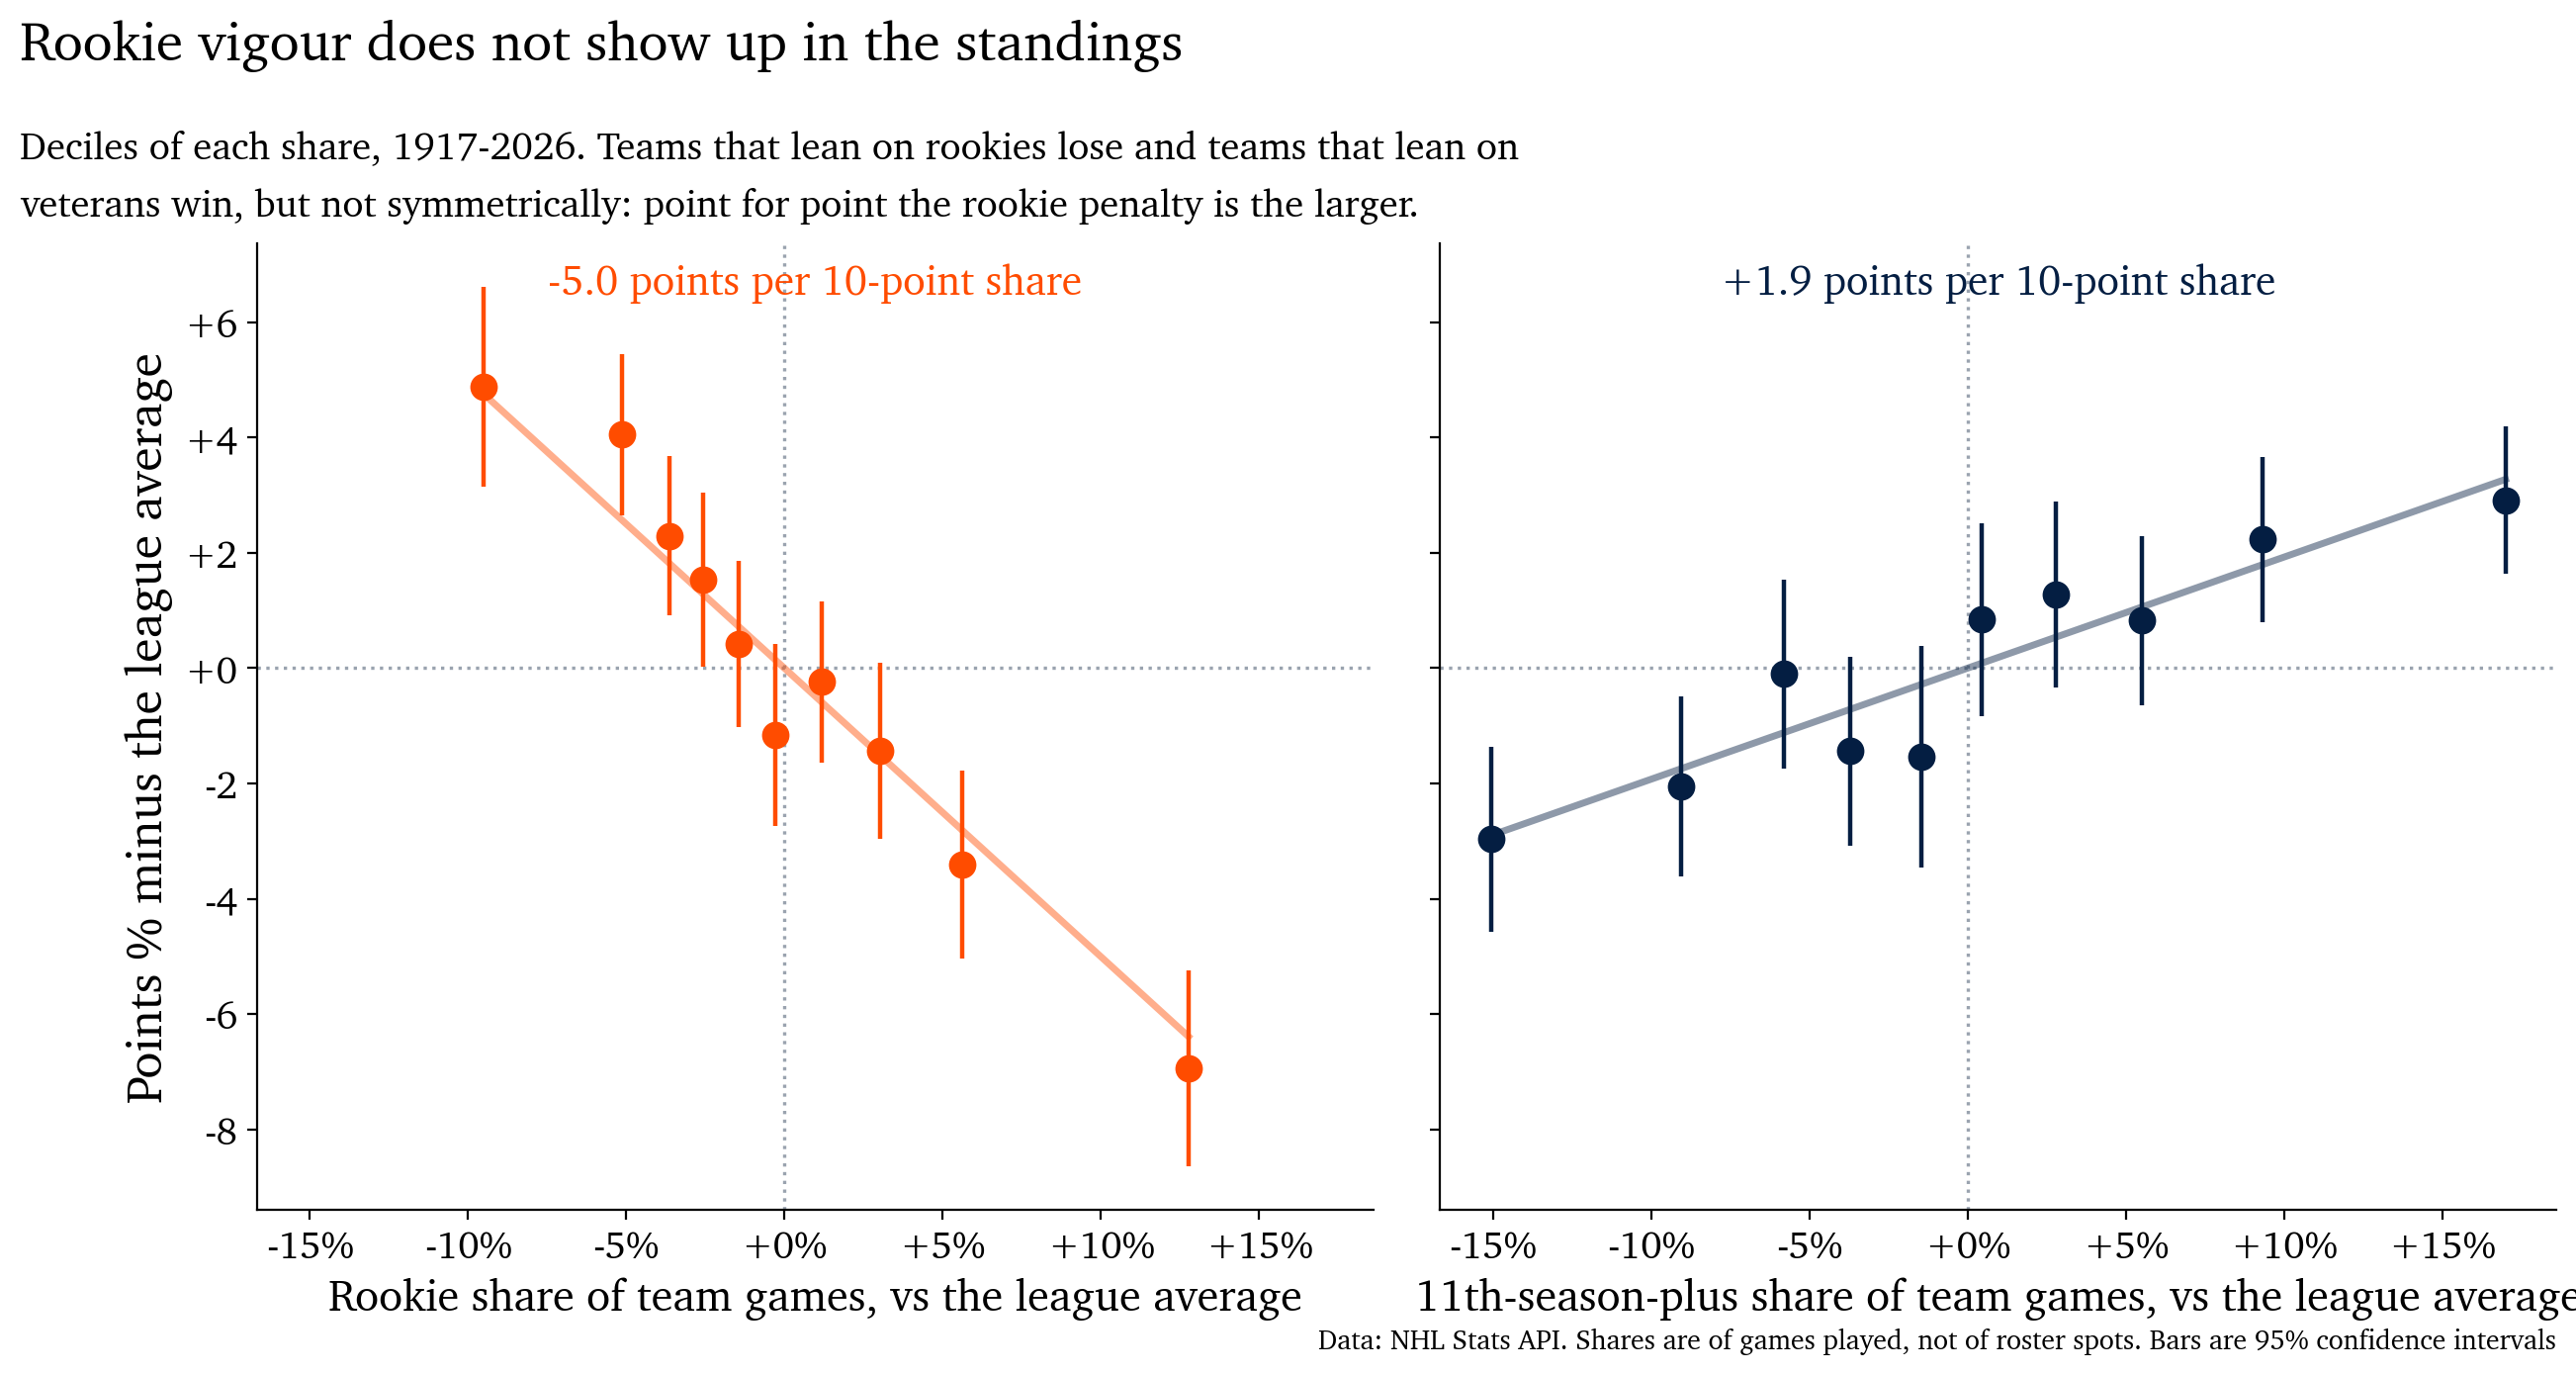

measure,coefficient,t
Rookie share of team games,-5.003,-7.2
11th-season-plus share of team games,+1.926,+7.3
Spread of experience (games-weighted SD),+0.005,+1.4


In [30]:
def binned(df, x_, ycol, q=10):
    b_ = pd.qcut(df[x_], q, duplicates="drop")
    o = df.groupby(b_, observed=True).agg(x=(x_, "mean"), y=(ycol, "mean"), n=(ycol, "size"),
                                          sd=(ycol, "std"))
    o["se"] = o.sd / np.sqrt(o.n)
    return o.reset_index(drop=True)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7), sharey=True, sharex=True, gridspec_kw={"wspace": 0.06})
comp_rows = []
for ax, col, colour, lab in ((axL, "rookie_share", ORANGE, "Rookie share of team games"),
                             (axR, "vet_share", BLUE_DARK, "11th-season-plus share of team games")):
    b_ = binned(d, col + "_dev", "point_pct_dev")
    m = fit(d.point_pct_dev, d[[col + "_dev"]], d.season)
    comp_rows.append({"measure": lab, "points % per 10-point share": m.params[col + "_dev"] * 10,
                      "t": m.tvalues[col + "_dev"]})
    ax.axhline(0, color=GRAY, ls=":", lw=1.2, zorder=1)
    ax.axvline(0, color=GRAY, ls=":", lw=1.2, zorder=1)
    ax.errorbar(b_.x, b_.y, yerr=1.96 * b_.se, fmt="o", ms=9, lw=0, elinewidth=1.6, color=colour, zorder=3)
    xs = np.linspace(b_.x.min(), b_.x.max(), 50)
    ax.plot(xs, m.params[col + "_dev"] * xs, color=colour, lw=2.5, alpha=.45, zorder=2)
    ax.text(0.5, 0.98, f"{m.params[col + '_dev']*10:+.1f} points per 10-point share", transform=ax.transAxes,
            ha="center", va="top", fontsize=15, weight="bold", color=colour)
    ax.set_xlabel(lab + ", vs the league average", fontsize=FS_XAXIS_LABEL)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:+.0f}%"))
    ax.tick_params(axis="both", labelsize=FS_TICK)
    sns.despine(ax=ax)
    ax.grid(False)
axL.set_ylabel("Points % minus the league average", fontsize=FS_AXIS_LABEL)
axL.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:+.0f}"))
finish(fig, axL, "Rookie vigour does not show up in the standings",
       "Deciles of each share, 1917-2026. Teams that lean on rookies lose and teams that lean on veterans win, but not symmetrically: point for point the rookie penalty is the larger.",
       "Data: NHL Stats API. Shares are of games played, not of roster spots. Bars are 95% confidence intervals",
       title_x=0.045)
m = fit(d.point_pct_dev, d[["exp_sd_dev"]], d.season)
comp_rows.append({"measure": "Spread of experience (games-weighted SD)",
                  "points % per 10-point share": m.params["exp_sd_dev"], "t": m.tvalues["exp_sd_dev"]})
table(pd.DataFrame(comp_rows).rename(columns={"points % per 10-point share": "coefficient"}),
      {"coefficient": "{:+.3f}", "t": "{:+.1f}"}, index=False,
      caption="Shares: points % per 10-point share. Spread: points % per season of SD")

## Kicking the tires

### Different ways to measure team experience

The team tables count experience in calendar years, so the 2004-05 lockout quietly adds a season for anyone who debuted before it (about 21% of player-team-seasons after 2005). Recounting on the ordinal season index barely changes anything. Neither does dropping goalies, or looking only at the expansion era or only at the salary-cap era.

In [31]:
tr = team_rosters.copy()
tr["yr"] = tr.season // 10000
tr = tr[tr.gp > 0]
tr["exp_cal"] = tr.yr - tr.groupby("playerId").yr.transform("min")
tr["exp_ord"] = tr.yr.map(season_order) - tr.groupby("playerId").yr.transform("min").map(season_order)


def team_exp(sub, col):
    t = (sub.assign(w=sub[col] * sub.gp).groupby(["season", "teamId"])
            .agg(w=("w", "sum"), gp=("gp", "sum")))
    t["exp"] = t.w / t.gp
    out = team_seasons.merge(t.reset_index()[["season", "teamId", "exp"]], on=["season", "teamId"]).query("gp >= 20")
    for c in ["exp", "point_pct"]:
        out[c + "_d"] = out[c] - out.groupby("season")[c].transform("mean")
    return out


rows = []
for lbl, sub, col in [("Baseline (calendar years, all players)", tr, "exp_cal"),
                      ("Skaters only", tr[tr.position != "G"], "exp_cal"),
                      ("Ordinal season index (lockout skipped)", tr, "exp_ord"),
                      ("Since 1967 only", tr[tr.yr >= 1967], "exp_cal"),
                      ("Salary-cap era only (2005+)", tr[tr.yr >= 2005], "exp_cal")]:
    t = team_exp(sub, col)
    m = fit(t.point_pct_d, t[["exp_d"]], t.season)
    rows.append({"variant": lbl, "points % per season": m.params.exp_d * 100, "SE": m.bse.exp_d * 100,
                 "t": m.tvalues.exp_d, "r": t.exp_d.corr(t.point_pct_d), "team-seasons": len(t)})
table(pd.DataFrame(rows), {"points % per season": "{:+.2f}", "SE": "{:.2f}", "t": "{:+.1f}", "r": "{:+.3f}",
                           "team-seasons": "{:,}"}, index=False)
print(f"players whose experience the lockout inflates by a season after 2005: "
      f"{(tr[tr.yr >= 2005].exp_cal != tr[tr.yr >= 2005].exp_ord).mean():.1%} of player-team-seasons")

variant,points % per season,SE,t,r,team-seasons
"Baseline (calendar years, all players)",+3.12,0.26,+12.2,+0.292,"1,755"
Skaters only,+3.00,0.26,+11.7,+0.289,"1,755"
Ordinal season index (lockout skipped),+3.18,0.26,+12.3,+0.294,"1,755"
Since 1967 only,+3.43,0.24,+14.6,+0.343,"1,432"
Salary-cap era only (2005+),+2.79,0.35,+8.1,+0.291,644


players whose experience the lockout inflates by a season after 2005: 20.8% of player-team-seasons


### Isn't this just age?

Team age and team experience are correlated at 0.83 within a season, so it's fair to ask. Put both in the same model, though, and experience gets *stronger* while age flips *negative*: at a given level of experience, an older roster does worse.

The reason, I think, is that debut age is itself a signal of quality. Teams fast-track the players they rate highly. Guys who debut at 17-19 go on to average 11-season careers; guys who debut at 27 or older average 3. So at a fixed level of experience, being older means you arrived later, and arriving later usually means the club didn't rate you as highly. That's a big part of why I measure youth versus experience in seasons, not birthdays.

With a 0.83 correlation, both coefficients are working off a pretty thin slice of the data, so I'd trust the signs more than the exact sizes.

In [32]:
b = bios[["playerId", "birth_date"]].copy()
b["birth"] = pd.to_datetime(b.birth_date, errors="coerce")
sk = tr[tr.position != "G"].merge(b, on="playerId")
sk["age"] = (pd.to_datetime(sk.yr.astype(str) + "-10-01") - sk.birth).dt.days / 365.25
sk = sk[sk.age.between(16, 45)]
ta = (sk.assign(wa=sk.age * sk.gp, we=sk.exp_cal * sk.gp).groupby(["season", "teamId"])
        .agg(wa=("wa", "sum"), we=("we", "sum"), gp=("gp", "sum")))
ta["age"], ta["exp"] = ta.wa / ta.gp, ta.we / ta.gp
A = team_seasons.merge(ta.reset_index()[["season", "teamId", "age", "exp"]], on=["season", "teamId"]).query("gp >= 20")
for c in ["age", "exp", "point_pct"]:
    A[c + "_d"] = A[c] - A.groupby("season")[c].transform("mean")
rows = []
for lbl, cols in [("experience alone", ["exp_d"]), ("age alone", ["age_d"]), ("both together", ["exp_d", "age_d"])]:
    m = fit(A.point_pct_d, A[cols], A.season)
    for c in cols:
        rows.append({"model": lbl, "term": c.replace("_d", ""), "points % per unit": m.params[c] * 100,
                     "t": m.tvalues[c], "p-value": m.pvalues[c]})
table(pd.DataFrame(rows), {"points % per unit": "{:+.2f}", "t": "{:+.1f}", "p-value": "{:.4f}"}, index=False)
print(f"within-season correlation of team age and team experience: r = {A.age_d.corr(A.exp_d):+.3f}")

deb_age = (sk.sort_values("yr").groupby("playerId").first()[["age"]].rename(columns={"age": "debut_age"}))
Q = car.set_index("playerId").join(deb_age).dropna(subset=["debut_age"])
Q = Q[Q.debut_age.between(17, 31) & ~Q.censored]
qa = Q.groupby(pd.cut(Q.debut_age, [17, 19.5, 20.5, 21.5, 22.5, 23.5, 26.5, 31],
                      labels=["17-19", "20", "21", "22", "23", "24-26", "27+"])).span.agg(["size", "mean", "median"])
table(qa.rename(columns={"size": "players", "mean": "mean career", "median": "median career"}),
      {"players": "{:,}", "mean career": "{:.1f}", "median career": "{:.0f}"},
      caption="Completed careers by age at debut")

model,term,points % per unit,t,p-value
experience alone,exp,+3.01,+11.7,0.0000
age alone,age,+1.72,+6.0,0.0000
both together,exp,+5.10,+10.0,0.0000
both together,age,-2.47,-5.2,0.0000


within-season correlation of team age and team experience: r = +0.835


,players,mean career,median career
debut_age,,,
17-19,578,11.1,11
20,"1,056",8.6,8
21,"1,204",7.5,7
22,"1,117",6.4,5
23,956,5.4,4
24-26,"1,489",4.2,3
27+,470,3.0,2


## Could you bet on it?

The betting aside from the post, in full. For every game from 2020-21 through 2024-25, bet the lineup with more **season-to-date** experience, counting only games already played that season so nothing is known in advance. The first ten games of each team's season are dropped while the numbers settle. I don't have historical odds, so the "break-even" line assumes a flat -110 on every game.

On paper it clears break-even at every threshold. In practice, I don't think it's an edge:

- **It's mostly a bet on the better team.** The more experienced team also has the better record about 60% of the time, and just backing the better record wins 59.6%, well ahead of tenure's 53.6%.
- **When experience and the standings disagree, the standings win.** The experienced team wins only 42.7% of those games.
- **Between evenly matched teams, it's a coin flip.** The figure below splits the bets by how far apart the two teams' records were, and the whole edge sits where the experienced team is also much better.

Put tenure and record in the same model, and tenure does survive as a small independent predictor: about 39% of its original coefficient, or roughly 1.3 points of win probability per season of gap. It's real, but it's small and well inside the bookmaker's margin. (This section reads a game-level file from the separate betting backtest, stored locally in `data/career-tenure/betting/`.)

5,264 graded games, 2020-2025, first 10 games of each team-season dropped


tenure gap at least,bets,win rate,p vs 52.38% (break-even at -110)
0.0,"5,264",53.61%,0.038
0.5,"3,821",55.19%,0.000
1.0,"2,672",55.84%,0.000
1.5,"1,748",57.04%,0.000
2.0,962,58.42%,0.000
2.5,482,62.24%,0.000
3.0,240,60.83%,0.005


back the better record instead: 59.56% (n=5,217)
tenure pick agrees with the better record 59.8% of the time
  when they agree:    60.96% (n=3,148)
  when they disagree: 42.67% (n=2,116)


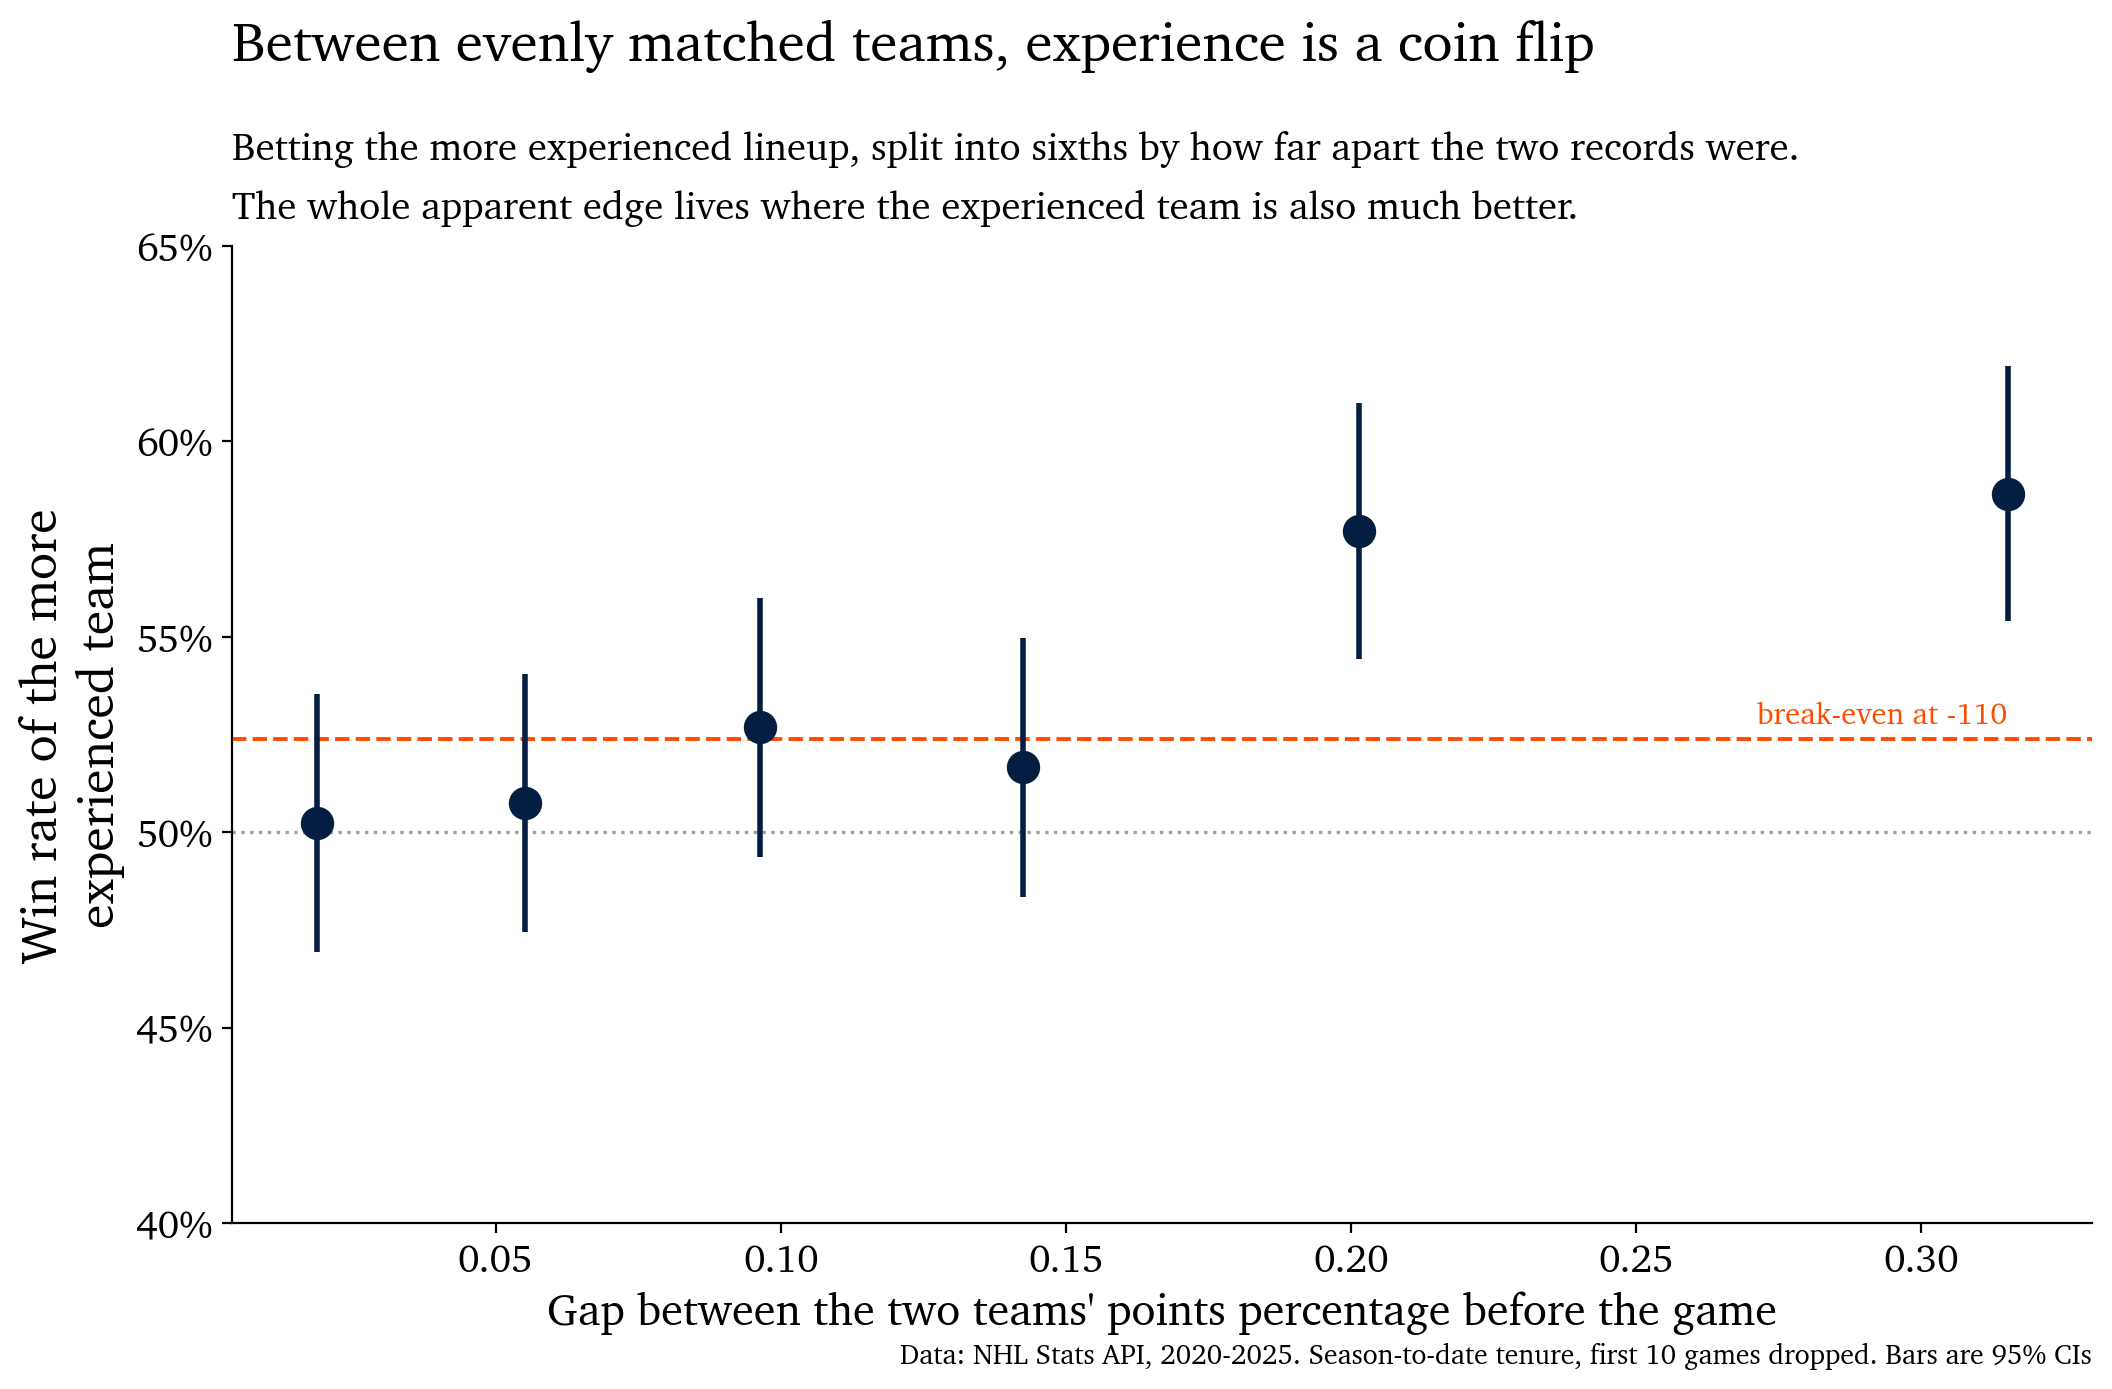


logit(home win) ~ tenure gap:               gap +0.1295 (z=6.91)
logit(home win) ~ tenure gap + record gap:  gap +0.0511 (z=2.58, p=0.010), record gap +2.418 (z=13.6)
share of the tenure coefficient that survives the record control: 39%


In [33]:
BG = pd.read_csv(REPO / "data" / "career-tenure" / "betting" / "bet_games.csv")
print(f"{len(BG):,} graded games, {BG.season.min()//10000}-{BG.season.max()//10000 + 1}, "
      f"first 10 games of each team-season dropped")
rows = []
for th in [0, .5, 1, 1.5, 2, 2.5, 3]:
    s_ = BG[BG.abs_gap >= th]
    k, n = int(s_.won.sum()), len(s_)
    rows.append({"tenure gap at least": th, "bets": n, "win rate": k / n,
                 "p vs 52.38% (break-even at -110)": stats.binomtest(k, n, 0.5238, alternative="greater").pvalue})
table(pd.DataFrame(rows), {"tenure gap at least": "{:.1f}", "bets": "{:,}", "win rate": "{:.2%}",
                           "p vs 52.38% (break-even at -110)": "{:.3f}"}, index=False)
better = np.where(BG.h_ppct > BG.a_ppct, BG.home_win, 1 - BG.home_win)[BG.h_ppct != BG.a_ppct]
print(f"back the better record instead: {better.mean():.2%} (n={len(better):,})")
print(f"tenure pick agrees with the better record {BG.agrees.mean():.1%} of the time")
print(f"  when they agree:    {BG[BG.agrees].won.mean():.2%} (n={BG.agrees.sum():,})")
print(f"  when they disagree: {BG[~BG.agrees].won.mean():.2%} (n={(~BG.agrees).sum():,})")

BG["rgb"] = pd.qcut(BG.rg.abs(), 6)
eb = BG.groupby("rgb", observed=True).agg(x=("rg", lambda s: s.abs().mean()), p=("won", "mean"), n=("won", "size"))
eb["se"] = np.sqrt(eb.p * (1 - eb.p) / eb.n)
fig, ax = plt.subplots(figsize=(12, 7))
ax.axhline(0.5, color=GRAY, ls=":", lw=1.2)
ax.axhline(0.5238, color=ORANGE, ls="--", lw=1.4)
ax.text(eb.x.max(), 0.5238 + .004, "break-even at -110", color=ORANGE, fontsize=11, ha="right")
ax.errorbar(eb.x, eb.p, yerr=1.96 * eb.se, fmt="o", ms=11, lw=0, elinewidth=2, color=BLUE_DARK)
ax.set_ylim(0.40, 0.65)
ax.yaxis.set_major_formatter(FuncFormatter(pct))
ax.set_xlabel("Gap between the two teams' points percentage before the game", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Win rate of the more\nexperienced team", fontsize=FS_AXIS_LABEL)
finish(fig, ax, "Between evenly matched teams, experience is a coin flip",
       "Betting the more experienced lineup, split into sixths by how far apart the two records were. The whole apparent edge lives where the experienced team is also much better.",
       f"Data: NHL Stats API, {BG.season.min()//10000}-{BG.season.max()//10000 + 1}. Season-to-date tenure, first 10 games dropped. Bars are 95% CIs")

hw = sm.Logit(BG.home_win, sm.add_constant(BG[["gap"]])).fit(disp=0)
hr = sm.Logit(BG.home_win, sm.add_constant(BG[["gap", "rec_gap"]])).fit(disp=0)
print(f"\nlogit(home win) ~ tenure gap:               gap {hw.params.gap:+.4f} (z={hw.tvalues.gap:.2f})")
print(f"logit(home win) ~ tenure gap + record gap:  gap {hr.params.gap:+.4f} (z={hr.tvalues.gap:.2f}, "
      f"p={hr.pvalues.gap:.3f}), record gap {hr.params.rec_gap:+.3f} (z={hr.tvalues.rec_gap:.1f})")
print(f"share of the tenure coefficient that survives the record control: {hr.params.gap/hw.params.gap:.0%}")

# The playoffs and the Stanley Cup

I identify the Cup winner as the team with the most playoff wins in a season and the runner-up as the team with the second most, which lines up with the known winners. Four early seasons (1917, 1922, 1927 and 1936) have a tie at the top, so there's no clean runner-up, and those drop out of the head-to-head comparison. That leaves 101 finals. Everything is measured against the league average that season, since league size and the spread of experience changed enormously over the century.

In [34]:
PL = playoffs.copy()
tr_p = team_rosters.assign(yr=team_rosters.season // 10000)
tr_p["exp"] = tr_p.yr - tr_p.groupby("playerId").yr.transform("min")
tr_p = tr_p[tr_p.gp > 0]
tm_p = (tr_p.assign(w=tr_p.exp * tr_p.gp).groupby(["season", "teamId"]).agg(w=("w", "sum"), gp=("gp", "sum")))
tm_p["exp"] = tm_p.w / tm_p.gp
D = ts_.merge(tm_p.reset_index()[["season", "teamId", "exp"]], on=["season", "teamId"]).query("gp >= 20").copy()
PL["rk"] = PL.groupby("yr").w.rank(ascending=False, method="min")
ties = PL[PL.rk == 1].groupby("yr").size()
_w = PL[PL.rk == 1].drop_duplicates("yr")[["yr", "teamId"]].assign(result="Won the Cup")
_l = PL[PL.rk == 2].drop_duplicates("yr")[["yr", "teamId"]].assign(result="Lost the final")
D = D.merge(PL[["yr", "teamId"]].assign(playoff=1), on=["yr", "teamId"], how="left")
D["playoff"] = D.playoff.fillna(0).astype(int)
D = D.merge(pd.concat([_w, _l]), on=["yr", "teamId"], how="left")
D["result"] = D.result.where(D.result.notna(), pd.Series(
    np.where(D.playoff == 1, "Made playoffs", "Missed playoffs"), index=D.index))
for c in ["exp", "point_pct"]:
    D[c + "_d"] = D[c] - D.groupby("season")[c].transform("mean")
D = D[D.yr <= 2024]
ORDER = ["Won the Cup", "Lost the final", "Made playoffs", "Missed playoffs"]
RCOL = {"Won the Cup": ORANGE, "Lost the final": BLUE_PALE, "Made playoffs": GRAY, "Missed playoffs": "#C3C9D2"}
print(f"{len(D):,} team-seasons, {D.yr.min()}-{D.yr.max()}")
print(f"seasons where two teams tie for most playoff wins (winner taken as listed): "
      f"{', '.join(str(y) for y in ties[ties > 1].index)}")
print(f"seasons with no runner-up identified: {sorted(set(_w.yr) - set(_l.yr))}")

1,723 team-seasons, 1917-2024
seasons where two teams tie for most playoff wins (winner taken as listed): 1917, 1922, 1927, 1936
seasons with no runner-up identified: [1917, 1922, 1927, 1936]


## Every Stanley Cup final

The figure from the post. Each dot is one final; dots above the dashed line are finals won by the more experienced team.

The more experienced team won 58 of the 101 finals. The 95% interval on that runs from 47% to 67%, and the average difference between the winner and loser is 0.08 seasons of experience. For the more experienced side to clear even a one-sided significance test, it would need to have won 60. In other words, I can't tell it apart from a coin flip.

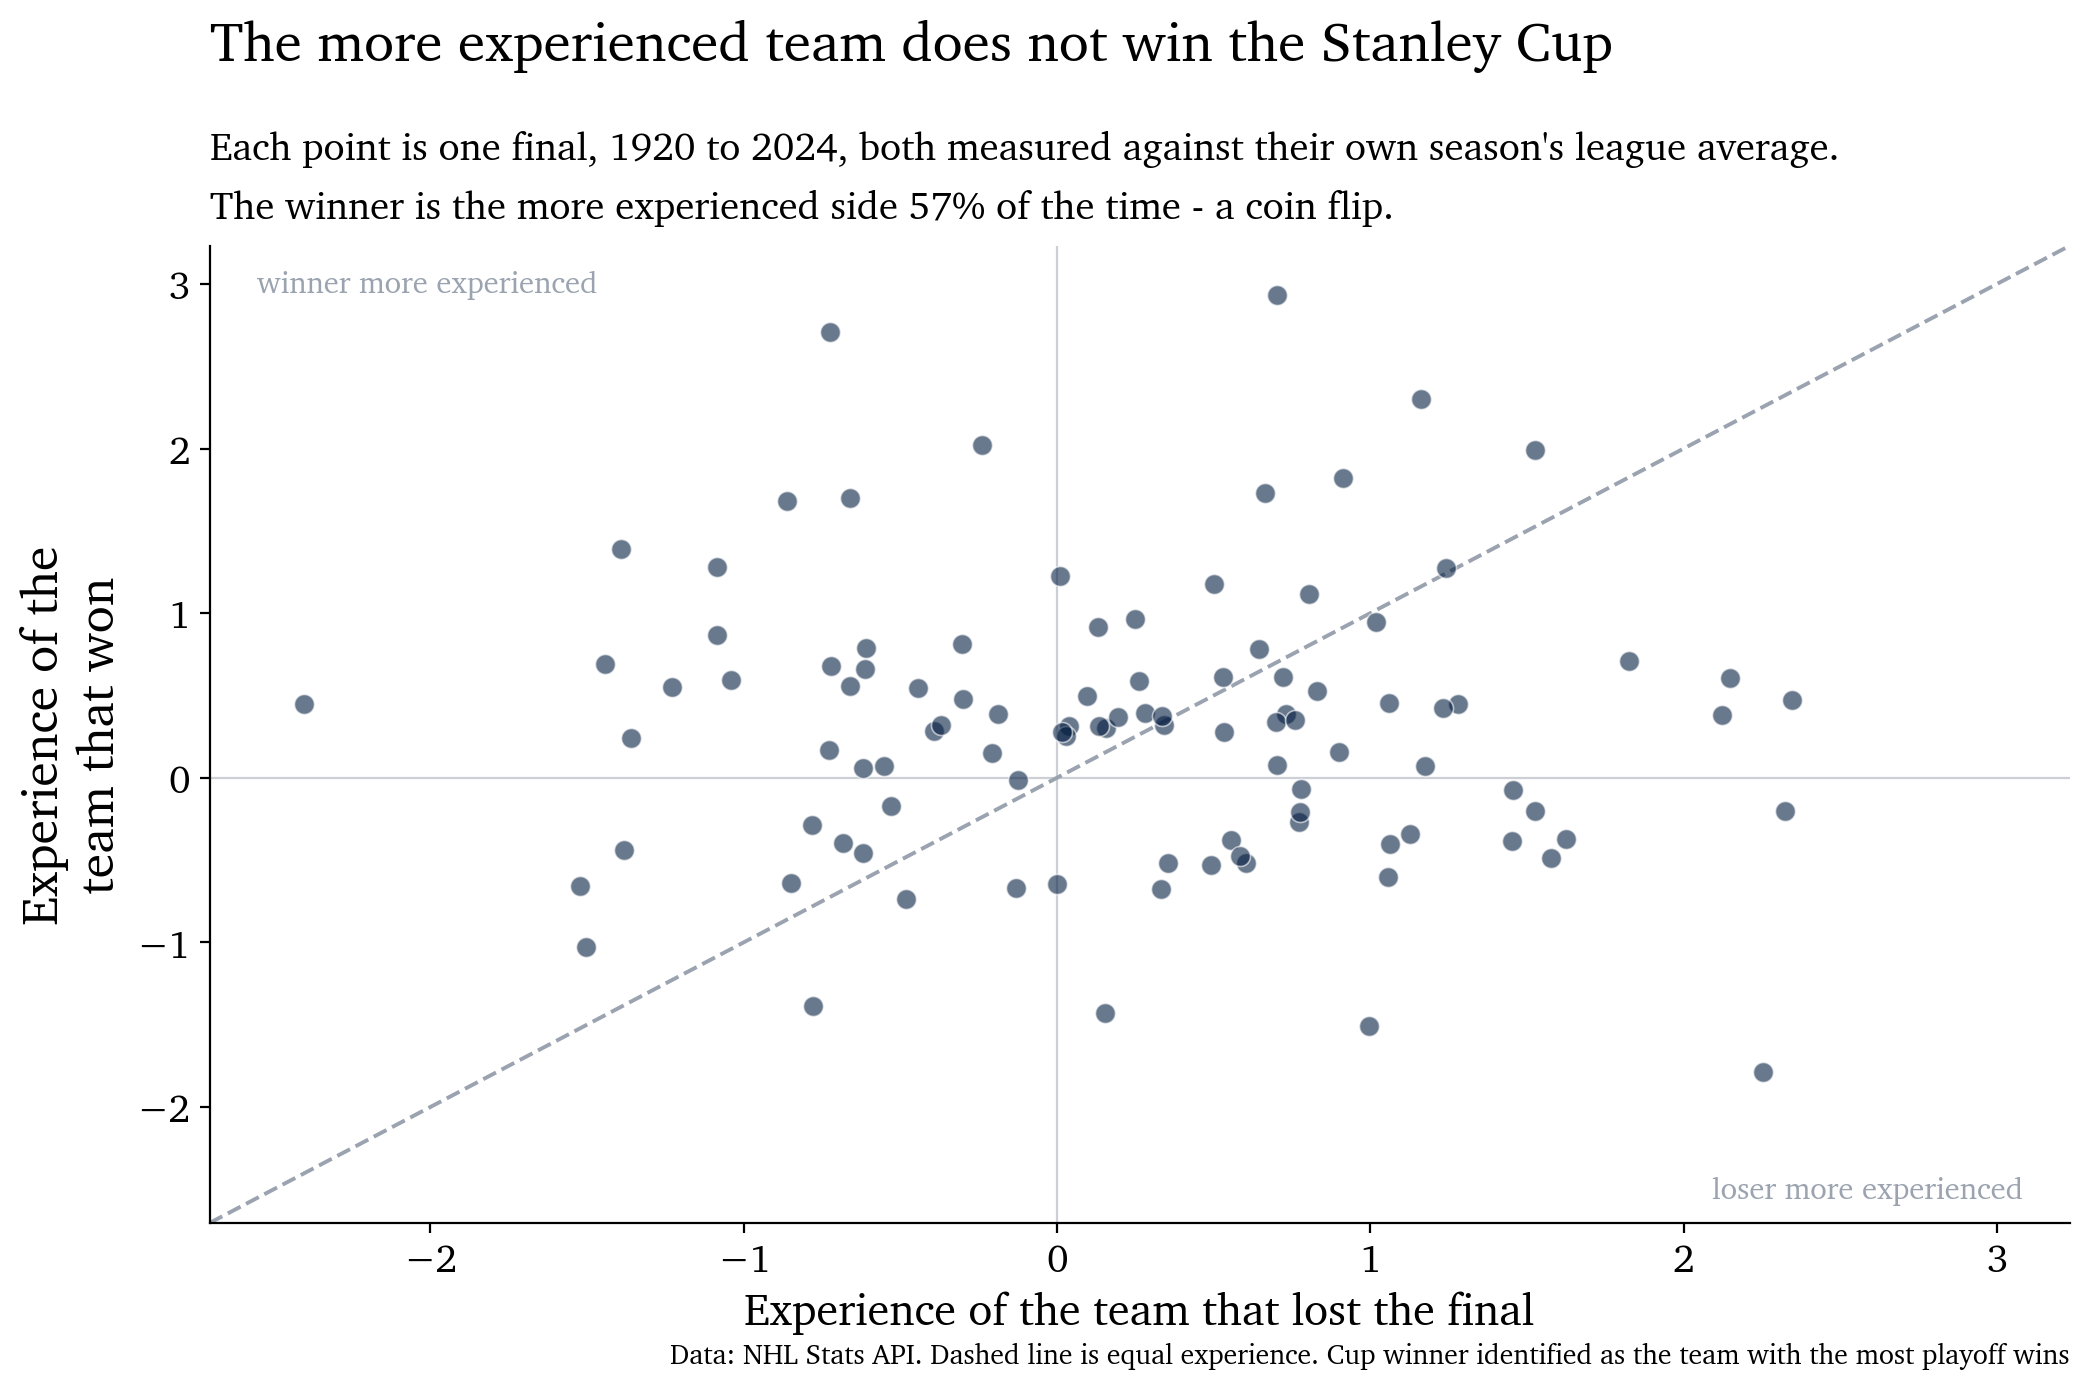

finals: 101   winner more experienced in 58 of 101  (57.4%, 95% CI 47.2%-67.2%, two-sided binomial p = 0.163)
mean experience vs league: winner +0.31, loser +0.23; paired t = +0.60, p = 0.547
with 101 finals, the winner would need to be the more experienced side in 60 (59%) to clear one-sided p < .05


In [35]:
fin = (D[D.result == "Won the Cup"].set_index("yr").exp_d.rename("win").to_frame()
       .join(D[D.result == "Lost the final"].set_index("yr").exp_d.rename("lose"), how="inner"))
lim = (min(fin.min()) - 0.3, max(fin.max()) + 0.3)
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(lim, lim, color=GRAY, ls="--", lw=1.4, zorder=1)
ax.axhline(0, color=GRAY, lw=.8, alpha=.5, zorder=1)
ax.axvline(0, color=GRAY, lw=.8, alpha=.5, zorder=1)
ax.scatter(fin.lose, fin.win, s=52, color=BLUE_DARK, alpha=.6, edgecolors="white", lw=.6, zorder=3)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Experience of the team that lost the final", fontsize=FS_XAXIS_LABEL)
ax.set_ylabel("Experience of the\nteam that won", fontsize=FS_AXIS_LABEL)
ax.text(lim[0] + .15, lim[1] - .15, "winner more experienced", fontsize=11, color=GRAY, style="italic", va="top")
ax.text(lim[1] - .15, lim[0] + .15, "loser more experienced", fontsize=11, color=GRAY, style="italic", ha="right")
share = (fin.win > fin.lose).mean()
finish(fig, ax, "The more experienced team does not win the Stanley Cup",
       f"Each point is one final, {int(fin.index.min())} to {int(fin.index.max())}, both measured against their own season's league average. The winner is the more experienced side {share*100:.0f}% of the time - a coin flip.",
       "Data: NHL Stats API. Dashed line is equal experience. Cup winner identified as the team with the most playoff wins")

k, n = int((fin.win > fin.lose).sum()), int((fin.win != fin.lose).sum())
bt = stats.binomtest(k, n, 0.5)
lo_, hi_ = bt.proportion_ci()
pt = stats.ttest_rel(fin.win, fin.lose)
print(f"finals: {len(fin)}   winner more experienced in {k} of {n}  ({k/n:.1%}, 95% CI {lo_:.1%}-{hi_:.1%}, "
      f"two-sided binomial p = {bt.pvalue:.3f})")
print(f"mean experience vs league: winner {fin.win.mean():+.2f}, loser {fin.lose.mean():+.2f}; "
      f"paired t = {pt.statistic:+.2f}, p = {pt.pvalue:.3f}")
pw = stats.binomtest(k, n, 0.5)
need = next(m for m in range(n // 2, n) if stats.binomtest(m, n, .5, alternative="greater").pvalue < .05)
print(f"with {n} finals, the winner would need to be the more experienced side in {need} ({need/n:.0%}) "
      f"to clear one-sided p < .05")

## Where experience does matter: the playoff line

From the post: every team-season, grouped by how it ended, measured against the league average that season. The break is at the playoff line. Teams that missed were 0.30 seasons less experienced than the league; every group that made it is above average. Among the teams that made it, the intervals all overlap.

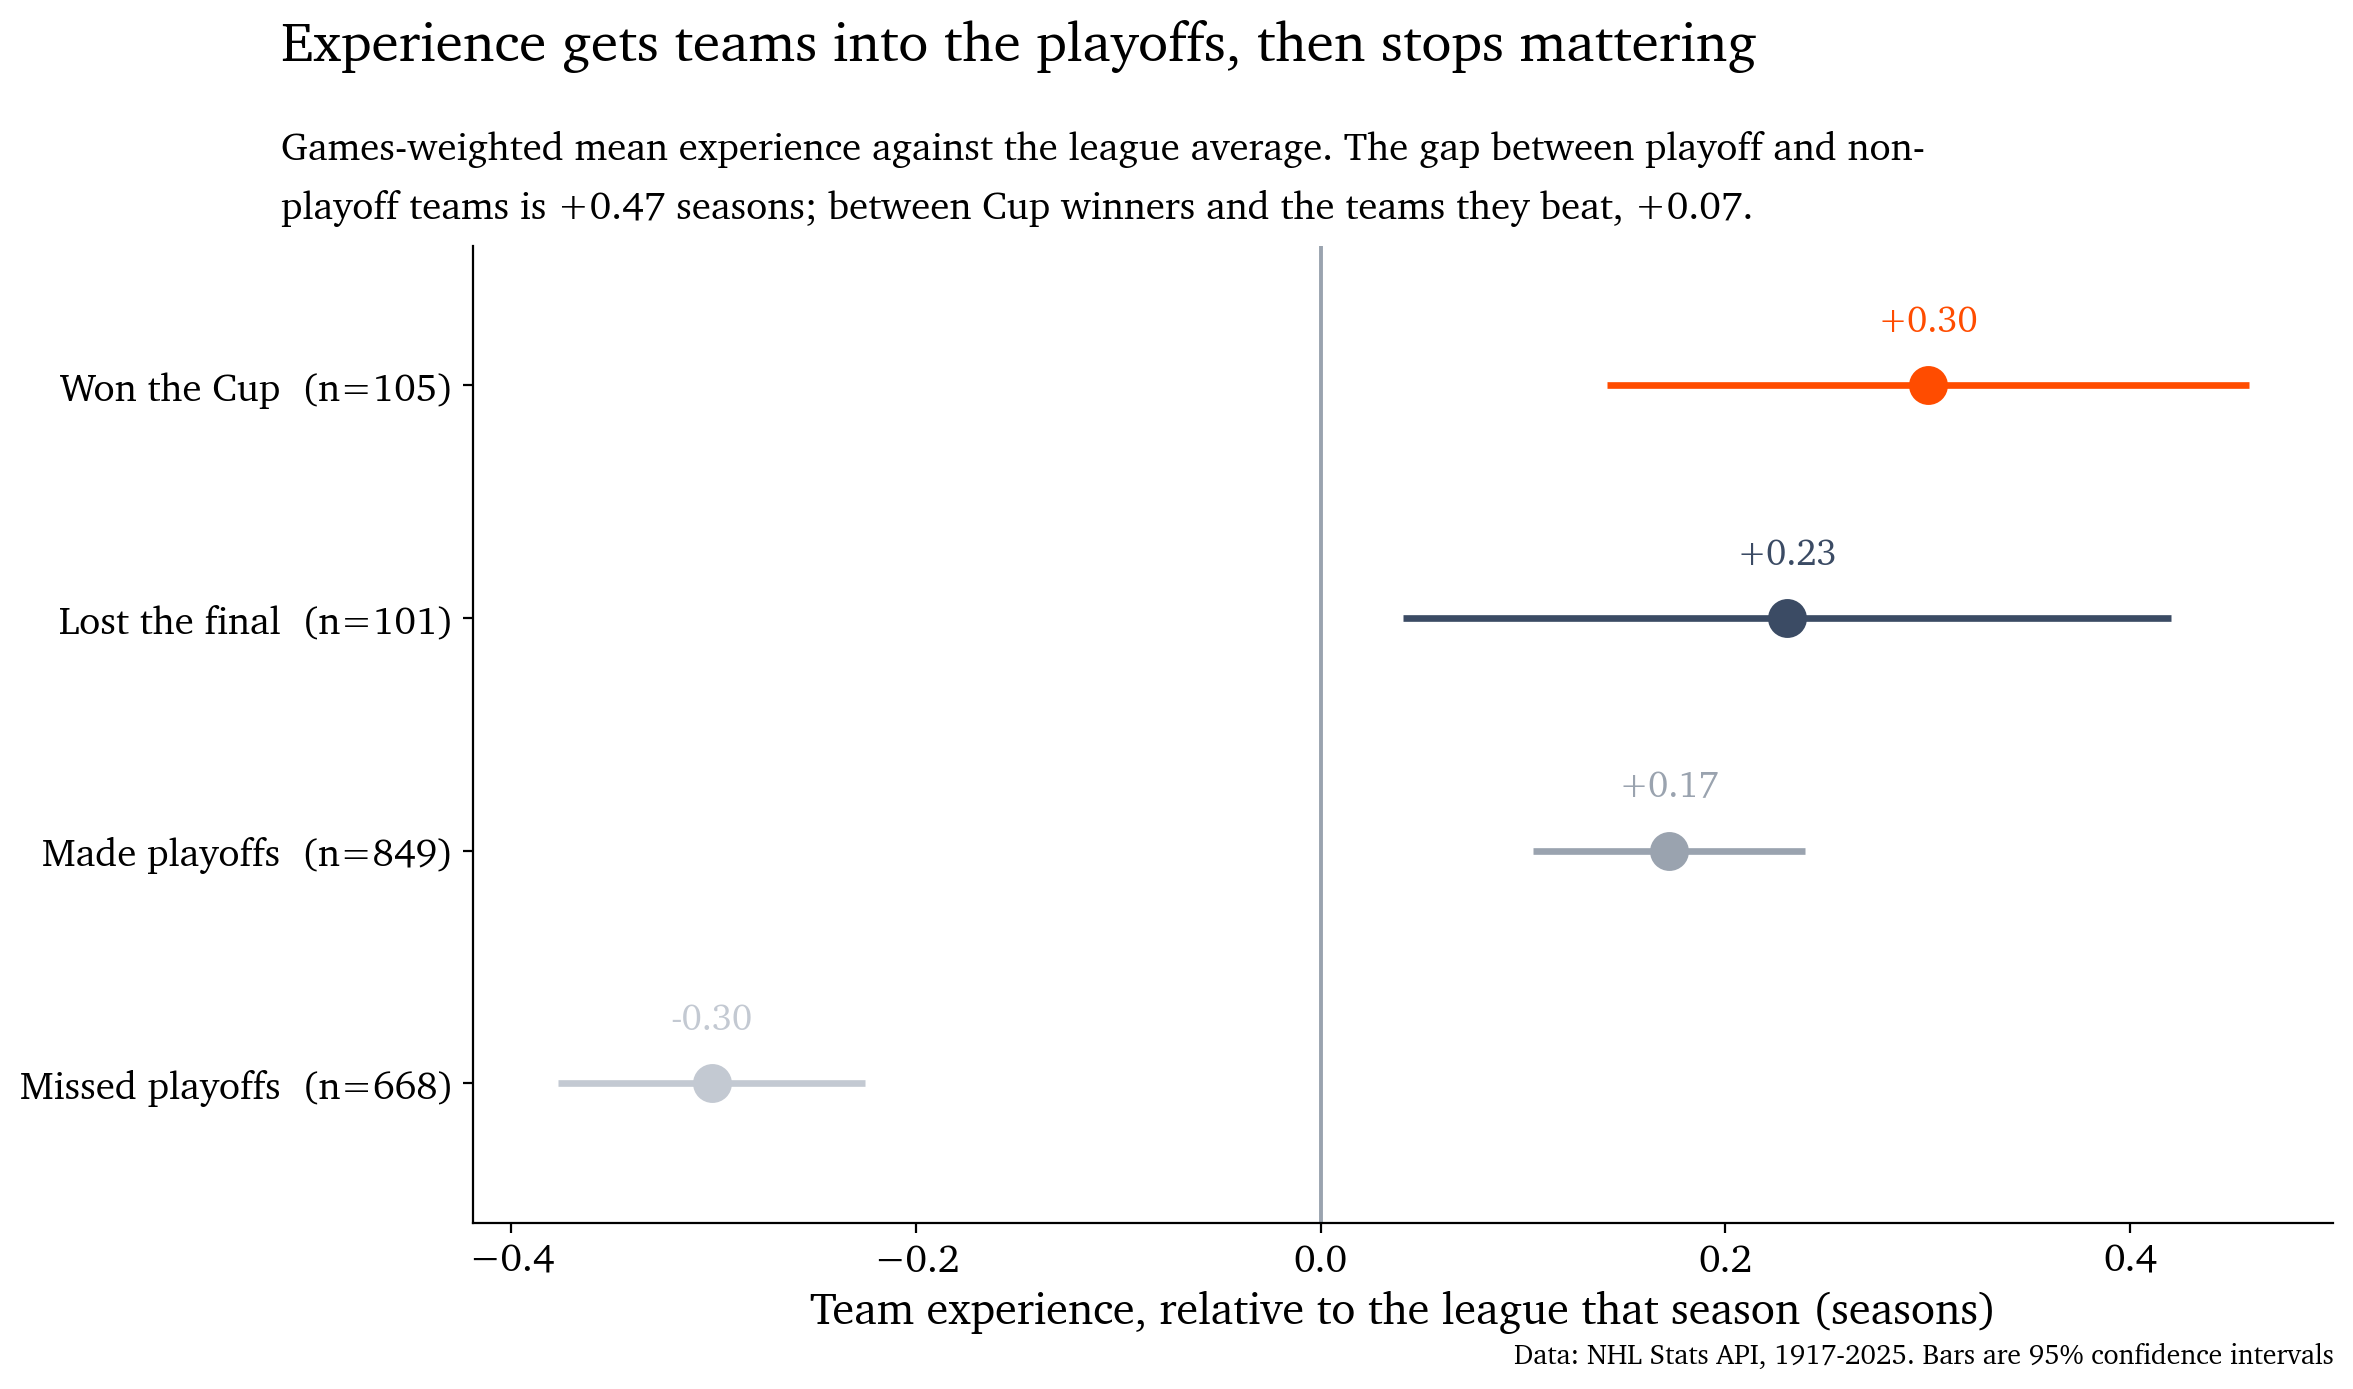

,vs league (seasons),SE,team-seasons,95% CI low,95% CI high
result,,,,,
Won the Cup,+0.30,0.081,105,+0.14,+0.46
Lost the final,+0.23,0.097,101,+0.04,+0.42
Made playoffs,+0.17,0.034,849,+0.10,+0.24
Missed playoffs,-0.30,0.039,668,-0.38,-0.22


all playoff teams vs non-playoff teams: +0.49 seasons, Welch t = 10.0, p = 9.1e-23


In [36]:
st = D.groupby("result").exp_d.agg(["mean", "sem", "size"]).reindex(ORDER)
fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(ORDER))[::-1]
ax.axvline(0, color=GRAY, lw=1.4, zorder=1)
for yi, r in zip(y, ORDER):
    m_, se = st.loc[r, "mean"], st.loc[r, "sem"]
    ax.errorbar(m_, yi, xerr=1.96 * se, fmt="o", ms=13, lw=0, elinewidth=2.4, color=RCOL[r], zorder=3)
    ax.text(m_, yi + 0.20, f"{m_:+.2f}", ha="center", va="bottom", fontsize=13, color=RCOL[r])
ax.set_yticks(y)
ax.set_yticklabels([f"{r}  (n={int(st.loc[r, 'size']):,})" for r in ORDER])
ax.set_ylim(-0.6, len(ORDER) - 0.4)
ax.set_xlabel("Team experience, relative to the league that season (seasons)", fontsize=FS_XAXIS_LABEL)
finish(fig, ax, "Experience gets teams into the playoffs, then stops mattering",
       f"Games-weighted mean experience against the league average. The gap between playoff and non-playoff teams is {st.loc['Made playoffs','mean']-st.loc['Missed playoffs','mean']:+.2f} seasons; between Cup winners and the teams they beat, {st.loc['Won the Cup','mean']-st.loc['Lost the final','mean']:+.2f}.",
       "Data: NHL Stats API, 1917-2025. Bars are 95% confidence intervals", title_x=0.045)
st_t = st.assign(lo=st["mean"] - 1.96 * st["sem"], hi=st["mean"] + 1.96 * st["sem"])
table(st_t.rename(columns={"mean": "vs league (seasons)", "sem": "SE", "size": "team-seasons",
                           "lo": "95% CI low", "hi": "95% CI high"}),
      {"vs league (seasons)": "{:+.2f}", "SE": "{:.3f}", "team-seasons": "{:,}", "95% CI low": "{:+.2f}",
       "95% CI high": "{:+.2f}"})
pl = D[D.result != "Missed playoffs"].exp_d
mi = D[D.result == "Missed playoffs"].exp_d
tt = stats.ttest_ind(pl, mi, equal_var=False)
print(f"all playoff teams vs non-playoff teams: {pl.mean() - mi.mean():+.2f} seasons, Welch t = {tt.statistic:.1f}, "
      f"p = {tt.pvalue:.1e}")

## Since 1991, in raw seasons

Raw experience only makes sense within one era: there's one champion per season no matter how big the league is, so pooling the six-team league with the thirty-two-team league would be comparing different things. Since 1991, playoff teams averaged about half a season more experience than teams that missed, and champions about 0.8 more. But champions and the teams they beat in the final differ by less than a tenth of a season.

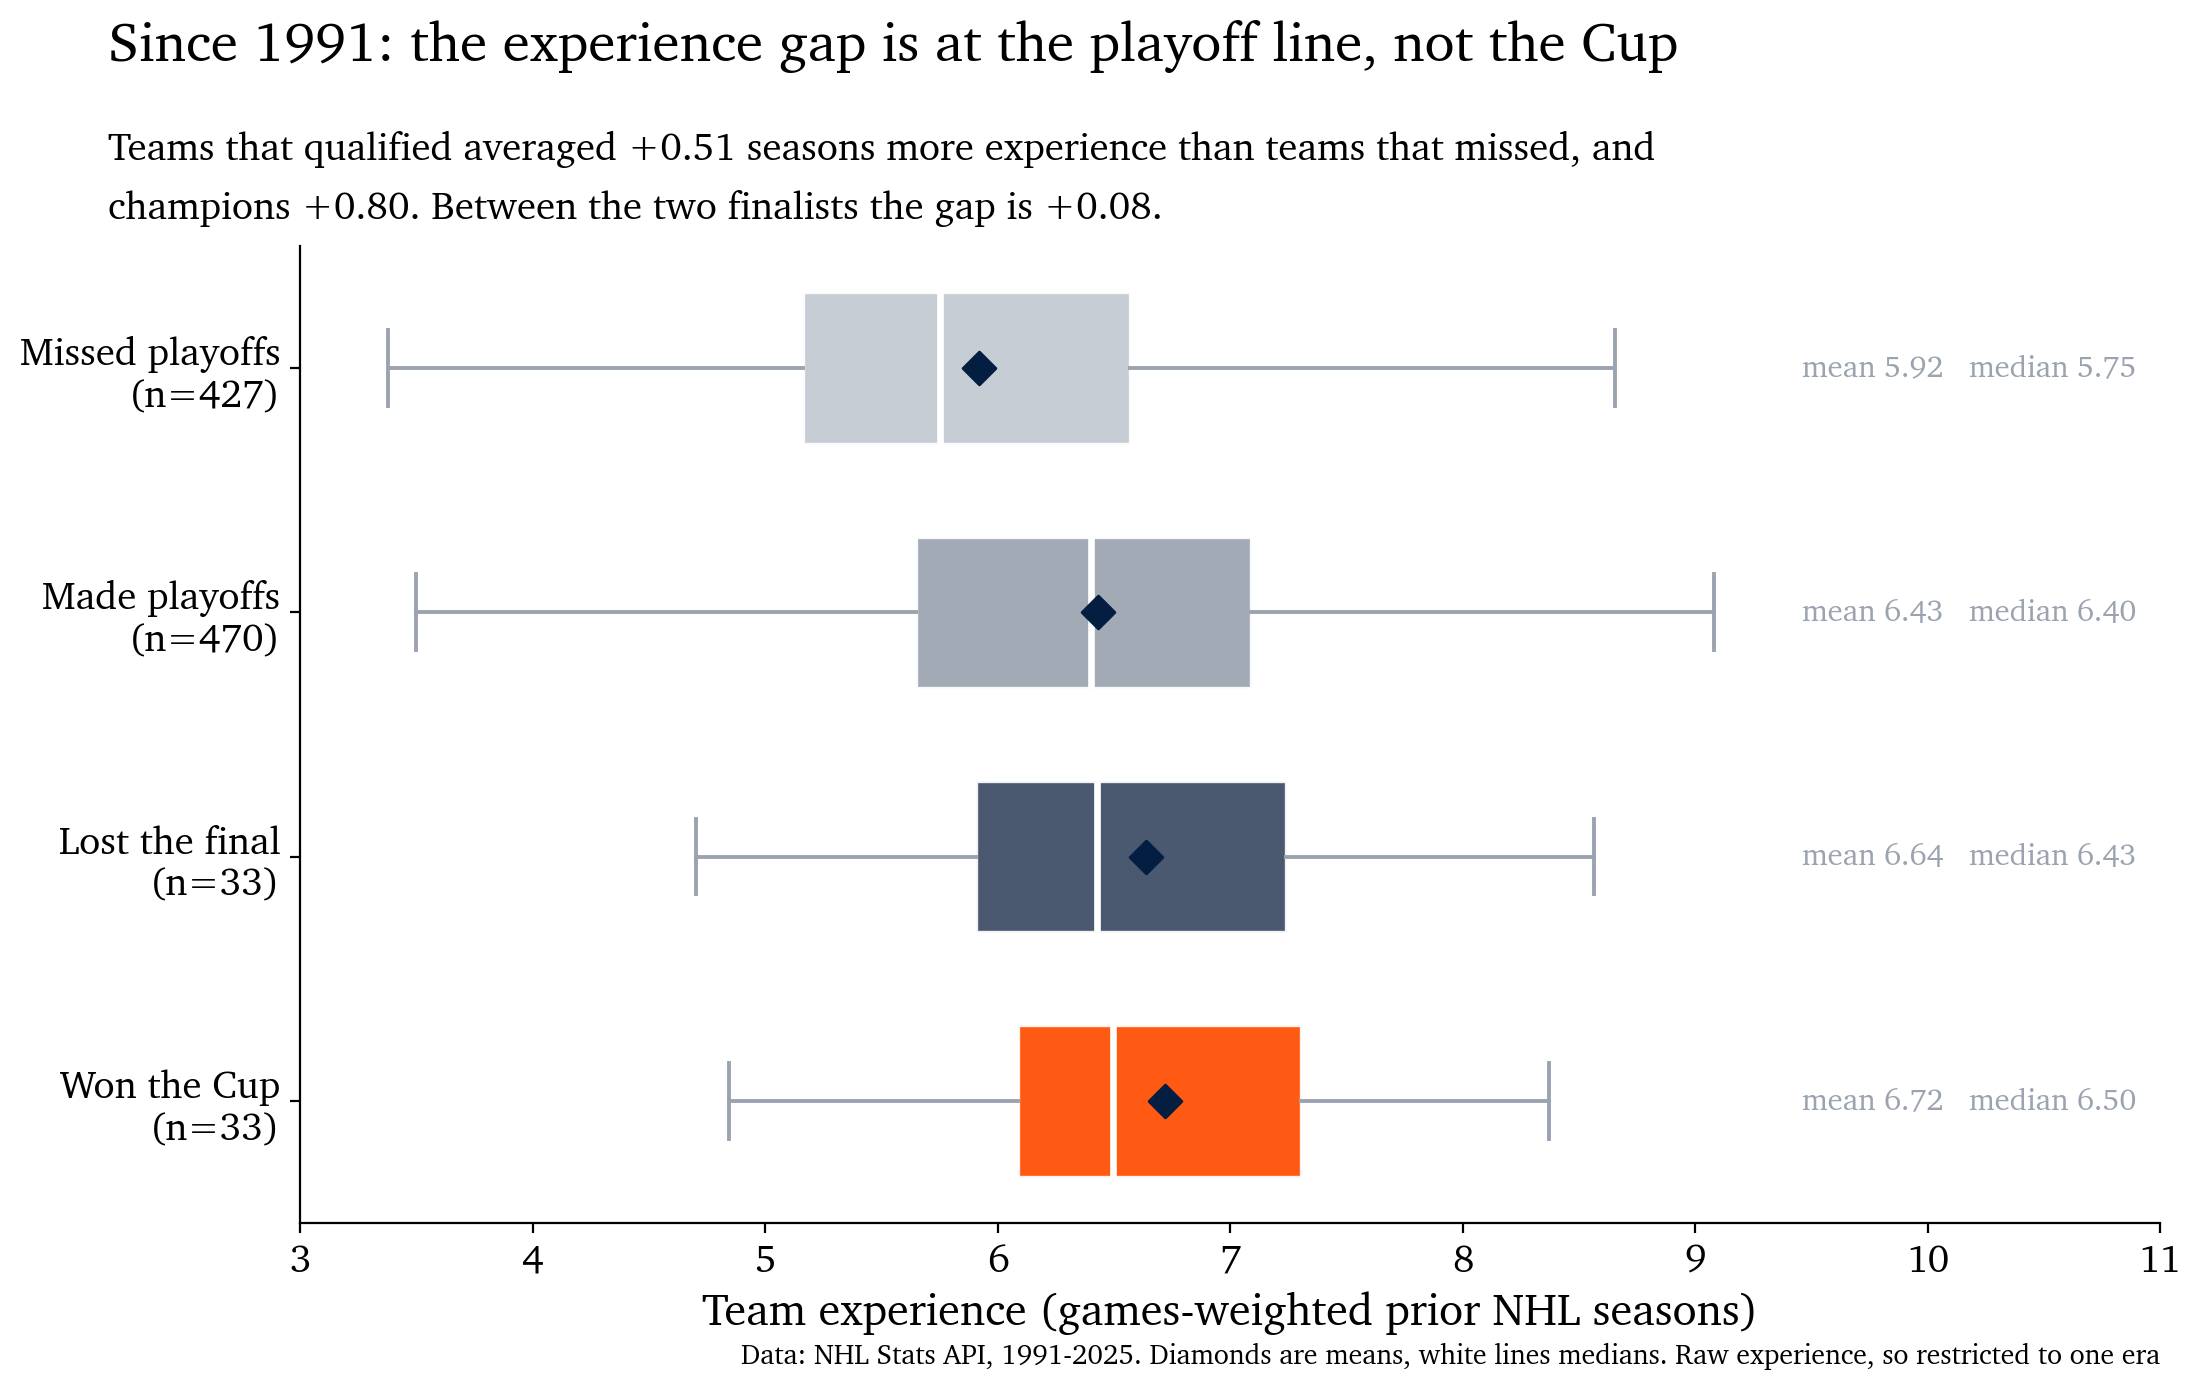

       Won the Cup: n=  33  mean 6.72  median 6.50
    Lost the final: n=  33  mean 6.64  median 6.43
     Made playoffs: n= 470  mean 6.43  median 6.40
   Missed playoffs: n= 427  mean 5.92  median 5.75
  made - missed +0.51   champions - missed +0.80   winner - loser +0.08


In [37]:
M = D[D.yr >= 1991]
fig, ax = plt.subplots(figsize=(12, 7))
bp = ax.boxplot([M.loc[M.result == r, "exp"].values for r in ORDER], vert=False, widths=.62,
                patch_artist=True, showfliers=False, medianprops=dict(color="white", lw=2.4),
                whiskerprops=dict(color=GRAY, lw=1.4), capprops=dict(color=GRAY, lw=1.4))
for patch, r in zip(bp["boxes"], ORDER):
    patch.set(facecolor=RCOL[r], alpha=.92, edgecolor="white", lw=1.2)
for i, r in enumerate(ORDER, start=1):
    v = M.loc[M.result == r, "exp"]
    ax.scatter(v.mean(), i, marker="D", s=70, color=BLUE_DARK, zorder=5)
    ax.text(10.9, i, f"mean {v.mean():.2f}   median {v.median():.2f}", va="center", ha="right",
            fontsize=11, color=GRAY)
ax.set_yticks(range(1, len(ORDER) + 1))
ax.set_yticklabels([f"{r}\n(n={int((M.result == r).sum()):,})" for r in ORDER])
ax.set_xlabel("Team experience (games-weighted prior NHL seasons)", fontsize=FS_XAXIS_LABEL)
ax.set_xlim(3, 11)
g_pl = M[M.result == "Made playoffs"].exp.mean() - M[M.result == "Missed playoffs"].exp.mean()
g_cup = M[M.result == "Won the Cup"].exp.mean() - M[M.result == "Lost the final"].exp.mean()
g_ch = M[M.result == "Won the Cup"].exp.mean() - M[M.result == "Missed playoffs"].exp.mean()
finish(fig, ax, "Since 1991: the experience gap is at the playoff line, not the Cup",
       f"Teams that qualified averaged {g_pl:+.2f} seasons more experience than teams that missed, and champions {g_ch:+.2f}. Between the two finalists the gap is {g_cup:+.2f}.",
       "Data: NHL Stats API, 1991-2025. Diamonds are means, white lines medians. Raw experience, so restricted to one era",
       title_x=0.045)
for r in ORDER:
    v = M.loc[M.result == r, "exp"]
    print(f"  {r:>16}: n={len(v):>4}  mean {v.mean():.2f}  median {v.median():.2f}")
print(f"  made - missed {g_pl:+.2f}   champions - missed {g_ch:+.2f}   winner - loser {g_cup:+.2f}")

## A couple more checks

**Is experience getting teams into the playoffs, or is the regular-season record?** On its own, experience strongly predicts making the playoffs. Add the team's points percentage to the model and experience predicts nothing at all. That's the same between-team story from earlier: experienced teams earn more points, and points are what get you in.

**Has the final changed over time?** The more experienced team won 57% of finals before expansion, 62% from 1967 to 1990, and 55% since 1991. None of those differ from a coin flip, and there's no sign it's trending anywhere.

In [38]:
rows = []
m1 = sm.Logit(D.playoff, sm.add_constant(D[["exp_d"]])).fit(disp=0)
m2 = sm.Logit(D.playoff, sm.add_constant(D[["exp_d", "point_pct_d"]])).fit(disp=0)
rows.append({"model": "made playoffs ~ experience", "experience coef": m1.params.exp_d, "z": m1.tvalues.exp_d,
             "p-value": m1.pvalues.exp_d})
rows.append({"model": "made playoffs ~ experience + points %", "experience coef": m2.params.exp_d,
             "z": m2.tvalues.exp_d, "p-value": m2.pvalues.exp_d})
table(pd.DataFrame(rows), {"experience coef": "{:+.3f}", "z": "{:+.1f}", "p-value": "{:.3f}"}, index=False,
      caption="Logit, all team-seasons; experience and points % measured against the league that season")

rows = []
for lbl, f_ in [("1918-1966", fin.loc[:1966]), ("1967-1990", fin.loc[1967:1990]), ("1991-2024", fin.loc[1991:]),
                ("all finals", fin)]:
    kk, nn = int((f_.win > f_.lose).sum()), int((f_.win != f_.lose).sum())
    rows.append({"era": lbl, "finals": nn, "more experienced side won": kk / nn,
                 "mean gap (winner - loser)": (f_.win - f_.lose).mean(),
                 "binomial p": stats.binomtest(kk, nn, .5).pvalue})
table(pd.DataFrame(rows), {"finals": "{:,}", "more experienced side won": "{:.0%}",
                           "mean gap (winner - loser)": "{:+.2f}", "binomial p": "{:.3f}"}, index=False)

model,experience coef,z,p-value
made playoffs ~ experience,+0.511,+9.5,0.000
made playoffs ~ experience + points %,+0.018,+0.2,0.827


era,finals,more experienced side won,mean gap (winner - loser),binomial p
1918-1966,44,57%,+0.06,0.451
1967-1990,24,62%,+0.11,0.307
1991-2024,33,55%,+0.08,0.728
all finals,101,57%,+0.08,0.163


# Summary of key findings

### 1. The league really is more veteran than ever
- 31% of players are in their 10th season or later, the highest of 108 seasons
- Rookies are 12% of the league, down from about 23% in the 1940s and 50s
- The record holds on most definitions of "veteran"; on the strictest ones, only the last Original Six seasons come close

### 2. Careers aren't getting longer
- The median career by debut decade has bounced between 5 and 8 seasons since 1950 with no trend
- The 1960s produced the longest careers and the 1970s the shortest. It's an expansion cycle, not a direction
- Rookies aren't arriving younger either: debut age has sat around 22 for seventy years

### 3. The veterans come from two places
- Intake: the league doubled since the 1970s while debuts grew by a third, so a smaller share of each season is new
- Retention: established players (4th season and up) are less likely to leave than they were 15-20 years ago, while rookie washout hasn't changed
- Frozen careers plus the real intake get you to about 25% veterans; the last six points or so come from players staying

### 4. Experience marks a good roster, not a good night
- Between teams: about 3 points of win probability, and 3 points of points percentage, per season of experience
- Within a team: zero, with a tight interval
- Rookie-heavy rosters lose, veteran-heavy ones win, and the rookie penalty is the bigger of the two
- The relationship is a modern one; in the 1930s it ran the other way

### 5. Experience gets you into the playoffs, then stops mattering
- Playoff teams are about half a season more experienced than non-playoff teams
- Between the two teams in the final, it's a coin flip (58 of 101)

### 6. Not much evidence for
- Careers lengthening over the century
- Rookies arriving younger
- A lineup's experience changing the outcome of a given game
- The more experienced team winning the Cup
- A betting edge

### Caveats
- Nothing here is causal. Good players last, so experience and quality travel together
- "Experience" is years since a first NHL game. It isn't leadership or playoff experience or anything else a coach might mean by it
- Careers starting after about 2010 aren't finished, which is why the retention story leans on exit rates rather than completed careers
- Game-level data covers 2010-11 to 2024-25; everything season-level runs from 1917-18

# Reproducing this

From `scripts/career-player-tenure/`, in order:

1. `1. Get_all_data.py` pulls player seasons, team rosters (team by team, so traded players get split properly), standings, and playoff records, and writes them to S3.
2. `2. Wrangle_data.py` builds the career, cohort, team-season and team-game tables.
3. `3. Figs_for_deepdive.py` writes the figures for the post.
4. This notebook: `quarto render career_tenure.ipynb --to html`, then move the HTML into `static/rendered/`.

Package versions for the run that produced this page:

In [39]:
import matplotlib, scipy, statsmodels
print(f"python      {sys.version.split()[0]}")
for mod_ in (pd, np, matplotlib, sns, statsmodels, scipy):
    print(f"{mod_.__name__:<12}{mod_.__version__}")
print(f"run on      {pd.Timestamp.now():%Y-%m-%d %H:%M}")

python      3.13.5
pandas      2.2.3
numpy       2.1.3
matplotlib  3.10.0
seaborn     0.13.2
statsmodels 0.14.4
scipy       1.15.3
run on      2026-09-24 15:17


---

*Part II will get into stars versus the rank-and-file: who lasts longer, and how differently the great players age.*